In [4]:
# ── suppress noisy Lasso convergence warnings (does NOT touch src/) ─────────
import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings('ignore', category=ConvergenceWarning)

In [5]:
# ═══════════════════════════════════════════════════════════════════════════
# NOTEBOOK 14 · PHASE 3 — Transfer of the TabPFN pipeline to anthropogenic
# pollutants, and comparison of their signal types.
#
# Targets / difficulty gradient:
#   Caffeine    — easy, data-rich        (quant ~91%)  : strong, transferable
#   Metoprolol  — sparse, site-dependent (quant ~27%)  : point-source signal
#   Atrazine    — very sparse, hard      (quant ~4%)   : weak but significant
#
# Pipeline (src/) is reused untouched. Notebooks 05/06/10/13 are not modified.
# ═══════════════════════════════════════════════════════════════════════════

# ── CELL 0: setup — constants + locked-pipeline imports ─────────────────────
import sys, time
from pathlib import Path
import numpy as np
import pandas as pd

ROOT = Path('..').resolve()
sys.path.insert(0, str(ROOT))

PROCESSED_DIR = ROOT / 'data' / 'processed'
RAW_DIR       = ROOT / 'data'
RESULTS       = ROOT / 'results'

RANDOM_SEED = 42
MODEL_PATH  = 'auto'          # TabPFN v3 default (pkg 8.0.6) — matches locked runs
DEVICE      = 'cuda'

INPUTS_ORDER = ['16S', '18S', '16S+18S']
STRATEGIES   = ['random_kfold', 'temporal_holdout',
                'temporal_blocked_kfold', 'leave_one_site_out']

# colorblind-safe palette (identical to Notebook 13)
CB_SAFE = ['#0173B2', '#DE8F05', '#029E73', '#CC78BC', '#CA9161', '#949494']

# ---- CV dispatch: identical to Notebooks 06/08/10 ----
from src.cv_strategies import (random_kfold, temporal_holdout,
                               temporal_blocked_kfold, leave_one_site_out)

def build_splits(strategy_name, meta_valid, random_seed=RANDOM_SEED):
    n = len(meta_valid)
    if strategy_name == 'random_kfold':
        return random_kfold(n_samples=n, n_folds=5, random_seed=random_seed)
    elif strategy_name == 'temporal_holdout':
        return temporal_holdout(meta_valid, test_fraction=0.2)
    elif strategy_name == 'temporal_blocked_kfold':
        return temporal_blocked_kfold(meta_valid, n_folds=5)
    elif strategy_name == 'leave_one_site_out':
        return leave_one_site_out(meta_valid)
    raise ValueError(f'unknown strategy: {strategy_name}')

print(f'seed={RANDOM_SEED}  model={MODEL_PATH}  device={DEVICE}')
print(f'strategies: {STRATEGIES}')

seed=42  model=auto  device=cuda
strategies: ['random_kfold', 'temporal_holdout', 'temporal_blocked_kfold', 'leave_one_site_out']


In [13]:
# ── CELL 1: data layer — HPLC targets, censoring, alignment, difficulty ─────
#   Verified: meta_clean INDEX is the s##[MT]#### sample id (100% match).
#   Censoring convention:
#     '<x' below LOD  -> measured, not detected      -> 0
#     '#x' below LOQ  -> detected, not quantified    -> 0  (counts as detected)
#     number          -> quantified                  -> value
#     empty           -> not measured                -> NaN

meta    = pd.read_csv(PROCESSED_DIR / 'meta_clean.csv',    index_col=0)
otu_16s = pd.read_csv(PROCESSED_DIR / 'otu_16s_clean.csv', index_col=0)
otu_18s = pd.read_csv(PROCESSED_DIR / 'otu_18s_clean.csv', index_col=0)

meta_ids = pd.Series(meta.index.astype(str).str.strip(), index=meta.index)
assert meta_ids.str.match(r's\d{2}[MT]\d+').all(), 'meta index not sample-id format'

hplc = pd.read_csv(RAW_DIR / 'hplc_submission.csv', index_col=0, dtype=str)
hplc.index = hplc.index.astype(str).str.strip()

def _classify(v):
    if pd.isna(v):        return np.nan
    v = str(v).strip()
    if v == '':           return np.nan
    if v.startswith('<'): return 0.0        # below LOD
    if v.startswith('#'): return 0.0        # below LOQ
    try:                  return float(v)
    except ValueError:    return np.nan

# ---- version-robust element-wise apply (pandas dropped applymap in 2.1) ----
_elementwise = hplc.map if hasattr(hplc, 'map') else hplc.applymap
value0 = _elementwise(_classify)       # censored -> 0, unmeasured -> NaN

# ---- the three difficulty-gradient targets ----
GRADIENT = ['Caffeine', 'Metoprolol', 'Atrazine']
aligned  = value0[GRADIENT].reindex(meta_ids.values)
aligned.index = meta.index
for c in GRADIENT:
    meta[c] = aligned[c].values

# ---- input tables (samples on rows, aligned to meta) ----
otu_combined = pd.concat([otu_16s, otu_18s], axis=1)
INPUTS = {'16S': otu_16s, '18S': otu_18s, '16S+18S': otu_combined}
for name, tbl in INPUTS.items():
    assert len(tbl) == len(meta), f'{name} rows != meta'

# ---- difficulty diagnostic (this IS the target-selection justification) ----
matched = meta_ids.isin(hplc.index).sum()
print(f'HPLC matched to meta: {matched}/{len(meta)}\n')
print(f"{'target':<12s}{'n_valid':>9s}{'quant>0':>9s}{'zero%':>8s}{'median':>9s}{'max':>9s}")
print('-'*55)
for c in GRADIENT:
    s = meta[c]; nz = int((s > 0).sum()); nv = int(s.notna().sum())
    pos = s[s > 0]
    print(f'{c:<12s}{nv:>9d}{nz:>9d}{100*(nv-nz)/nv:>7.1f}%'
          f'{pos.median():>9.1f}{pos.max():>9.1f}')

TARGETS = [{'name': c, 'col': c, 'log': False} for c in GRADIENT]
ENV_TARGETS = {'temperature', 'salinity', 'Chl_a_log1p'}
assert set(t['col'] for t in TARGETS).isdisjoint(ENV_TARGETS)
print('\ndata layer ready ✓')

HPLC matched to meta: 1424/1538

target        n_valid  quant>0   zero%   median      max
-------------------------------------------------------
Caffeine         1291     1291    0.0%     24.7    467.6
Metoprolol       1293      387   70.1%     43.4    491.9
Atrazine         1289       57   95.6%      3.6      4.6

data layer ready ✓


In [14]:
# ── CELL 1a: extract per-compound LOD / LOQ thresholds from the file itself ──
#   '<x' rows carry the LOD as x; '#x' rows carry the LOQ as x.
#   Verify each compound has a SINGLE constant threshold (not per-sample).
import re

hplc_raw = pd.read_csv(RAW_DIR / 'hplc_submission.csv', index_col=0, dtype=str)
hplc_raw = hplc_raw.apply(lambda s: s.str.strip())

def _thresholds(col):
    """Return (LOD, LOQ) for one compound, read from its '<' and '#' entries."""
    lod_vals, loq_vals = set(), set()
    for v in col.dropna():
        if v.startswith('<'):
            try: lod_vals.add(float(v[1:]))
            except ValueError: pass
        elif v.startswith('#'):
            try: loq_vals.add(float(v[1:]))
            except ValueError: pass
    lod = min(lod_vals) if lod_vals else np.nan
    loq = min(loq_vals) if loq_vals else np.nan
    return lod, loq, len(lod_vals), len(loq_vals)

print(f"{'compound':<14s}{'LOD':>8s}{'LOQ':>8s}{'LOQ/LOD':>9s}"
      f"{'#LOD':>6s}{'#LOQ':>6s}")
print('-'*51)
thr = {}
for c in GRADIENT:
    lod, loq, n_lod, n_loq = _thresholds(hplc_raw[c])
    ratio = (loq/lod) if (lod and not np.isnan(lod) and not np.isnan(loq)) else np.nan
    thr[c] = {'LOD': lod, 'LOQ': loq}
    print(f"{c:<14s}{lod:>8.2f}{loq:>8.2f}{ratio:>9.2f}{n_lod:>6d}{n_loq:>6d}")

print("\nthresholds extracted ✓")
print("(#LOD / #LOQ should each be 1 → single constant threshold per compound)")

compound           LOD     LOQ  LOQ/LOD  #LOD  #LOQ
---------------------------------------------------
Caffeine           nan     nan      nan     0     0
Metoprolol       11.70   17.50     1.50     1     1
Atrazine          1.60    2.50     1.56     1     1

thresholds extracted ✓
(#LOD / #LOQ should each be 1 → single constant threshold per compound)


In [15]:
# ── CELL 1b: three-mode censoring layer (zero / half-LOD / LOD-over-sqrt2) ───
#   Handles the '<' (below LOD) and '#' (below LOQ) bands with the SAME
#   substitution logic, preserving the order  bLOD < bLOQ < quantified.
#
#   For a censoring band [low, high) a substitution factor f in (0,1] maps to:
#     value = low + f * (high - low)     ... but LOD-anchored conventions are
#   standard in environmental chemistry, so we anchor on the band's UPPER limit:
#     '<x' (below LOD, band [0, LOD)):   zero->0,  half->LOD/2,   sqrt2->LOD/sqrt2
#     '#x' (below LOQ, band [LOD, LOQ)): zero->0,  half->(LOD+LOQ)/2 equivalent,
#                                        modelled as LOQ/2 and LOQ/sqrt2 to keep
#                                        the '#'>'<' ordering.

SQRT2 = np.sqrt(2)

def make_classifier(method, thresholds):
    """
    method : 'zero' | 'half_lod' | 'sqrt2_lod'
    thresholds : dict[compound] -> {'LOD':.., 'LOQ':..}
    Returns a function value(compound, raw_string) -> float | np.nan
    """
    assert method in ('zero', 'half_lod', 'sqrt2_lod')

    def _value(compound, v):
        if pd.isna(v):
            return np.nan
        v = str(v).strip()
        if v == '':
            return np.nan
        lod = thresholds.get(compound, {}).get('LOD', np.nan)
        loq = thresholds.get(compound, {}).get('LOQ', np.nan)

        if v.startswith('<'):                       # below LOD, band [0, LOD)
            anchor = float(v[1:]) if not np.isnan(lod) else 0.0
            if method == 'zero':      return 0.0
            if method == 'half_lod':  return anchor / 2
            if method == 'sqrt2_lod': return anchor / SQRT2

        if v.startswith('#'):                       # below LOQ, band [LOD, LOQ)
            anchor = float(v[1:]) if not np.isnan(loq) else 0.0
            if method == 'zero':      return 0.0
            if method == 'half_lod':  return anchor / 2      # LOQ/2 > LOD/2  ✓ order kept
            if method == 'sqrt2_lod': return anchor / SQRT2  # LOQ/√2 > LOD/√2 ✓

        try:                                        # quantified
            return float(v)
        except ValueError:
            return np.nan

    return _value


def build_targets(method):
    """Rebuild the GRADIENT target columns under a given censoring method."""
    fn = make_classifier(method, thr)
    cols = {}
    for c in GRADIENT:
        cols[c] = hplc_raw[c].map(lambda v, comp=c: fn(comp, v))
    frame = pd.DataFrame(cols, index=hplc_raw.index)
    aligned = frame.reindex(meta_ids.values)
    aligned.index = meta.index
    return aligned


# ---- build all three versions, report how they differ ----
versions = {m: build_targets(m) for m in ('zero', 'half_lod', 'sqrt2_lod')}

print(f"{'target':<12s}{'method':<12s}{'n>0':>7s}{'mean':>9s}{'median':>9s}")
print('-'*49)
for c in GRADIENT:
    for m in ('zero', 'half_lod', 'sqrt2_lod'):
        s = versions[m][c]
        print(f"{c:<12s}{m:<12s}{int((s>0).sum()):>7d}"
              f"{s.mean():>9.3f}{s.median():>9.3f}")
    print()

# ---- attach the DEFAULT (zero) version to meta, as before ----
for c in GRADIENT:
    meta[c] = versions['zero'][c].values
print("default 'zero' version attached to meta ✓")
print("versions dict holds all three for the sensitivity analysis (Step 3).")

target      method          n>0     mean   median
-------------------------------------------------
Caffeine    zero           1291   36.041   24.700
Caffeine    half_lod       1291   36.041   24.700
Caffeine    sqrt2_lod      1291   36.041   24.700

Metoprolol  zero            387   18.320    0.000
Metoprolol  half_lod       1293   22.935    5.850
Metoprolol  sqrt2_lod      1293   24.846    8.273

Atrazine    zero             57    0.160    0.000
Atrazine    half_lod       1289    1.048    0.800
Atrazine    sqrt2_lod      1289    1.416    1.131

default 'zero' version attached to meta ✓
versions dict holds all three for the sensitivity analysis (Step 3).


In [16]:
# ── CELL 2a: TabPFN benchmark (36 cells) — Phase 3 clean format ──────────────
import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings('ignore', category=ConvergenceWarning)

from src.tabpfn_evaluator import run_tabpfn_with_splits, TABPFN_VERSION

CSV_COLS = ['model', 'target_display', 'target', 'input', 'strategy',
            'r2_mean', 'r2_std', 'mae_mean', 'mae_std',
            'rmse_mean', 'rmse_std', 'n_samples', 'n_features',
            'n_folds', 'total_time']

def save_partial(rows, path):
    if not rows:
        return
    cols = [c for c in CSV_COLS if c in rows[0]]
    (pd.DataFrame(rows)[cols]
       .round({'r2_mean': 4, 'r2_std': 4, 'mae_mean': 3, 'mae_std': 3,
               'rmse_mean': 3, 'rmse_std': 3, 'total_time': 1})
       .to_csv(path, index=False))

OUT = RESULTS / 'phase3_tabpfn_3targets_3inputs_4strategies.csv'
n_total = len(TARGETS) * len(INPUTS) * len(STRATEGIES)

print(f'TabPFN v{TABPFN_VERSION} · {n_total} cells (3 targets × 3 inputs × 4 strategies)')
print('=' * 68)

rows, cell, t0 = [], 0, time.time()
for t in TARGETS:
    for input_name, otu_df in INPUTS.items():
        for strategy in STRATEGIES:
            cell += 1
            mask   = meta[t['col']].notna()
            meta_v = meta.loc[mask].reset_index(drop=True)
            otu_v  = otu_df.loc[mask].reset_index(drop=True)
            splits = build_splits(strategy, meta_v, RANDOM_SEED)

            res = run_tabpfn_with_splits(
                target_name=t['col'], meta=meta_v, otu=otu_v, splits=splits,
                strategy_name=strategy, input_name=input_name,
                log_target=t['log'], random_seed=RANDOM_SEED,
                model_path=MODEL_PATH, verbose=False,
            )
            res['model'], res['target_display'] = 'tabpfn', t['name']
            rows.append(res)
            save_partial(rows, OUT)

            print(f'[{cell:2d}/{n_total}] {t["name"]:<10s} {input_name:<8s} '
                  f'{strategy:<22s} R²={res["r2_mean"]:+.4f}  '
                  f'ρ-check→ MAE={res["mae_mean"]:.3f}  ({res["total_time"]:.1f}s)')

print(f'\nDONE · {cell} cells · {(time.time()-t0)/60:.1f} min → {OUT.name}')

# ---- quick read: difficulty gradient across all 4 strategies (16S) ----
df = pd.DataFrame(rows)
piv = (df[df.input=='16S']
       .pivot(index='target_display', columns='strategy', values='r2_mean')
       .reindex(index=GRADIENT, columns=STRATEGIES))
print('\nTabPFN R² · 16S — targets × strategies:')
print(piv.round(4).to_string())

TabPFN v8.0.6 · 36 cells (3 targets × 3 inputs × 4 strategies)
[ 1/36] Caffeine   16S      random_kfold           R²=+0.6887  ρ-check→ MAE=10.581  (14.2s)
[ 2/36] Caffeine   16S      temporal_holdout       R²=+0.4995  ρ-check→ MAE=9.317  (2.4s)
[ 3/36] Caffeine   16S      temporal_blocked_kfold R²=+0.3416  ρ-check→ MAE=17.340  (12.6s)
[ 4/36] Caffeine   16S      leave_one_site_out     R²=+0.4331  ρ-check→ MAE=11.425  (34.7s)
[ 5/36] Caffeine   18S      random_kfold           R²=+0.5976  ρ-check→ MAE=11.926  (11.1s)
[ 6/36] Caffeine   18S      temporal_holdout       R²=+0.2128  ρ-check→ MAE=10.498  (2.1s)
[ 7/36] Caffeine   18S      temporal_blocked_kfold R²=+0.0253  ρ-check→ MAE=19.960  (11.1s)
[ 8/36] Caffeine   18S      leave_one_site_out     R²=+0.3470  ρ-check→ MAE=12.859  (31.4s)
[ 9/36] Caffeine   16S+18S  random_kfold           R²=+0.6581  ρ-check→ MAE=10.948  (15.4s)
[10/36] Caffeine   16S+18S  temporal_holdout       R²=+0.3577  ρ-check→ MAE=10.109  (3.2s)
[11/36] Caffeine   16

In [17]:
# ── CELL 2b (light, RESUME-SAFE): RF · 16S · 2 key strategies ───────────────
from src.random_forest_evaluator import run_random_forest_with_splits

KEY_STRATEGIES = ['random_kfold', 'temporal_blocked_kfold']
KEY_INPUT      = '16S'
OUT_RF         = RESULTS / 'phase3_random_forest_16S_2strategies.csv'

# ---- 1. Load any already-computed RF cells from the earlier interrupted run ─
prior = []
OLD_CSV = RESULTS / 'phase3_random_forest_3targets_3inputs_4strategies.csv'
for p in [OUT_RF, OLD_CSV]:
    if p.exists():
        d = pd.read_csv(p)
        prior.append(d)
prior_df = pd.concat(prior, ignore_index=True) if prior else pd.DataFrame()

def already_done(target, strategy, inp=KEY_INPUT):
    if prior_df.empty:
        return None
    hit = prior_df[(prior_df.get('target_display', prior_df.get('target')) == target)
                   & (prior_df.strategy == strategy)
                   & (prior_df.input == inp)]
    return hit.iloc[0].to_dict() if len(hit) else None

# ---- 2. Run only the MISSING (target × strategy) combinations ──────────────
n_total = len(TARGETS) * len(KEY_STRATEGIES)
print(f'Random Forest · {KEY_INPUT} · target={n_total} cells needed')
print(f'strategies: {KEY_STRATEGIES}')
print('=' * 68)

rows, cell, t0 = [], 0, time.time()
otu_df = INPUTS[KEY_INPUT]
for t in TARGETS:
    for strategy in KEY_STRATEGIES:
        cell += 1
        prev = already_done(t['name'], strategy)
        if prev is not None:
            prev['model'] = 'random_forest'; prev['target_display'] = t['name']
            rows.append(prev)
            print(f'[{cell}/{n_total}] {t["name"]:<10s} {strategy:<22s} '
                  f'✓ REUSED  R²={prev["r2_mean"]:+.4f}')
            continue

        mask   = meta[t['col']].notna()
        meta_v = meta.loc[mask].reset_index(drop=True)
        otu_v  = otu_df.loc[mask].reset_index(drop=True)
        splits = build_splits(strategy, meta_v, RANDOM_SEED)
        print(f'[{cell}/{n_total}] {t["name"]:<10s} {strategy:<22s} '
              f'... running (n={len(meta_v)}, folds={len(splits)})', flush=True)

        res = run_random_forest_with_splits(
            target_name=t['col'], meta=meta_v, otu=otu_v, splits=splits,
            strategy_name=strategy, input_name=KEY_INPUT,
            log_target=t['log'], random_seed=RANDOM_SEED, verbose=False,
        )
        res['model'], res['target_display'] = 'random_forest', t['name']
        rows.append(res)
        save_partial(rows, OUT_RF)
        print(f'      → R²={res["r2_mean"]:+.4f}  MAE={res["mae_mean"]:.3f}  '
              f'({res["total_time"]/60:.1f} min)')

save_partial(rows, OUT_RF)
print(f'\nDONE · {(time.time()-t0)/60:.1f} min → {OUT_RF.name}')

rf  = pd.DataFrame(rows)
piv = rf.pivot(index='target_display', columns='strategy',
               values='r2_mean').reindex(index=GRADIENT, columns=KEY_STRATEGIES)
print('\nRandom Forest R² · 16S:')
print(piv.round(4).to_string())

Random Forest · 16S · target=6 cells needed
strategies: ['random_kfold', 'temporal_blocked_kfold']
[1/6] Caffeine   random_kfold           ✓ REUSED  R²=+0.6221
[2/6] Caffeine   temporal_blocked_kfold ... running (n=1291, folds=5)


      → R²=+0.2920  MAE=19.030  (21.5 min)
[3/6] Metoprolol random_kfold           ... running (n=1293, folds=5)
      → R²=+0.4953  MAE=13.595  (18.2 min)
[4/6] Metoprolol temporal_blocked_kfold ... running (n=1293, folds=5)
      → R²=+0.0424  MAE=18.524  (18.5 min)
[5/6] Atrazine   random_kfold           ... running (n=1289, folds=5)
      → R²=+0.1182  MAE=0.254  (15.3 min)
[6/6] Atrazine   temporal_blocked_kfold ... running (n=1289, folds=5)
      → R²=-0.1012  MAE=0.276  (13.4 min)

DONE · 87.0 min → phase3_random_forest_16S_2strategies.csv

Random Forest R² · 16S:
strategy        random_kfold  temporal_blocked_kfold
target_display                                      
Caffeine              0.6221                  0.2920
Metoprolol            0.4953                  0.0424
Atrazine              0.1182                 -0.1012


In [13]:
# ── CELL 2c (light, RESUME-SAFE): XGBoost · 16S · 2 key strategies ──────────
from src.xgboost_evaluator import run_xgboost_with_splits

KEY_STRATEGIES = ['random_kfold', 'temporal_blocked_kfold']
KEY_INPUT      = '16S'
OUT_XGB        = RESULTS / 'phase3_xgboost_16S_2strategies.csv'

# ---- load any already-computed XGB cells (interrupted run + this file) ─────
prior = []
OLD_CSV = RESULTS / 'phase3_xgboost_3targets_3inputs_4strategies.csv'
for p in [OUT_XGB, OLD_CSV]:
    if p.exists():
        prior.append(pd.read_csv(p))
prior_df = pd.concat(prior, ignore_index=True) if prior else pd.DataFrame()

def already_done(target, strategy, inp=KEY_INPUT):
    if prior_df.empty:
        return None
    tcol = 'target_display' if 'target_display' in prior_df else 'target'
    hit = prior_df[(prior_df[tcol] == target)
                   & (prior_df.strategy == strategy)
                   & (prior_df.input == inp)]
    return hit.iloc[0].to_dict() if len(hit) else None

n_total = len(TARGETS) * len(KEY_STRATEGIES)
print(f'XGBoost · {KEY_INPUT} · {n_total} cells needed')
print(f'strategies: {KEY_STRATEGIES}')
print('=' * 68)

rows, cell, t0 = [], 0, time.time()
otu_df = INPUTS[KEY_INPUT]
for t in TARGETS:
    for strategy in KEY_STRATEGIES:
        cell += 1
        prev = already_done(t['name'], strategy)
        if prev is not None:
            prev['model'] = 'xgboost'; prev['target_display'] = t['name']
            rows.append(prev)
            print(f'[{cell}/{n_total}] {t["name"]:<10s} {strategy:<22s} '
                  f'✓ REUSED  R²={prev["r2_mean"]:+.4f}')
            continue

        mask   = meta[t['col']].notna()
        meta_v = meta.loc[mask].reset_index(drop=True)
        otu_v  = otu_df.loc[mask].reset_index(drop=True)
        splits = build_splits(strategy, meta_v, RANDOM_SEED)
        print(f'[{cell}/{n_total}] {t["name"]:<10s} {strategy:<22s} '
              f'... running (n={len(meta_v)}, folds={len(splits)})', flush=True)

        res = run_xgboost_with_splits(
            target_name=t['col'], meta=meta_v, otu=otu_v, splits=splits,
            strategy_name=strategy, input_name=KEY_INPUT,
            log_target=t['log'], random_seed=RANDOM_SEED, verbose=False,
        )
        res['model'], res['target_display'] = 'xgboost', t['name']
        rows.append(res)
        save_partial(rows, OUT_XGB)
        print(f'      → R²={res["r2_mean"]:+.4f}  MAE={res["mae_mean"]:.3f}  '
              f'({res["total_time"]/60:.1f} min)')

save_partial(rows, OUT_XGB)
print(f'\nDONE · {(time.time()-t0)/60:.1f} min → {OUT_XGB.name}')

xgb = pd.DataFrame(rows)
piv = xgb.pivot(index='target_display', columns='strategy',
                values='r2_mean').reindex(index=GRADIENT, columns=KEY_STRATEGIES)
print('\nXGBoost R² · 16S:')
print(piv.round(4).to_string())

XGBoost · 16S · 6 cells needed
strategies: ['random_kfold', 'temporal_blocked_kfold']
[1/6] Caffeine   random_kfold           ... running (n=1291, folds=5)
      → R²=+0.6002  MAE=12.233  (3.6 min)
[2/6] Caffeine   temporal_blocked_kfold ... running (n=1291, folds=5)
      → R²=+0.2454  MAE=18.985  (3.4 min)
[3/6] Metoprolol random_kfold           ... running (n=1293, folds=5)
      → R²=+0.4769  MAE=13.389  (3.3 min)
[4/6] Metoprolol temporal_blocked_kfold ... running (n=1293, folds=5)
      → R²=-0.3674  MAE=19.802  (3.3 min)
[5/6] Atrazine   random_kfold           ... running (n=1289, folds=5)
      → R²=-0.0342  MAE=0.267  (2.7 min)
[6/6] Atrazine   temporal_blocked_kfold ... running (n=1289, folds=5)
      → R²=-0.1045  MAE=0.270  (2.7 min)

DONE · 19.0 min → phase3_xgboost_16S_2strategies.csv

XGBoost R² · 16S:
strategy        random_kfold  temporal_blocked_kfold
target_display                                      
Caffeine              0.6002                  0.2454
Metoprolol  

In [14]:
# ── CELL 2d: Lasso · 16S · 2 key strategies — FRESH on current 'zero' data ──
#   Deliberately NOT reusing the earlier interrupted Lasso cells: those ran
#   before the final censoring layer was locked. All 6 cells recomputed here
#   on the exact same meta/otu the other three models used → fair comparison.
from src.lasso_evaluator import run_lasso_with_splits

KEY_STRATEGIES = ['random_kfold', 'temporal_blocked_kfold']
KEY_INPUT      = '16S'
OUT_LASSO      = RESULTS / 'phase3_lasso_16S_2strategies.csv'

n_total = len(TARGETS) * len(KEY_STRATEGIES)
print(f'Lasso · {KEY_INPUT} · {n_total} cells (fresh, on locked "zero" data)')
print(f'strategies: {KEY_STRATEGIES}')
print('=' * 68)

rows, cell, t0 = [], 0, time.time()
otu_df = INPUTS[KEY_INPUT]
for t in TARGETS:
    for strategy in KEY_STRATEGIES:
        cell += 1
        mask   = meta[t['col']].notna()
        meta_v = meta.loc[mask].reset_index(drop=True)
        otu_v  = otu_df.loc[mask].reset_index(drop=True)
        splits = build_splits(strategy, meta_v, RANDOM_SEED)
        print(f'[{cell}/{n_total}] {t["name"]:<10s} {strategy:<22s} '
              f'... running (n={len(meta_v)}, folds={len(splits)})', flush=True)

        res = run_lasso_with_splits(
            target_name=t['col'], meta=meta_v, otu=otu_v, splits=splits,
            strategy_name=strategy, input_name=KEY_INPUT,
            log_target=t['log'], random_seed=RANDOM_SEED, verbose=False,
        )
        res['model'], res['target_display'] = 'lasso', t['name']
        rows.append(res)
        save_partial(rows, OUT_LASSO)
        print(f'      → R²={res["r2_mean"]:+.4f}  MAE={res["mae_mean"]:.3f}  '
              f'({res["total_time"]/60:.1f} min)')

save_partial(rows, OUT_LASSO)
print(f'\nDONE · {(time.time()-t0)/60:.1f} min → {OUT_LASSO.name}')

las = pd.DataFrame(rows)
piv = las.pivot(index='target_display', columns='strategy',
                values='r2_mean').reindex(index=GRADIENT, columns=KEY_STRATEGIES)
print('\nLasso R² · 16S:')
print(piv.round(4).to_string())

Lasso · 16S · 6 cells (fresh, on locked "zero" data)
strategies: ['random_kfold', 'temporal_blocked_kfold']
[1/6] Caffeine   random_kfold           ... running (n=1291, folds=5)
      → R²=+0.4386  MAE=16.182  (9.1 min)
[2/6] Caffeine   temporal_blocked_kfold ... running (n=1291, folds=5)
      → R²=-259.3890  MAE=103.731  (10.1 min)
[3/6] Metoprolol random_kfold           ... running (n=1293, folds=5)
      → R²=+0.3427  MAE=17.272  (19.3 min)
[4/6] Metoprolol temporal_blocked_kfold ... running (n=1293, folds=5)
      → R²=-0.4687  MAE=22.113  (22.0 min)
[5/6] Atrazine   random_kfold           ... running (n=1289, folds=5)
      → R²=+0.0714  MAE=0.272  (27.1 min)
[6/6] Atrazine   temporal_blocked_kfold ... running (n=1289, folds=5)
      → R²=-0.0910  MAE=0.318  (30.7 min)

DONE · 118.3 min → phase3_lasso_16S_2strategies.csv

Lasso R² · 16S:
strategy        random_kfold  temporal_blocked_kfold
target_display                                      
Caffeine              0.4386          

In [15]:
# ── CELL 3-prep: consolidate all four models into one long dataframe ────────
import pandas as pd
from pathlib import Path

KEY_STRATEGIES = ['random_kfold', 'temporal_blocked_kfold']
KEY_INPUT      = '16S'

FILES = {
    'tabpfn':        RESULTS / 'phase3_tabpfn_3targets_3inputs_4strategies.csv',
    'random_forest': RESULTS / 'phase3_random_forest_16S_2strategies.csv',
    'xgboost':       RESULTS / 'phase3_xgboost_16S_2strategies.csv',
    'lasso':         RESULTS / 'phase3_lasso_16S_2strategies.csv',
}

parts = []
for model, path in FILES.items():
    if not path.exists():
        print(f'[!] MISSING: {path.name}')
        continue
    d = pd.read_csv(path)
    tcol = 'target_display' if 'target_display' in d.columns else 'target'
    d = d.rename(columns={tcol: 'target_name'})
    d['model'] = model
    parts.append(d[['model', 'target_name', 'input', 'strategy', 'r2_mean']])

allm = pd.concat(parts, ignore_index=True)

# keep only the comparable grid: 16S × the two key strategies
comp = allm[(allm.input == KEY_INPUT) & (allm.strategy.isin(KEY_STRATEGIES))].copy()

# order everything consistently
MODEL_ORDER = ['tabpfn', 'random_forest', 'xgboost', 'lasso']
comp['model']       = pd.Categorical(comp['model'], MODEL_ORDER, ordered=True)
comp['target_name'] = pd.Categorical(comp['target_name'], GRADIENT, ordered=True)
comp['strategy']    = pd.Categorical(comp['strategy'], KEY_STRATEGIES, ordered=True)
comp = comp.sort_values(['strategy', 'target_name', 'model'])

# sanity: expect 4 models × 3 targets × 2 strategies = 24 rows
print(f'rows: {len(comp)}  (expected 24)')
print(f'models present : {sorted(comp.model.dropna().unique().tolist())}')
print(f'targets present: {sorted(comp.target_name.dropna().unique().tolist())}')
print()

# show the full comparison as two pivot tables (one per strategy)
for strat in KEY_STRATEGIES:
    print(f'── {strat} ──')
    piv = (comp[comp.strategy == strat]
           .pivot(index='target_name', columns='model', values='r2_mean')
           .reindex(index=GRADIENT, columns=MODEL_ORDER))
    print(piv.round(3).to_string())
    print()

comp.to_csv(RESULTS / 'phase3_fourmodel_comparison_16S.csv', index=False)
print('saved → phase3_fourmodel_comparison_16S.csv')

rows: 24  (expected 24)
models present : ['lasso', 'random_forest', 'tabpfn', 'xgboost']
targets present: ['Atrazine', 'Caffeine', 'Metoprolol']

── random_kfold ──
model        tabpfn  random_forest  xgboost  lasso
target_name                                       
Caffeine      0.689          0.622    0.600  0.439
Metoprolol    0.543          0.495    0.477  0.343
Atrazine      0.150          0.118   -0.034  0.071

── temporal_blocked_kfold ──
model        tabpfn  random_forest  xgboost    lasso
target_name                                         
Caffeine      0.342          0.292    0.245 -259.389
Metoprolol    0.105          0.042   -0.367   -0.469
Atrazine     -0.041         -0.101   -0.104   -0.091

saved → phase3_fourmodel_comparison_16S.csv


saved → /mnt/data/home/tv2414/tabpfn_project/results/phase3_fourmodel_heatmap.png


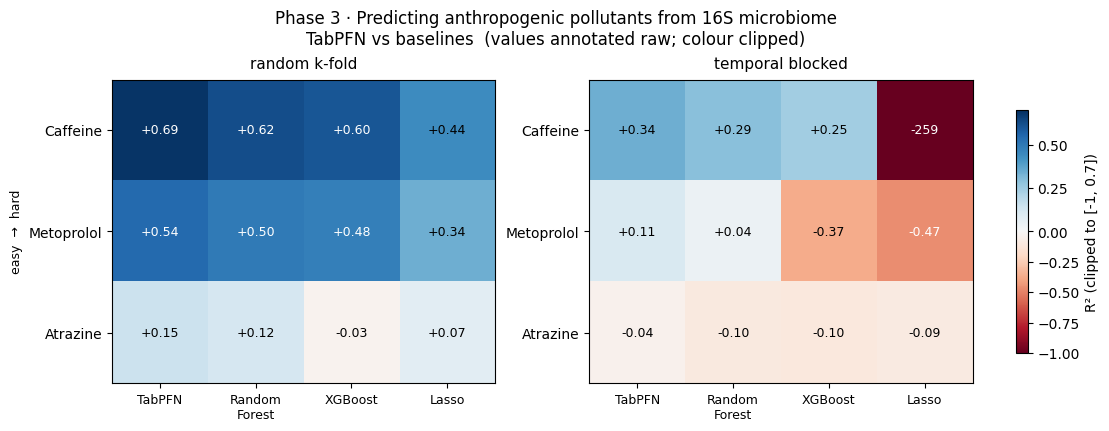

In [17]:
# ── CELL 3: four-model comparison heatmap (Phase 3) ─────────────────────────
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

MODEL_ORDER  = ['tabpfn', 'random_forest', 'xgboost', 'lasso']
MODEL_LABEL  = {'tabpfn': 'TabPFN', 'random_forest': 'Random\nForest',
                'xgboost': 'XGBoost', 'lasso': 'Lasso'}
STRAT_LABEL  = {'random_kfold': 'random\nk-fold',
                'temporal_blocked_kfold': 'temporal\nblocked'}

CLIP_LO, CLIP_HI = -1.0, 0.7          # readable range; extreme values annotated raw

comp = pd.read_csv(RESULTS / 'phase3_fourmodel_comparison_16S.csv')

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), constrained_layout=True)

for ax, strat in zip(axes, ['random_kfold', 'temporal_blocked_kfold']):
    sub = comp[comp.strategy == strat]
    M = (sub.pivot(index='target_name', columns='model', values='r2_mean')
            .reindex(index=GRADIENT, columns=MODEL_ORDER))

    raw     = M.values.astype(float)
    clipped = np.clip(raw, CLIP_LO, CLIP_HI)

    norm = TwoSlopeNorm(vmin=CLIP_LO, vcenter=0.0, vmax=CLIP_HI)
    im = ax.imshow(clipped, cmap='RdBu', norm=norm, aspect='auto')

    # annotate every cell with the RAW value (not clipped)
    for i in range(raw.shape[0]):
        for j in range(raw.shape[1]):
            v = raw[i, j]
            txt = f'{v:+.2f}' if v > -10 else f'{v:+.0f}'   # compact for big negatives
            # white text on dark cells, black on light
            cell = clipped[i, j]
            tc = 'white' if (cell < -0.45 or cell > 0.45) else 'black'
            ax.text(j, i, txt, ha='center', va='center', color=tc, fontsize=9)

    ax.set_xticks(range(len(MODEL_ORDER)))
    ax.set_xticklabels([MODEL_LABEL[m] for m in MODEL_ORDER], fontsize=9)
    ax.set_yticks(range(len(GRADIENT)))
    ax.set_yticklabels(GRADIENT, fontsize=10)
    ax.set_title(STRAT_LABEL[strat].replace('\n', ' '), fontsize=11, pad=8)
    # difficulty-gradient arrow on the left plot only
    if strat == 'random_kfold':
        ax.set_ylabel('easy  →  hard', fontsize=9)

fig.colorbar(im, ax=axes, shrink=0.8, label='R² (clipped to [-1, 0.7])',
             location='right')
fig.suptitle('Phase 3 · Predicting anthropogenic pollutants from 16S microbiome\n'
             'TabPFN vs baselines  (values annotated raw; colour clipped)',
             fontsize=12)

out_png = RESULTS / 'phase3_fourmodel_heatmap.png'
fig.savefig(out_png, dpi=150, bbox_inches='tight')
print(f'saved → {out_png}')
plt.show()

In [18]:
# ── CELL 4-probe: is the data suitable for forecasting? (diagnostic only) ────
#   Forecasting needs, per site, a regularly-spaced time series so we can link
#   ASV(week t) -> pollutant(week t+k). This checks whether that structure
#   actually exists before we build anything.
import numpy as np
import pandas as pd

# meta already has: location_name, cw_id (calendar week), year_id, date
probe = meta.copy()
probe['date'] = pd.to_datetime(probe['date'], errors='coerce')

# --- 1. sampling cadence per site: how regular is it? -----------------------
print('=== Per-site temporal coverage ===')
print(f"{'site':<26s}{'n':>5s}{'span_days':>11s}{'median_gap':>12s}{'max_gap':>9s}")
print('-'*63)
gaps_all = []
for site, g in probe.groupby('location_name'):
    d = g['date'].dropna().sort_values()
    if len(d) < 3:
        print(f'{site:<26s}{len(d):>5d}   (too few)')
        continue
    gaps = d.diff().dt.days.dropna()
    gaps_all.append(gaps)
    span = (d.max() - d.min()).days
    print(f'{site:<26s}{len(d):>5d}{span:>11d}{gaps.median():>12.1f}{gaps.max():>9.0f}')

allg = pd.concat(gaps_all)
print(f'\nOverall gap distribution (days between consecutive samples per site):')
print(f'  median={allg.median():.1f}  mean={allg.mean():.1f}  '
      f'min={allg.min():.0f}  max={allg.max():.0f}')
print(f'  gaps ≤ 4 days : {100*(allg<=4).mean():.0f}%   '
      f'(twice-weekly-ish)')
print(f'  gaps 5–10 days: {100*((allg>4)&(allg<=10)).mean():.0f}%   (weekly-ish)')
print(f'  gaps > 14 days: {100*(allg>14).mean():.0f}%   (broken continuity)')

# --- 2. temporal autocorrelation of each target (does the past predict?) ----
#   If a pollutant has NO week-to-week memory, forecasting is hopeless
#   regardless of the microbiome. This is the key go/no-go signal.
print('\n=== Target temporal autocorrelation (lag-1, within site) ===')
print('   (how much this week\'s value predicts next sampling\'s value)')
for c in GRADIENT:
    r1 = []
    for site, g in probe.groupby('location_name'):
        s = g.sort_values('date')[c].dropna()
        if len(s) >= 10:
            r = s.autocorr(lag=1)
            if not np.isnan(r):
                r1.append(r)
    if r1:
        print(f'  {c:<12s} median lag-1 autocorr = {np.median(r1):+.3f}   '
              f'(n_sites={len(r1)})')

print('\ninterpretation:')
print('  autocorr > 0.4  → strong memory, forecasting plausible')
print('  autocorr ~ 0.2  → weak memory, forecasting hard but maybe rank signal')
print('  autocorr < 0.1  → no memory, event-driven, forecasting likely futile')

=== Per-site temporal coverage ===
site                          n  span_days  median_gap  max_gap
---------------------------------------------------------------
Boergerende Strand          110        385         4.0        7
Diedrichshagen              110        389         4.0        7
Elmenhorst Strand           109        385         4.0        7
Jemnitzschleuse             109        385         4.0        7
Mittelmole Warnemuende      111        389         4.0        7
Muehlendamm                 109        389         4.0       11
Neptun-Werft                111        389         4.0        7
Parkplatz zur Warnow        110        389         4.0        7
SAB Marina Bramow           109        389         4.0       10
Schmarl-Dorf / IGA-Park     109        389         4.0        7
Schwimmhalle Gehlsdorf      111        389         4.0        7
Stadthafen Rostock          111        389         4.0        7
Steilkueste Nienhagen       110        385         4.0        7
Warne

/mnt/data/home/tv2414/miniconda3/envs/thesis/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]


In [22]:
# ── CELL 4.1: build the lagged forecasting frame  ASV(t) → pollutant(t+k) ────
#   For each site, order samples by date, then pair row i (features) with
#   row i+k (target). k counts SAMPLING STEPS (~4 days each), not calendar days.
#   A max-gap guard drops pairs where the real time gap is unexpectedly large
#   (so 'week ahead' stays meaningful).
import numpy as np
import pandas as pd

FORECAST_TARGETS = ['Caffeine', 'Metoprolol', 'Atrazine']
HORIZONS         = [1, 2, 3]          # sampling steps ahead (~4, 8, 12 days)
MAX_STEP_DAYS    = 6                  # a single step must be ≤ this many days
                                      # (median gap is 4; allows a little slack)

meta_f = meta.copy()
meta_f['date'] = pd.to_datetime(meta_f['date'], errors='coerce')

def build_lagged_index(k):
    """
    Return a list of (feat_pos, targ_pos) integer-location pairs into meta_f,
    such that both rows are the SAME site, targ is k sampling steps after feat,
    and every intermediate step is ≤ MAX_STEP_DAYS (no hidden long gaps).
    """
    pairs = []
    for site, g in meta_f.groupby('location_name'):
        g = g.sort_values('date')
        pos   = g.index.to_numpy()               # original meta indices, time-ordered
        dates = g['date'].to_numpy()
        for i in range(len(pos) - k):
            # check every consecutive step from i..i+k is short enough
            step_days = np.diff(dates[i:i+k+1]).astype('timedelta64[D]').astype(int)
            if (step_days <= MAX_STEP_DAYS).all():
                pairs.append((pos[i], pos[i+k]))
    return pairs

# ---- report how many usable pairs each horizon yields ----
print(f"{'horizon (steps)':<18s}{'~days':>7s}{'n_pairs':>10s}{'n_sites':>9s}")
print('-'*44)
LAG_PAIRS = {}
for k in HORIZONS:
    pairs = build_lagged_index(k)
    LAG_PAIRS[k] = pairs
    # how many distinct sites contribute
    feat_pos = [p[0] for p in pairs]
    nsites = meta_f.loc[feat_pos, 'location_name'].nunique()
    print(f'{k:<18d}{4*k:>7d}{len(pairs):>10d}{nsites:>9d}')

# ---- sanity checks on the k=1 pairing --------------------------------------
print('\n=== sanity check · horizon k=1 ===')
p = LAG_PAIRS[1]
fpos = [x[0] for x in p]; tpos = [x[1] for x in p]
same_site = (meta_f.loc[fpos, 'location_name'].to_numpy() ==
             meta_f.loc[tpos, 'location_name'].to_numpy())
gap_days = (meta_f.loc[tpos, 'date'].to_numpy() -
            meta_f.loc[fpos, 'date'].to_numpy()).astype('timedelta64[D]').astype(int)
print(f'  pairs total          : {len(p)}')
print(f'  all same-site        : {same_site.all()}   ({same_site.mean()*100:.0f}%)')
print(f'  gap days: median={np.median(gap_days):.0f}  '
      f'min={gap_days.min()}  max={gap_days.max()}')
print(f'  (expect ~4 days, since k=1 = one sampling step)')

# show 3 example pairs
print('\n  example pairs (feat_date → targ_date, site):')
for fp, tp in p[:3]:
    print(f'    {meta_f.loc[fp,"date"].date()} → {meta_f.loc[tp,"date"].date()}  '
          f'{meta_f.loc[fp,"location_name"]}')

horizon (steps)     ~days   n_pairs  n_sites
--------------------------------------------
1                       4      1501       14
2                       8      1468       14
3                      12      1438       14

=== sanity check · horizon k=1 ===
  pairs total          : 1501
  all same-site        : True   (100%)
  gap days: median=4  min=3  max=4
  (expect ~4 days, since k=1 = one sampling step)

  example pairs (feat_date → targ_date, site):
    2022-04-21 → 2022-04-25  Boergerende Strand
    2022-04-25 → 2022-04-28  Boergerende Strand
    2022-04-28 → 2022-05-02  Boergerende Strand


In [19]:
# ── CELL 4.2 (final, date-based): global cut B + per-site A ──────────────────
import numpy as np
import pandas as pd
from sklearn.metrics import r2_score, mean_absolute_error
from scipy.stats import spearmanr

TEST_FRACTION = 0.30

for c in FORECAST_TARGETS:
    meta_f[c] = pd.to_numeric(meta_f[c], errors='coerce').astype(float)

# ---- ONE fixed global cut date for ALL horizons (your point #1) ------------
#   Based on the full sample timeline, independent of k, so every horizon is
#   evaluated against the same train/test boundary in wall-clock time.
all_dates = meta_f['date'].dropna().sort_values()
GLOBAL_CUT = all_dates.quantile(1 - TEST_FRACTION)
print(f'GLOBAL_CUT = {GLOBAL_CUT.date()}  '
      f'(train before, test after — same for k=1,2,3)\n')

# ---- SPLIT B: strict date-based, no STEP_DAYS, no approximate purge --------
def split_global(pairs):
    """
    Train: pairs whose TARGET date  <  GLOBAL_CUT   (no future info at all)
    Test:  pairs whose FEATURE date >= GLOBAL_CUT   (predict the future period)
    Boundary pairs (feature < cut <= target) are dropped by construction —
    they belong to neither set. This is the point #2 fix: using target_date
    for the train condition provably keeps every future target out of train.
    """
    df = meta_f
    train, test = [], []
    for fp, tp in pairs:
        f_date = df.loc[fp, 'date']
        t_date = df.loc[tp, 'date']
        if t_date < GLOBAL_CUT:            # entire pair (incl. its target) is past
            train.append((fp, tp))
        elif f_date >= GLOBAL_CUT:         # feature already in the future period
            test.append((fp, tp))
        # else boundary pair (f<cut<=t): dropped
    return train, test

# ---- SPLIT A: per-site chronology (complementary, site-aware) --------------
def split_persite(pairs, k, test_fraction=TEST_FRACTION):
    df = meta_f
    by_site = {}
    for fp, tp in pairs:
        by_site.setdefault(df.loc[fp, 'location_name'], []).append((fp, tp))
    train, test = [], []
    for site, pl in by_site.items():
        pl.sort(key=lambda x: df.loc[x[0], 'date'])
        cut = int(len(pl) * (1 - test_fraction))
        train.extend(pl[:max(0, cut - k)])    # drop last k (purge)
        test.extend(pl[cut:])
    return train, test

# ---- date-based leakage proof: no train TARGET reaches into test period ----
def verify_dates(train, test, label):
    df = meta_f
    if not train or not test:
        return 'EMPTY'
    max_train_target = max(df.loc[tp, 'date'] for _, tp in train)
    min_test_feature = min(df.loc[fp, 'date'] for fp, _ in test)
    # the decisive check: latest training target must be < earliest test feature
    ok = max_train_target < min_test_feature
    return (f'{"CLEAN ✓" if ok else "LEAK ✗"}  '
            f'(max train target={max_train_target.date()}, '
            f'min test feature={min_test_feature.date()})')

print('=== date-based leakage proof · both splits · all horizons ===')
SPLITS = {}
for k in HORIZONS:
    trB, teB = split_global(LAG_PAIRS[k])
    trA, teA = split_persite(LAG_PAIRS[k], k)
    SPLITS[('B', k)] = (trB, teB)
    SPLITS[('A', k)] = (trA, teA)
    print(f'k={k}:')
    print(f'  B_global  train={len(trB):4d} test={len(teB):4d}  {verify_dates(trB, teB, "B")}')
    print(f'  A_persite train={len(trA):4d} test={len(teA):4d}  '
          f'(site-aware; global chronology not expected to hold)')
print()

# ---- persistence baseline · SPLIT B (main) ---------------------------------
def persistence(test_pairs, target_col):
    df = meta_f
    fpos = np.array([p[0] for p in test_pairs])
    tpos = np.array([p[1] for p in test_pairs])
    y_now  = df.loc[fpos, target_col].to_numpy(dtype=float)
    y_next = df.loc[tpos, target_col].to_numpy(dtype=float)
    valid  = ~(np.isnan(y_now) | np.isnan(y_next))
    yn, yx = y_now[valid], y_next[valid]
    return dict(n=int(valid.sum()), r2=r2_score(yx, yn),
                mae=mean_absolute_error(yx, yn),
                spearman=spearmanr(yx, yn).correlation)

print('=== PERSISTENCE baseline — SPLIT B (global, main analysis) ===')
print(f"{'target':<12s}{'k':>3s}{'n':>7s}{'R²':>9s}{'MAE':>9s}{'Spear':>9s}")
print('-'*49)
persist_B = {}
for c in FORECAST_TARGETS:
    for k in HORIZONS:
        s = persistence(SPLITS[('B', k)][1], c)
        persist_B[(c, k)] = s
        print(f'{c:<12s}{k:>3d}{s["n"]:>7d}{s["r2"]:>+9.3f}{s["mae"]:>9.3f}{s["spearman"]:>+9.3f}')
    print()

GLOBAL_CUT = 2023-01-16  (train before, test after — same for k=1,2,3)

=== date-based leakage proof · both splits · all horizons ===
k=1:
  B_global  train=1044 test= 443  CLEAN ✓  (max train target=2023-01-12, min test feature=2023-01-16)
  A_persite train=1031 test= 456  (site-aware; global chronology not expected to hold)
k=2:
  B_global  train=1020 test= 420  CLEAN ✓  (max train target=2023-01-12, min test feature=2023-01-16)
  A_persite train= 990 test= 450  (site-aware; global chronology not expected to hold)
k=3:
  B_global  train= 997 test= 400  CLEAN ✓  (max train target=2023-01-12, min test feature=2023-01-16)
  A_persite train= 958 test= 438  (site-aware; global chronology not expected to hold)

=== PERSISTENCE baseline — SPLIT B (global, main analysis) ===
target        k      n       R²      MAE    Spear
-------------------------------------------------
Caffeine      1    282   -0.238   13.233   +0.564
Caffeine      2    264   -1.108   15.462   +0.525
Caffeine      3    2

In [25]:
# ── CELL 4.2 FINAL: global + per-site temporal splits and persistence ────────
#
# Main analysis:
#   Split B — one fixed global chronological cutoff
#
# Complementary analysis:
#   Split A — site-wise chronological cutoff
#
# Important:
#   Censored values (<LOD and #LOQ) are assumed to have already been replaced
#   with zero in the primary dataset. This cell does NOT perform censoring
#   substitution; it only verifies that target columns are numeric.
# ─────────────────────────────────────────────────────────────────────────────

import numpy as np
import pandas as pd

from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error,
)

from scipy.stats import spearmanr


# ============================================================================
# 1. CONFIGURATION AND DATA VALIDATION
# ============================================================================

TEST_FRACTION = 0.30

REQUIRED_COLUMNS = [
    'date',
    'location_name',
    *FORECAST_TARGETS,
]

missing_columns = [
    col for col in REQUIRED_COLUMNS
    if col not in meta_f.columns
]

if missing_columns:
    raise KeyError(
        f'Missing required columns in meta_f: {missing_columns}'
    )

if not meta_f.index.is_unique:
    raise ValueError(
        'meta_f index is not unique. Lagged pair indices would be ambiguous.'
    )

meta_f['date'] = pd.to_datetime(
    meta_f['date'],
    errors='coerce'
)

if meta_f['date'].isna().any():
    n_missing_dates = int(meta_f['date'].isna().sum())

    raise ValueError(
        f'meta_f contains {n_missing_dates} missing or invalid dates. '
        'Clean dates before running the forecasting split.'
    )

if meta_f['location_name'].isna().any():
    n_missing_sites = int(meta_f['location_name'].isna().sum())

    raise ValueError(
        f'meta_f contains {n_missing_sites} rows without location_name.'
    )


# Verify that zero-substituted targets are already numeric.
# Non-numeric, non-missing values are not silently converted to NaN.
for target in FORECAST_TARGETS:

    raw_values = meta_f[target]

    numeric_values = pd.to_numeric(
        raw_values,
        errors='coerce'
    )

    newly_invalid = (
        raw_values.notna()
        & numeric_values.isna()
    )

    if newly_invalid.any():
        examples = (
            raw_values.loc[newly_invalid]
            .astype(str)
            .drop_duplicates()
            .head(5)
            .tolist()
        )

        raise ValueError(
            f'{target} still contains non-numeric values, for example: '
            f'{examples}. Apply the selected censoring treatment '
            f'(<LOD/#LOQ → 0 for the primary analysis) before this cell.'
        )

    meta_f[target] = numeric_values.astype(float)


# ============================================================================
# 2. ONE FIXED GLOBAL CUTOFF FOR ALL HORIZONS
# ============================================================================

# Use unique sampling dates so dates with more samples do not receive
# disproportionate weight.
unique_dates = pd.DatetimeIndex(
    meta_f['date']
    .dropna()
    .unique()
).sort_values()

if len(unique_dates) < 2:
    raise ValueError(
        'At least two unique sampling dates are required.'
    )

cut_index = int(
    np.floor(
        len(unique_dates)
        * (1.0 - TEST_FRACTION)
    )
)

# Guarantee at least one date before and one date from/after the cutoff.
cut_index = min(
    max(cut_index, 1),
    len(unique_dates) - 1
)

GLOBAL_CUT = pd.Timestamp(
    unique_dates[cut_index]
)

print('=== GLOBAL FORECASTING CUTOFF ===')
print(f'Unique sampling dates : {len(unique_dates)}')
print(f'First sampling date   : {unique_dates.min().date()}')
print(f'Last sampling date    : {unique_dates.max().date()}')
print(f'Fixed global cutoff   : {GLOBAL_CUT.date()}')
print(
    'Definition           : '
    'train target < cutoff; test feature >= cutoff'
)
print()


# ============================================================================
# 3. SPLIT B — GLOBAL CHRONOLOGY, MAIN ANALYSIS
# ============================================================================

def split_global(pairs, cutoff=GLOBAL_CUT):
    """
    Strict global temporal forecasting split.

    Training pair:
        target_date < cutoff

    Test pair:
        feature_date >= cutoff

    Boundary pair:
        feature_date < cutoff <= target_date

    Boundary pairs are dropped. Therefore:

        - no future target enters training;
        - all test forecasts originate in the future period;
        - train and test are strictly separated in wall-clock time.

    Returns
    -------
    train_pairs : list[tuple]
    test_pairs : list[tuple]
    dropped_boundary_pairs : list[tuple]
    """
    train_pairs = []
    test_pairs = []
    dropped_boundary_pairs = []

    for feature_pos, target_pos in pairs:

        feature_date = meta_f.loc[
            feature_pos,
            'date'
        ]

        target_date = meta_f.loc[
            target_pos,
            'date'
        ]

        if target_date < cutoff:
            train_pairs.append(
                (feature_pos, target_pos)
            )

        elif feature_date >= cutoff:
            test_pairs.append(
                (feature_pos, target_pos)
            )

        else:
            # feature_date < cutoff <= target_date
            dropped_boundary_pairs.append(
                (feature_pos, target_pos)
            )

    return (
        train_pairs,
        test_pairs,
        dropped_boundary_pairs,
    )


# ============================================================================
# 4. SPLIT A — PER-SITE CHRONOLOGY, COMPLEMENTARY ANALYSIS
# ============================================================================

def split_persite(
    pairs,
    test_fraction=TEST_FRACTION
):
    """
    Site-wise temporal holdout.

    For each site:

      1. Sort lagged pairs by feature date.
      2. Assign the later fraction to Test.
      3. Keep a candidate Train pair only when its target date is strictly
         earlier than the first Test feature date for that site.

    This retains the complete later Test period while removing boundary
    overlap using actual dates rather than mechanically deleting k pairs.

    Returns
    -------
    train_pairs : list[tuple]
    test_pairs : list[tuple]
    dropped_boundary_pairs : list[tuple]
    site_split_info : pandas.DataFrame
    """
    pairs_by_site = {}

    for feature_pos, target_pos in pairs:

        site = meta_f.loc[
            feature_pos,
            'location_name'
        ]

        pairs_by_site.setdefault(
            site,
            []
        ).append(
            (feature_pos, target_pos)
        )

    train_pairs = []
    test_pairs = []
    dropped_boundary_pairs = []
    site_records = []

    for site, site_pairs in pairs_by_site.items():

        site_pairs = sorted(
            site_pairs,
            key=lambda pair: meta_f.loc[
                pair[0],
                'date'
            ]
        )

        n_pairs = len(site_pairs)

        if n_pairs < 2:
            site_records.append({
                'site': site,
                'n_total_pairs': n_pairs,
                'n_train_pairs': 0,
                'n_test_pairs': 0,
                'n_boundary_dropped': 0,
                'first_test_feature_date': pd.NaT,
            })
            continue

        cut_index = int(
            np.floor(
                n_pairs
                * (1.0 - test_fraction)
            )
        )

        cut_index = min(
            max(cut_index, 1),
            n_pairs - 1
        )

        candidate_train = site_pairs[:cut_index]
        site_test = site_pairs[cut_index:]

        first_test_feature_date = min(
            meta_f.loc[
                feature_pos,
                'date'
            ]
            for feature_pos, _ in site_test
        )

        site_train = []
        site_dropped = []

        for feature_pos, target_pos in candidate_train:

            target_date = meta_f.loc[
                target_pos,
                'date'
            ]

            if target_date < first_test_feature_date:
                site_train.append(
                    (feature_pos, target_pos)
                )
            else:
                site_dropped.append(
                    (feature_pos, target_pos)
                )

        train_pairs.extend(site_train)
        test_pairs.extend(site_test)
        dropped_boundary_pairs.extend(site_dropped)

        site_records.append({
            'site': site,
            'n_total_pairs': n_pairs,
            'n_train_pairs': len(site_train),
            'n_test_pairs': len(site_test),
            'n_boundary_dropped': len(site_dropped),
            'first_test_feature_date': first_test_feature_date,
        })

    site_split_info = pd.DataFrame(
        site_records
    )

    return (
        train_pairs,
        test_pairs,
        dropped_boundary_pairs,
        site_split_info,
    )


# ============================================================================
# 5. LEAKAGE AND OVERLAP VERIFICATION
# ============================================================================

def physical_rows(pairs):
    """
    Return every physical sample row used as either a feature or a target.
    """
    return {
        row
        for pair in pairs
        for row in pair
    }


def verify_row_overlap(train_pairs, test_pairs):
    """
    Count physical sample rows appearing anywhere in both Train and Test.
    """
    train_rows = physical_rows(
        train_pairs
    )

    test_rows = physical_rows(
        test_pairs
    )

    overlap = train_rows.intersection(
        test_rows
    )

    return overlap


def verify_global_split(
    train_pairs,
    test_pairs,
    cutoff=GLOBAL_CUT
):
    """
    Verify strict global chronology and physical-row separation.
    """
    if not train_pairs or not test_pairs:
        return {
            'valid': False,
            'all_train_targets_before_cut': False,
            'all_test_features_after_cut': False,
            'strict_time_separation': False,
            'n_shared_rows': np.nan,
            'latest_train_target': pd.NaT,
            'earliest_test_feature': pd.NaT,
        }

    train_target_dates = pd.DatetimeIndex([
        meta_f.loc[target_pos, 'date']
        for _, target_pos in train_pairs
    ])

    test_feature_dates = pd.DatetimeIndex([
        meta_f.loc[feature_pos, 'date']
        for feature_pos, _ in test_pairs
    ])

    latest_train_target = (
        train_target_dates.max()
    )

    earliest_test_feature = (
        test_feature_dates.min()
    )

    all_train_targets_before_cut = bool(
        (train_target_dates < cutoff).all()
    )

    all_test_features_after_cut = bool(
        (test_feature_dates >= cutoff).all()
    )

    strict_time_separation = bool(
        latest_train_target
        < earliest_test_feature
    )

    overlap = verify_row_overlap(
        train_pairs,
        test_pairs
    )

    valid = bool(
        all_train_targets_before_cut
        and all_test_features_after_cut
        and strict_time_separation
        and len(overlap) == 0
    )

    return {
        'valid': valid,
        'all_train_targets_before_cut':
            all_train_targets_before_cut,
        'all_test_features_after_cut':
            all_test_features_after_cut,
        'strict_time_separation':
            strict_time_separation,
        'n_shared_rows': len(overlap),
        'latest_train_target':
            latest_train_target,
        'earliest_test_feature':
            earliest_test_feature,
    }


def verify_persite_split(
    train_pairs,
    test_pairs
):
    """
    Verify chronology independently inside every site.

    Global chronology is not required for Split A.
    """
    train_by_site = {}
    test_by_site = {}

    for feature_pos, target_pos in train_pairs:

        site = meta_f.loc[
            feature_pos,
            'location_name'
        ]

        train_by_site.setdefault(
            site,
            []
        ).append(
            (feature_pos, target_pos)
        )

    for feature_pos, target_pos in test_pairs:

        site = meta_f.loc[
            feature_pos,
            'location_name'
        ]

        test_by_site.setdefault(
            site,
            []
        ).append(
            (feature_pos, target_pos)
        )

    sites_in_both = sorted(
        set(train_by_site)
        & set(test_by_site)
    )

    violations = []

    for site in sites_in_both:

        latest_train_target = max(
            meta_f.loc[target_pos, 'date']
            for _, target_pos
            in train_by_site[site]
        )

        earliest_test_feature = min(
            meta_f.loc[feature_pos, 'date']
            for feature_pos, _
            in test_by_site[site]
        )

        if not (
            latest_train_target
            < earliest_test_feature
        ):
            violations.append(site)

    overlap = verify_row_overlap(
        train_pairs,
        test_pairs
    )

    valid = bool(
        len(violations) == 0
        and len(overlap) == 0
    )

    return {
        'valid': valid,
        'n_sites_checked': len(sites_in_both),
        'violating_sites': violations,
        'n_shared_rows': len(overlap),
    }


# ============================================================================
# 6. BUILD AND STORE BOTH SPLITS FOR ALL HORIZONS
# ============================================================================

SPLITS = {}
BOUNDARY_DROPPED = {}
PERSITE_SPLIT_INFO = {}

print(
    '=== TEMPORAL SPLIT VERIFICATION · '
    'BOTH SPLITS · ALL HORIZONS ==='
)

print(
    f"{'split':<12}"
    f"{'k':>4}"
    f"{'train':>9}"
    f"{'test':>9}"
    f"{'dropped':>10}"
    f"{'shared':>9}"
    f"{'status':>12}"
)

print('-' * 65)

for k in HORIZONS:

    # Global split B
    train_B, test_B, dropped_B = split_global(
        LAG_PAIRS[k]
    )

    # Per-site split A
    (
        train_A,
        test_A,
        dropped_A,
        site_info_A,
    ) = split_persite(
        LAG_PAIRS[k]
    )

    SPLITS[('B', k)] = (
        train_B,
        test_B,
    )

    SPLITS[('A', k)] = (
        train_A,
        test_A,
    )

    BOUNDARY_DROPPED[('B', k)] = (
        dropped_B
    )

    BOUNDARY_DROPPED[('A', k)] = (
        dropped_A
    )

    PERSITE_SPLIT_INFO[k] = (
        site_info_A
    )

    check_B = verify_global_split(
        train_B,
        test_B
    )

    check_A = verify_persite_split(
        train_A,
        test_A
    )

    print(
        f"{'B_global':<12}"
        f"{k:>4d}"
        f"{len(train_B):>9d}"
        f"{len(test_B):>9d}"
        f"{len(dropped_B):>10d}"
        f"{check_B['n_shared_rows']:>9d}"
        f"{'CLEAN ✓' if check_B['valid'] else 'CHECK ✗':>12}"
    )

    print(
        f"{'A_persite':<12}"
        f"{k:>4d}"
        f"{len(train_A):>9d}"
        f"{len(test_A):>9d}"
        f"{len(dropped_A):>10d}"
        f"{check_A['n_shared_rows']:>9d}"
        f"{'CLEAN ✓' if check_A['valid'] else 'CHECK ✗':>12}"
    )


print('\n=== GLOBAL DATE SEPARATION DETAILS ===')

for k in HORIZONS:

    train_B, test_B = SPLITS[('B', k)]

    check_B = verify_global_split(
        train_B,
        test_B
    )

    print(
        f'k={k}: '
        f'latest train target='
        f'{check_B["latest_train_target"].date()} | '
        f'earliest test feature='
        f'{check_B["earliest_test_feature"].date()} | '
        f'strict separation='
        f'{check_B["strict_time_separation"]}'
    )


# Stop immediately if leakage verification fails.
for k in HORIZONS:

    train_B, test_B = SPLITS[('B', k)]
    train_A, test_A = SPLITS[('A', k)]

    check_B = verify_global_split(
        train_B,
        test_B
    )

    check_A = verify_persite_split(
        train_A,
        test_A
    )

    if not check_B['valid']:
        raise RuntimeError(
            f'Global split leakage/chronology check failed for k={k}.'
        )

    if not check_A['valid']:
        raise RuntimeError(
            f'Per-site split leakage/chronology check failed for k={k}.'
        )


# ============================================================================
# 7. SITE COVERAGE IN THE GLOBAL SPLIT
# ============================================================================

def site_coverage_summary(
    train_pairs,
    test_pairs
):
    """
    Count forecasting pairs contributed by each site.
    """
    train_sites = pd.Series(
        [
            meta_f.loc[
                feature_pos,
                'location_name'
            ]
            for feature_pos, _ in train_pairs
        ],
        dtype='object'
    ).value_counts()

    test_sites = pd.Series(
        [
            meta_f.loc[
                feature_pos,
                'location_name'
            ]
            for feature_pos, _ in test_pairs
        ],
        dtype='object'
    ).value_counts()

    summary = pd.DataFrame({
        'train_pairs': train_sites,
        'test_pairs': test_sites,
    }).fillna(0).astype(int)

    summary['present_in_train'] = (
        summary['train_pairs'] > 0
    )

    summary['present_in_test'] = (
        summary['test_pairs'] > 0
    )

    summary['present_in_both'] = (
        summary['present_in_train']
        & summary['present_in_test']
    )

    return summary.sort_index()


GLOBAL_SITE_COVERAGE = {}

print('\n=== GLOBAL SPLIT SITE COVERAGE ===')

print(
    f"{'k':>3}"
    f"{'train sites':>14}"
    f"{'test sites':>13}"
    f"{'both':>8}"
    f"{'test-only':>12}"
)

print('-' * 50)

for k in HORIZONS:

    train_B, test_B = SPLITS[('B', k)]

    coverage = site_coverage_summary(
        train_B,
        test_B
    )

    GLOBAL_SITE_COVERAGE[k] = coverage

    n_train_sites = int(
        coverage['present_in_train'].sum()
    )

    n_test_sites = int(
        coverage['present_in_test'].sum()
    )

    n_both = int(
        coverage['present_in_both'].sum()
    )

    n_test_only = int(
        (
            coverage['present_in_test']
            & ~coverage['present_in_train']
        ).sum()
    )

    print(
        f'{k:>3d}'
        f'{n_train_sites:>14d}'
        f'{n_test_sites:>13d}'
        f'{n_both:>8d}'
        f'{n_test_only:>12d}'
    )


# ============================================================================
# 8. PERSISTENCE BASELINE
# ============================================================================

def persistence_scores(
    test_pairs,
    target_col
):
    """
    Persistence forecast:

        predicted pollutant(t+k) = observed pollutant(t)

    Both pollutant(t) and pollutant(t+k) must be finite.

    Note:
    The final model-versus-persistence comparison must additionally use
    the same ASV-validity mask. A helper for that is defined below.
    """
    if len(test_pairs) == 0:
        return {
            'n_total': 0,
            'n': 0,
            'r2': np.nan,
            'mae': np.nan,
            'rmse': np.nan,
            'spearman': np.nan,
        }

    feature_positions = np.asarray([
        feature_pos
        for feature_pos, _ in test_pairs
    ])

    target_positions = np.asarray([
        target_pos
        for _, target_pos in test_pairs
    ])

    y_now = meta_f.loc[
        feature_positions,
        target_col
    ].to_numpy(dtype=float)

    y_future = meta_f.loc[
        target_positions,
        target_col
    ].to_numpy(dtype=float)

    valid = (
        np.isfinite(y_now)
        & np.isfinite(y_future)
    )

    y_now_valid = y_now[valid]
    y_future_valid = y_future[valid]

    n_valid = len(y_future_valid)

    if n_valid == 0:
        return {
            'n_total': len(test_pairs),
            'n': 0,
            'r2': np.nan,
            'mae': np.nan,
            'rmse': np.nan,
            'spearman': np.nan,
        }

    mae = mean_absolute_error(
        y_future_valid,
        y_now_valid
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_future_valid,
            y_now_valid
        )
    )

    if (
        n_valid >= 2
        and np.unique(y_future_valid).size > 1
    ):
        r2 = r2_score(
            y_future_valid,
            y_now_valid
        )
    else:
        r2 = np.nan

    if (
        n_valid >= 2
        and np.unique(y_now_valid).size > 1
        and np.unique(y_future_valid).size > 1
    ):
        spearman = spearmanr(
            y_future_valid,
            y_now_valid
        ).correlation
    else:
        spearman = np.nan

    return {
        'n_total': int(len(test_pairs)),
        'n': int(n_valid),
        'r2': float(r2) if np.isfinite(r2) else np.nan,
        'mae': float(mae),
        'rmse': float(rmse),
        'spearman': (
            float(spearman)
            if np.isfinite(spearman)
            else np.nan
        ),
    }


def print_persistence_table(
    split_code,
    title
):
    """
    Calculate and print persistence results for one split.
    """
    results = {}

    print(f'\n=== {title} ===')

    print(
        f"{'target':<13}"
        f"{'k':>4}"
        f"{'n':>8}"
        f"{'R²':>10}"
        f"{'MAE':>10}"
        f"{'RMSE':>10}"
        f"{'Spear':>10}"
    )

    print('-' * 65)

    for target in FORECAST_TARGETS:

        for k in HORIZONS:

            test_pairs = SPLITS[
                (split_code, k)
            ][1]

            scores = persistence_scores(
                test_pairs,
                target
            )

            results[(target, k)] = scores

            print(
                f'{target:<13}'
                f'{k:>4d}'
                f'{scores["n"]:>8d}'
                f'{scores["r2"]:>+10.3f}'
                f'{scores["mae"]:>10.3f}'
                f'{scores["rmse"]:>10.3f}'
                f'{scores["spearman"]:>+10.3f}'
            )

        print()

    return results


# Main forecasting baseline
persist_B = print_persistence_table(
    split_code='B',
    title=(
        'PERSISTENCE BASELINE — '
        'SPLIT B GLOBAL, MAIN ANALYSIS'
    )
)

# Complementary site-aware baseline
persist_A = print_persistence_table(
    split_code='A',
    title=(
        'PERSISTENCE BASELINE — '
        'SPLIT A PER-SITE, COMPLEMENTARY ANALYSIS'
    )
)


# ============================================================================
# 9. HELPER FOR THE LATER MODEL-VS-PERSISTENCE SHARED TEST MASK
# ============================================================================

def shared_model_test_mask(
    X_test,
    y_now,
    y_future
):
    """
    Build the exact common test mask for:

      - the ASV forecasting model;
      - persistence;
      - the true future target.

    Parameters
    ----------
    X_test : array-like, shape (n_test, n_features)
        Already-selected ASV feature rows for the Test pairs.

    y_now : array-like, shape (n_test,)
        Pollutant concentration at time t.

    y_future : array-like, shape (n_test,)
        Pollutant concentration at time t+k.

    Returns
    -------
    common_valid : boolean ndarray
        True only where ASV features, y_now and y_future are all finite.
    """
    if isinstance(X_test, pd.DataFrame):
        X_array = X_test.to_numpy()
    else:
        X_array = np.asarray(X_test)

    if X_array.ndim == 1:
        X_array = X_array.reshape(-1, 1)

    y_now = np.asarray(
        y_now,
        dtype=float
    )

    y_future = np.asarray(
        y_future,
        dtype=float
    )

    if not (
        len(X_array)
        == len(y_now)
        == len(y_future)
    ):
        raise ValueError(
            'X_test, y_now and y_future must have the same number of rows.'
        )

    feature_valid = np.isfinite(
        X_array
    ).all(axis=1)

    target_valid = (
        np.isfinite(y_now)
        & np.isfinite(y_future)
    )

    return (
        feature_valid
        & target_valid
    )

=== GLOBAL FORECASTING CUTOFF ===
Unique sampling dates : 112
First sampling date   : 2022-04-21
Last sampling date    : 2023-05-15
Fixed global cutoff   : 2023-01-19
Definition           : train target < cutoff; test feature >= cutoff

=== TEMPORAL SPLIT VERIFICATION · BOTH SPLITS · ALL HORIZONS ===
split          k    train     test   dropped   shared      status
-----------------------------------------------------------------
B_global       1     1058      429        14        0     CLEAN ✓
A_persite      1     1031      456        14        0     CLEAN ✓
B_global       2     1034      406        28        0     CLEAN ✓
A_persite      2      992      450        26        0     CLEAN ✓
B_global       3     1010      386        42        0     CLEAN ✓
A_persite      3      960      438        40        0     CLEAN ✓

=== GLOBAL DATE SEPARATION DETAILS ===
k=1: latest train target=2023-01-16 | earliest test feature=2023-01-19 | strict separation=True
k=2: latest train target=2023-01-1

In [27]:
# ── CELL 4.3 FINAL: TabPFN forecasting vs persistence ───────────────────────
#
# For each target × horizon × temporal split:
#
#   Train:
#       ASV(feature time t) → pollutant(target time t+k)
#
#   Test:
#       ASV(feature time t) → pollutant(target time t+k)
#
# Two evaluation sets are reported:
#
#   1. model-valid set:
#      ASV(t) and pollutant(t+k) are finite.
#      This measures the full forecasting coverage of TabPFN.
#
#   2. shared-valid set:
#      ASV(t), pollutant(t), and pollutant(t+k) are finite.
#      TabPFN and Persistence are compared on exactly the same rows.
# ─────────────────────────────────────────────────────────────────────────────

import gc
import time
import numpy as np
import pandas as pd

from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error,
)

from scipy.stats import spearmanr

from src.tabpfn_evaluator import (
    _make_tabpfn,
    TABPFN_VERSION,
)


# ============================================================================
# 1. CONFIGURATION
# ============================================================================

FORECAST_INPUT_NAME = '16S'
FORECAST_INPUT = INPUTS[FORECAST_INPUT_NAME]

MIN_TRAIN_SAMPLES = 10
MIN_TEST_SAMPLES = 5


# ============================================================================
# 2. VERIFY ASV–METADATA ALIGNMENT
# ============================================================================

if not isinstance(FORECAST_INPUT, pd.DataFrame):
    raise TypeError(
        f'INPUTS["{FORECAST_INPUT_NAME}"] must be a pandas DataFrame '
        'with sample indices aligned to meta_f.'
    )

if not FORECAST_INPUT.index.is_unique:
    raise ValueError(
        f'INPUTS["{FORECAST_INPUT_NAME}"] contains duplicate row indices.'
    )

if not meta_f.index.is_unique:
    raise ValueError(
        'meta_f contains duplicate row indices.'
    )

missing_in_X = meta_f.index.difference(
    FORECAST_INPUT.index
)

extra_in_X = FORECAST_INPUT.index.difference(
    meta_f.index
)

if len(missing_in_X) > 0 or len(extra_in_X) > 0:
    raise ValueError(
        'The row indices of meta_f and the forecasting ASV matrix do not '
        'match exactly.\n'
        f'Rows missing in X: {len(missing_in_X)}\n'
        f'Extra rows in X: {len(extra_in_X)}'
    )

# Force the exact metadata order while retaining label-based access.
X_ALL = FORECAST_INPUT.loc[
    meta_f.index
].copy()

print('=== FORECASTING INPUT ALIGNMENT ===')
print(f'Input                  : {FORECAST_INPUT_NAME}')
print(f'Samples in meta_f      : {len(meta_f)}')
print(f'Samples in X_ALL       : {len(X_ALL)}')
print(f'ASV features           : {X_ALL.shape[1]}')
print(
    'Exact index alignment :',
    X_ALL.index.equals(meta_f.index)
)
print()


# ============================================================================
# 3. HELPERS
# ============================================================================

def _rows_to_X(positions):
    """
    Select ASV rows using meta_f row labels.

    Parameters
    ----------
    positions : array-like
        Row labels from meta_f.

    Returns
    -------
    ndarray, shape (n_samples, n_features)
    """
    positions = list(positions)

    if len(positions) == 0:
        return np.empty(
            (0, X_ALL.shape[1]),
            dtype=float
        )

    return X_ALL.loc[
        positions
    ].to_numpy(dtype=float)


def _safe_metrics(y_true, y_pred):
    """
    Calculate regression metrics after removing non-finite values.

    R² requires:
      - at least two observations;
      - non-constant y_true.

    Spearman requires:
      - at least two observations;
      - variation in both y_true and y_pred.
    """
    y_true = np.asarray(
        y_true,
        dtype=float
    ).reshape(-1)

    y_pred = np.asarray(
        y_pred,
        dtype=float
    ).reshape(-1)

    if len(y_true) != len(y_pred):
        raise ValueError(
            'y_true and y_pred have different lengths.'
        )

    valid = (
        np.isfinite(y_true)
        & np.isfinite(y_pred)
    )

    y_true = y_true[valid]
    y_pred = y_pred[valid]

    n = len(y_true)

    if n == 0:
        return {
            'n': 0,
            'r2': np.nan,
            'mae': np.nan,
            'rmse': np.nan,
            'spearman': np.nan,
        }

    mae = mean_absolute_error(
        y_true,
        y_pred
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_true,
            y_pred
        )
    )

    if (
        n >= 2
        and np.unique(y_true).size > 1
    ):
        r2 = r2_score(
            y_true,
            y_pred
        )
    else:
        r2 = np.nan

    if (
        n >= 2
        and np.unique(y_true).size > 1
        and np.unique(y_pred).size > 1
    ):
        rho = spearmanr(
            y_true,
            y_pred
        ).correlation
    else:
        rho = np.nan

    return {
        'n': int(n),
        'r2': (
            float(r2)
            if np.isfinite(r2)
            else np.nan
        ),
        'mae': float(mae),
        'rmse': float(rmse),
        'spearman': (
            float(rho)
            if np.isfinite(rho)
            else np.nan
        ),
    }


# ============================================================================
# 4. RUN ONE FORECASTING EXPERIMENT
# ============================================================================

def forecast_one(
    target_col,
    split_code,
    k
):
    """
    Train one TabPFN forecasting model and compare it with Persistence.

    Main comparison:
        TabPFN and Persistence are scored on the same shared-valid rows.

    Additional result:
        TabPFN is also scored on all model-valid Test rows, including rows
        where pollutant(t) is unavailable and Persistence cannot be used.
    """
    if (
        split_code,
        k
    ) not in SPLITS:
        raise KeyError(
            f'Missing split for split={split_code}, k={k}.'
        )

    train_pairs, test_pairs = SPLITS[
        (split_code, k)
    ]

    if len(train_pairs) == 0 or len(test_pairs) == 0:
        return None

    # ========================================================================
    # TRAIN DATA
    # ========================================================================

    train_feature_positions = np.asarray([
        feature_pos
        for feature_pos, _ in train_pairs
    ])

    train_target_positions = np.asarray([
        target_pos
        for _, target_pos in train_pairs
    ])

    X_train_all = _rows_to_X(
        train_feature_positions
    )

    y_train_all = meta_f.loc[
        train_target_positions,
        target_col
    ].to_numpy(dtype=float)

    train_valid = (
        np.isfinite(X_train_all).all(axis=1)
        & np.isfinite(y_train_all)
    )

    X_train = X_train_all[
        train_valid
    ]

    y_train = y_train_all[
        train_valid
    ]

    n_train = len(y_train)

    if n_train < MIN_TRAIN_SAMPLES:
        return None

    if np.unique(y_train).size < 2:
        return None

    # ========================================================================
    # TEST DATA
    # ========================================================================

    test_feature_positions = np.asarray([
        feature_pos
        for feature_pos, _ in test_pairs
    ])

    test_target_positions = np.asarray([
        target_pos
        for _, target_pos in test_pairs
    ])

    X_test_all = _rows_to_X(
        test_feature_positions
    )

    # Persistence prediction:
    # pollutant concentration at feature time t
    y_now_all = meta_f.loc[
        test_feature_positions,
        target_col
    ].to_numpy(dtype=float)

    # Forecasting truth:
    # pollutant concentration at target time t+k
    y_future_all = meta_f.loc[
        test_target_positions,
        target_col
    ].to_numpy(dtype=float)

    feature_valid = np.isfinite(
        X_test_all
    ).all(axis=1)

    future_target_valid = np.isfinite(
        y_future_all
    )

    current_target_valid = np.isfinite(
        y_now_all
    )

    # All rows on which TabPFN can be evaluated.
    model_valid = (
        feature_valid
        & future_target_valid
    )

    # Exact comparison subset for TabPFN versus Persistence.
    shared_valid = (
        model_valid
        & current_target_valid
    )

    n_model_available = int(
        model_valid.sum()
    )

    n_shared_available = int(
        shared_valid.sum()
    )

    if n_model_available < MIN_TEST_SAMPLES:
        return None

    if n_shared_available < MIN_TEST_SAMPLES:
        return None

    # Predict all model-valid rows once.
    X_test_model = X_test_all[
        model_valid
    ]

    y_future_model = y_future_all[
        model_valid
    ]

    y_now_model = y_now_all[
        model_valid
    ]

    # Inside model_valid, shared rows are those with finite pollutant(t).
    shared_within_model = np.isfinite(
        y_now_model
    )

    # ========================================================================
    # TABPFN FIT AND PREDICTION
    # ========================================================================

    start_time = time.time()

    regressor = _make_tabpfn(
        RANDOM_SEED,
        model_path=MODEL_PATH
    )

    regressor.fit(
        X_train,
        y_train
    )

    y_pred_model = np.asarray(
        regressor.predict(
            X_test_model
        ),
        dtype=float
    ).reshape(-1)

    elapsed_seconds = (
        time.time()
        - start_time
    )

    if len(y_pred_model) != len(y_future_model):
        raise RuntimeError(
            'TabPFN returned a different number of predictions '
            'than the number of Test rows.'
        )

    # Exclude any unexpected non-finite TabPFN predictions.
    prediction_valid = np.isfinite(
        y_pred_model
    )

    # Full model evaluation.
    full_eval_mask = prediction_valid

    # Exact shared comparison evaluation.
    shared_eval_mask = (
        shared_within_model
        & prediction_valid
    )

    y_future_full = y_future_model[
        full_eval_mask
    ]

    y_pred_full = y_pred_model[
        full_eval_mask
    ]

    y_future_shared = y_future_model[
        shared_eval_mask
    ]

    y_pred_shared = y_pred_model[
        shared_eval_mask
    ]

    y_now_shared = y_now_model[
        shared_eval_mask
    ]

    if len(y_future_shared) < MIN_TEST_SAMPLES:
        del regressor
        gc.collect()
        return None

    # ========================================================================
    # METRICS
    # ========================================================================

    # TabPFN over every Test row on which the model can be evaluated.
    tab_full = _safe_metrics(
        y_future_full,
        y_pred_full
    )

    # Exact comparison subset.
    tab_shared = _safe_metrics(
        y_future_shared,
        y_pred_shared
    )

    persistence_shared = _safe_metrics(
        y_future_shared,
        y_now_shared
    )

    del regressor
    gc.collect()

    return {
        'target': target_col,
        'input': FORECAST_INPUT_NAME,
        'split': split_code,
        'horizon_k': int(k),

        'n_train_pairs_total': int(
            len(train_pairs)
        ),
        'n_train': int(n_train),

        'n_test_pairs_total': int(
            len(test_pairs)
        ),
        'n_model_eval': int(
            tab_full['n']
        ),
        'n_shared_eval': int(
            tab_shared['n']
        ),

        'fit_predict_seconds': float(
            elapsed_seconds
        ),

        # TabPFN on its complete evaluable Test set
        'tab_full_r2': tab_full['r2'],
        'tab_full_mae': tab_full['mae'],
        'tab_full_rmse': tab_full['rmse'],
        'tab_full_rho': tab_full['spearman'],

        # TabPFN on exact Persistence-comparable subset
        'tab_shared_r2': tab_shared['r2'],
        'tab_shared_mae': tab_shared['mae'],
        'tab_shared_rmse': tab_shared['rmse'],
        'tab_shared_rho': tab_shared['spearman'],

        # Persistence on exactly the same subset
        'per_shared_r2': persistence_shared['r2'],
        'per_shared_mae': persistence_shared['mae'],
        'per_shared_rmse': persistence_shared['rmse'],
        'per_shared_rho': persistence_shared['spearman'],

        # Direct differences: positive ΔR² is better for TabPFN;
        # negative ΔMAE and ΔRMSE are better for TabPFN.
        'delta_r2': (
            tab_shared['r2']
            - persistence_shared['r2']
            if (
                np.isfinite(tab_shared['r2'])
                and np.isfinite(
                    persistence_shared['r2']
                )
            )
            else np.nan
        ),

        'delta_mae': (
            tab_shared['mae']
            - persistence_shared['mae']
        ),

        'delta_rmse': (
            tab_shared['rmse']
            - persistence_shared['rmse']
        ),
    }


# ============================================================================
# 5. RUN GRID
# ============================================================================

print(
    f'TabPFN forecasting · '
    f'version {TABPFN_VERSION} · '
    f'input={FORECAST_INPUT_NAME}'
)

print('=' * 96)

forecast_results = []
grid_start_time = time.time()

for split_code, split_name in [
    ('B', 'global — main'),
    ('A', 'per-site — complementary'),
]:

    print(
        f'\n── SPLIT {split_code}: '
        f'{split_name} ──'
    )

    print(
        f"{'target':<13}"
        f"{'k':>4}"
        f"{'train':>8}"
        f"{'shared':>8}"
        f"{'Tab R²':>10}"
        f"{'Per R²':>10}"
        f"{'ΔR²':>9}"
        f"{'Tab MAE':>10}"
        f"{'Per MAE':>10}"
    )

    print('-' * 82)

    for target in FORECAST_TARGETS:

        for k in HORIZONS:

            result = forecast_one(
                target_col=target,
                split_code=split_code,
                k=k
            )

            if result is None:
                print(
                    f'{target:<13}'
                    f'{k:>4d}  '
                    f'INSUFFICIENT OR INVALID DATA'
                )
                continue

            forecast_results.append(
                result
            )

            print(
                f'{target:<13}'
                f'{k:>4d}'
                f'{result["n_train"]:>8d}'
                f'{result["n_shared_eval"]:>8d}'
                f'{result["tab_shared_r2"]:>+10.3f}'
                f'{result["per_shared_r2"]:>+10.3f}'
                f'{result["delta_r2"]:>+9.3f}'
                f'{result["tab_shared_mae"]:>10.3f}'
                f'{result["per_shared_mae"]:>10.3f}'
            )

        print()


# ============================================================================
# 6. SAVE RESULTS
# ============================================================================

forecast_results_df = pd.DataFrame(
    forecast_results
)

RESULTS.mkdir(
    parents=True,
    exist_ok=True
)

output_path = (
    RESULTS
    / 'phase3_forecasting_tabpfn_vs_persistence.csv'
)

forecast_results_df.to_csv(
    output_path,
    index=False
)

total_minutes = (
    time.time()
    - grid_start_time
) / 60.0

print('=' * 96)
print(
    f'DONE · {total_minutes:.1f} min'
)
print(
    f'Saved to: {output_path}'
)

=== FORECASTING INPUT ALIGNMENT ===
Input                  : 16S
Samples in meta_f      : 1538
Samples in X_ALL       : 1538
ASV features           : 1236
Exact index alignment : True

TabPFN forecasting · version 8.0.6 · input=16S

── SPLIT B: global — main ──
target          k   train  shared    Tab R²    Per R²      ΔR²   Tab MAE   Per MAE
----------------------------------------------------------------------------------
Caffeine        1     953     272    +0.123    -0.239   +0.362    13.167    13.296
Caffeine        2     930     250    +0.228    -1.136   +1.364    12.291    15.550
Caffeine        3     907     222    +0.135    -0.960   +1.095    13.343    14.835

Metoprolol      1     953     276    +0.021    -0.004   +0.025    12.329     9.769
Metoprolol      2     930     252    +0.075    +0.039   +0.036    11.986    11.300
Metoprolol      3     907     224    +0.033    +0.346   -0.313    13.263    10.706

Atrazine        1     951     272    +0.004    -1.124   +1.128     0.101

In [29]:
# ── CELL 4.4: forecasting benchmark via the LOCKED src/ evaluators ──────────
#   Key idea: remap each lagged (feature_row, target_row) pair into a plain
#   cross-sectional row so the untouched src/ evaluators can be used directly.
#     otu_fc[i]  = ASV at the FEATURE time (t)      of pair i
#     meta_fc[i] = pollutant at the TARGET time (t+k) of pair i
#     splits_fc  = positional (train_idx, test_idx) into that reindexed frame
#   The evaluators only ever read otu.values and meta[target_name].values, so
#   they run with IDENTICAL inner GridSearchCV / hyperparameters as Phase 1–2.
#   No model is rebuilt; no hyperparameter is set by hand.
import time
import numpy as np
import pandas as pd

from src.tabpfn_evaluator        import run_tabpfn_with_splits, TABPFN_VERSION
from src.lasso_evaluator         import run_lasso_with_splits
from src.random_forest_evaluator import run_random_forest_with_splits
from src.xgboost_evaluator       import run_xgboost_with_splits

FORECAST_SPLIT   = 'B'                       # global chronological (main)
FORECAST_INPUTS  = ['16S', '18S', '16S+18S']
FC_INPUT_TABLE   = {'16S': INPUTS['16S'], '18S': INPUTS['18S'],
                    '16S+18S': INPUTS['16S+18S']}

def build_forecast_frame(target_col, k, input_table):
    """
    Turn the lagged Split-B pairs for (target, horizon k) into a cross-sectional
    (otu_fc, meta_fc, splits_fc) triple that the src/ evaluators accept as-is.

    Rows are ordered [train pairs ... then test pairs]; splits_fc is the single
    (train_idx, test_idx) holdout matching the global chronological split.
    Only pairs where the ASV features AND the t+k target are finite are kept
    (same validity rule the standalone TabPFN forecaster used).
    """
    train_pairs, test_pairs = SPLITS[(FORECAST_SPLIT, k)]

    def _assemble(pairs):
        f_pos = [fp for fp, _ in pairs]
        t_pos = [tp for _, tp in pairs]
        X = input_table.loc[f_pos].to_numpy(dtype=float)      # ASV at t
        y = meta_f.loc[t_pos, target_col].to_numpy(dtype=float)  # pollutant at t+k
        ok = np.isfinite(X).all(axis=1) & np.isfinite(y)
        return X[ok], y[ok]

    Xtr, ytr = _assemble(train_pairs)
    Xte, yte = _assemble(test_pairs)

    # stack train then test; build one holdout split over positional indices
    X_stack = np.vstack([Xtr, Xte])
    y_stack = np.concatenate([ytr, yte])
    n_tr    = len(ytr)
    train_idx = np.arange(n_tr)
    test_idx  = np.arange(n_tr, n_tr + len(yte))

    otu_fc  = pd.DataFrame(X_stack)                      # evaluators call .values
    meta_fc = pd.DataFrame({target_col: y_stack})       # evaluators read this col
    splits_fc = [(train_idx, test_idx)]                 # single chronological holdout
    return otu_fc, meta_fc, splits_fc, n_tr, len(yte)

MODELS = {
    'lasso':         run_lasso_with_splits,
    'random_forest': run_random_forest_with_splits,
    'xgboost':       run_xgboost_with_splits,
    'tabpfn':        lambda **kw: run_tabpfn_with_splits(model_path=MODEL_PATH, **kw),
}

CSV_COLS = ['model', 'target', 'input', 'horizon_k', 'n_train', 'n_test',
            'r2_mean', 'mae_mean', 'rmse_mean', 'total_time']

def save_partial(rows, path):
    if rows:
        pd.DataFrame(rows)[[c for c in CSV_COLS if c in rows[0]]].to_csv(path, index=False)

OUT = RESULTS / 'phase3_forecasting_all_models_splitB.csv'
n_total = len(MODELS) * len(FORECAST_TARGETS) * len(HORIZONS) * len(FORECAST_INPUTS)

print(f'FORECASTING benchmark (Split B) · {n_total} runs · TabPFN v{TABPFN_VERSION}')
print(f'  models={list(MODELS)}  inputs={FORECAST_INPUTS}  horizons={HORIZONS}')
print('=' * 92)

rows, cell, t0 = [], 0, time.time()
for model_tag, run_fn in MODELS.items():
    for c in FORECAST_TARGETS:
        for inp in FORECAST_INPUTS:
            for k in HORIZONS:
                cell += 1
                otu_fc, meta_fc, splits_fc, n_tr, n_te = build_forecast_frame(
                    c, k, FC_INPUT_TABLE[inp])
                print(f'[{cell:3d}/{n_total}] {model_tag:<14s} {c:<10s} {inp:<8s} '
                      f'k={k}  (train={n_tr}, test={n_te}) ...', flush=True)

                res = run_fn(
                    target_name=c, meta=meta_fc, otu=otu_fc, splits=splits_fc,
                    strategy_name=f'forecast_B_k{k}', input_name=inp,
                    log_target=False, random_seed=RANDOM_SEED, verbose=False,
                )
                rows.append({
                    'model': model_tag, 'target': c, 'input': inp, 'horizon_k': k,
                    'n_train': n_tr, 'n_test': n_te,
                    'r2_mean': res['r2_mean'], 'mae_mean': res['mae_mean'],
                    'rmse_mean': res['rmse_mean'], 'total_time': res['total_time'],
                })
                save_partial(rows, OUT)
                print(f'        → R²={res["r2_mean"]:+.4f}  MAE={res["mae_mean"]:.3f}'
                      f'  ({res["total_time"]:.1f}s)')

print(f'\nDONE · {(time.time()-t0)/60:.1f} min → {OUT.name}')

# ---- readout: best model per target × horizon (16S) ----
fc = pd.DataFrame(rows)
print('\nForecasting R² · 16S · by model × horizon:')
piv = (fc[fc.input=='16S'].pivot_table(index=['target','horizon_k'],
       columns='model', values='r2_mean')
       .reindex(columns=['tabpfn','random_forest','xgboost','lasso']))
print(piv.round(3).to_string())

FORECASTING benchmark (Split B) · 108 runs · TabPFN v8.0.6
  models=['lasso', 'random_forest', 'xgboost', 'tabpfn']  inputs=['16S', '18S', '16S+18S']  horizons=[1, 2, 3]
[  1/108] lasso          Caffeine   16S      k=1  (train=953, test=304) ...
        → R²=+0.0404  MAE=15.825  (164.1s)
[  2/108] lasso          Caffeine   16S      k=2  (train=930, test=288) ...
        → R²=-1.0416  MAE=20.671  (245.7s)
[  3/108] lasso          Caffeine   16S      k=3  (train=907, test=278) ...
        → R²=-1.8040  MAE=18.201  (190.4s)
[  4/108] lasso          Caffeine   18S      k=1  (train=953, test=304) ...
        → R²=-0.7809  MAE=20.138  (47.5s)
[  5/108] lasso          Caffeine   18S      k=2  (train=930, test=288) ...
        → R²=-6.2163  MAE=25.522  (81.5s)
[  6/108] lasso          Caffeine   18S      k=3  (train=907, test=278) ...
        → R²=-731.5056  MAE=262.538  (57.3s)
[  7/108] lasso          Caffeine   16S+18S  k=1  (train=953, test=304) ...
        → R²=+0.0277  MAE=13.937  (66.6s

In [20]:
# ── CELL 4.5: forecasting with a SINGLE shared train+test mask ──────────────
#   Fully controlled comparison: all four models train on the SAME rows and
#   are scored on the SAME test rows; persistence uses that identical test set.
#   Mask = rows where 16S AND 18S ASV are finite (⇒ combined finite too),
#          plus the relevant target(s) finite.
#   src/ evaluators are reused untouched via the same cross-sectional remap.
import time
import numpy as np
import pandas as pd
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from scipy.stats import spearmanr

from src.tabpfn_evaluator        import run_tabpfn_with_splits, TABPFN_VERSION
from src.lasso_evaluator         import run_lasso_with_splits
from src.random_forest_evaluator import run_random_forest_with_splits
from src.xgboost_evaluator       import run_xgboost_with_splits

FORECAST_SPLIT  = 'B'
FORECAST_INPUTS = ['16S', '18S', '16S+18S']
FC_TABLE        = {'16S': INPUTS['16S'], '18S': INPUTS['18S'], '16S+18S': INPUTS['16S+18S']}

def shared_mask_frames(target_col, k):
    """
    Build ONE shared train mask and ONE shared test mask (finite 16S & 18S &
    targets), then return, per input, aligned (otu_fc, meta_fc, splits_fc) plus
    the persistence vectors on the shared test set. Every input uses the exact
    same rows, so n_train and n_test are identical across all models.
    """
    train_pairs, test_pairs = SPLITS[(FORECAST_SPLIT, k)]

    def _mask_and_positions(pairs, need_now):
        f = np.array([fp for fp, _ in pairs])
        t = np.array([tp for _, tp in pairs])
        X16 = INPUTS['16S'].loc[f].to_numpy(dtype=float)
        X18 = INPUTS['18S'].loc[f].to_numpy(dtype=float)
        y_fut = meta_f.loc[t, target_col].to_numpy(dtype=float)
        ok = (np.isfinite(X16).all(1) & np.isfinite(X18).all(1) & np.isfinite(y_fut))
        if need_now:
            y_now = meta_f.loc[f, target_col].to_numpy(dtype=float)
            ok &= np.isfinite(y_now)
        return f, t, ok

    f_tr, t_tr, ok_tr = _mask_and_positions(train_pairs, need_now=False)
    f_te, t_te, ok_te = _mask_and_positions(test_pairs,  need_now=True)

    f_tr, t_tr = f_tr[ok_tr], t_tr[ok_tr]
    f_te, t_te = f_te[ok_te], t_te[ok_te]

    # persistence vectors on the shared test set
    y_now_te = meta_f.loc[f_te, target_col].to_numpy(dtype=float)
    y_fut_te = meta_f.loc[t_te, target_col].to_numpy(dtype=float)

    frames = {}
    for inp in FORECAST_INPUTS:
        tbl = FC_TABLE[inp]
        Xtr = tbl.loc[f_tr].to_numpy(dtype=float)
        Xte = tbl.loc[f_te].to_numpy(dtype=float)
        ytr = meta_f.loc[t_tr, target_col].to_numpy(dtype=float)
        yte = meta_f.loc[t_te, target_col].to_numpy(dtype=float)
        n_tr = len(ytr)
        otu_fc  = pd.DataFrame(np.vstack([Xtr, Xte]))
        meta_fc = pd.DataFrame({target_col: np.concatenate([ytr, yte])})
        splits_fc = [(np.arange(n_tr), np.arange(n_tr, n_tr + len(yte)))]
        frames[inp] = (otu_fc, meta_fc, splits_fc)
    return frames, len(t_tr), len(t_te), y_now_te, y_fut_te

def persistence_metrics(y_fut, y_now):
    m = dict(r2=np.nan, mae=mean_absolute_error(y_fut, y_now),
             rmse=np.sqrt(mean_squared_error(y_fut, y_now)), rho=np.nan)
    if np.unique(y_fut).size > 1:
        m['r2'] = r2_score(y_fut, y_now)
        m['rho'] = spearmanr(y_fut, y_now).correlation
    return m

MODELS = {
    'lasso':         run_lasso_with_splits,
    'random_forest': run_random_forest_with_splits,
    'xgboost':       run_xgboost_with_splits,
    'tabpfn':        lambda **kw: run_tabpfn_with_splits(model_path=MODEL_PATH, **kw),
}

CSV_COLS = ['model', 'target', 'input', 'horizon_k', 'n_train', 'n_test',
            'r2', 'mae', 'rmse', 'per_r2', 'per_mae', 'delta_r2', 'total_time']

def save_partial(rows, path):
    if rows:
        pd.DataFrame(rows)[[c for c in CSV_COLS if c in rows[0]]].to_csv(path, index=False)

OUT = RESULTS / 'phase3_forecasting_shared_mask_splitB.csv'
n_total = len(MODELS) * len(FORECAST_TARGETS) * len(HORIZONS) * len(FORECAST_INPUTS)

print(f'FORECASTING · shared train+test mask · {n_total} runs · TabPFN v{TABPFN_VERSION}')
print('=' * 94)

rows, cell, t0 = [], 0, time.time()
# precompute shared frames + persistence once per (target, k)
for c in FORECAST_TARGETS:
    for k in HORIZONS:
        frames, n_tr, n_te, y_now_te, y_fut_te = shared_mask_frames(c, k)
        per = persistence_metrics(y_fut_te, y_now_te)
        print(f'\n── {c} · k={k} · shared n_train={n_tr} n_test={n_te} · '
              f'persistence R²={per["r2"]:+.3f} MAE={per["mae"]:.3f} ──')

        for model_tag, run_fn in MODELS.items():
            for inp in FORECAST_INPUTS:
                cell += 1
                otu_fc, meta_fc, splits_fc = frames[inp]
                res = run_fn(
                    target_name=c, meta=meta_fc, otu=otu_fc, splits=splits_fc,
                    strategy_name=f'forecast_B_k{k}_shared', input_name=inp,
                    log_target=False, random_seed=RANDOM_SEED, verbose=False,
                )
                dr2 = res['r2_mean'] - per['r2'] if np.isfinite(per['r2']) else np.nan
                rows.append({
                    'model': model_tag, 'target': c, 'input': inp, 'horizon_k': k,
                    'n_train': n_tr, 'n_test': n_te,
                    'r2': res['r2_mean'], 'mae': res['mae_mean'], 'rmse': res['rmse_mean'],
                    'per_r2': per['r2'], 'per_mae': per['mae'], 'delta_r2': dr2,
                    'total_time': res['total_time'],
                })
                save_partial(rows, OUT)
                print(f'  [{cell:3d}/{n_total}] {model_tag:<14s} {inp:<8s} '
                      f'R²={res["r2_mean"]:+.3f}  ΔR²={dr2:+.3f}  ({res["total_time"]:.1f}s)')

print(f'\nDONE · {(time.time()-t0)/60:.1f} min → {OUT.name}')

# ---- readout: 16S, model vs persistence ----
fc = pd.DataFrame(rows)
print('\nShared-mask forecasting R² · 16S (persistence in parentheses):')
for c in FORECAST_TARGETS:
    for k in HORIZONS:
        sub = fc[(fc.target==c) & (fc.horizon_k==k) & (fc.input=='16S')]
        per_r2 = sub['per_r2'].iloc[0]
        best = sub.loc[sub.r2.idxmax()]
        print(f'  {c:<11s} k={k}  best={best["model"]:<14s} R²={best["r2"]:+.3f}  '
              f'(persistence {per_r2:+.3f})')

FORECASTING · shared train+test mask · 108 runs · TabPFN v8.0.6

── Caffeine · k=1 · shared n_train=939 n_test=282 · persistence R²=-0.238 MAE=13.233 ──
  [  1/108] lasso          16S      R²=+0.029  ΔR²=+0.267  (142.6s)
  [  2/108] lasso          18S      R²=-2.551  ΔR²=-2.313  (46.6s)
  [  3/108] lasso          16S+18S  R²=+0.112  ΔR²=+0.350  (68.1s)
  [  4/108] random_forest  16S      R²=+0.093  ΔR²=+0.331  (233.1s)
  [  5/108] random_forest  18S      R²=+0.090  ΔR²=+0.328  (144.4s)
  [  6/108] random_forest  16S+18S  R²=+0.101  ΔR²=+0.339  (365.6s)
  [  7/108] xgboost        16S      R²=+0.045  ΔR²=+0.283  (40.5s)
  [  8/108] xgboost        18S      R²=+0.020  ΔR²=+0.258  (31.9s)
  [  9/108] xgboost        16S+18S  R²=+0.013  ΔR²=+0.251  (57.2s)
  [ 10/108] tabpfn         16S      R²=+0.017  ΔR²=+0.255  (2.3s)
  [ 11/108] tabpfn         18S      R²=+0.136  ΔR²=+0.374  (2.2s)
  [ 12/108] tabpfn         16S+18S  R²=+0.003  ΔR²=+0.241  (3.2s)

── Caffeine · k=2 · shared n_train=916 n_

In [24]:
# ── CELL 5-prep: load shared-mask forecasting results, verify structure ─────
import pandas as pd
import numpy as np

fc = pd.read_csv(RESULTS / 'phase3_forecasting_shared_mask_splitB.csv')

print('shape:', fc.shape)
print('models :', sorted(fc.model.unique()))
print('inputs :', sorted(fc.input.unique()))
print('targets:', sorted(fc.target.unique()))
print('horizons:', sorted(fc.horizon_k.unique()))
print()

# focus on 16S (the representative input, consistent with the rest of Phase 3)
fc16 = fc[fc.input == '16S'].copy()

# persistence is one value per (target, k) — extract it cleanly
persist = (fc16.groupby(['target', 'horizon_k'])['per_r2']
           .first().reset_index().rename(columns={'per_r2': 'r2'}))
persist['model'] = 'persistence'

# models
models = fc16[['target', 'horizon_k', 'model', 'r2']].copy()

# combine for plotting
plot_df = pd.concat([models, persist[['target', 'horizon_k', 'model', 'r2']]],
                    ignore_index=True)

MODEL_ORDER = ['tabpfn', 'random_forest', 'xgboost', 'lasso', 'persistence']
GRADIENT    = ['Caffeine', 'Metoprolol', 'Atrazine']
plot_df['model']  = pd.Categorical(plot_df['model'], MODEL_ORDER, ordered=True)
plot_df['target'] = pd.Categorical(plot_df['target'], GRADIENT, ordered=True)

# verification table: model R² vs persistence per (target, k), 16S
print('=== 16S · R² by model × target × horizon (persistence last) ===')
piv = (plot_df.pivot_table(index=['target', 'horizon_k'],
       columns='model', values='r2', observed=True)
       .reindex(columns=MODEL_ORDER))
print(piv.round(3).to_string())

# clip note: Lasso has huge negatives — check the range we must handle
print(f'\nLasso R² range on 16S: {fc16[fc16.model=="lasso"].r2.min():.1f} '
      f'to {fc16[fc16.model=="lasso"].r2.max():.3f}')
print('(will clip the plot y-axis to a readable range and annotate outliers)')

shape: (108, 13)
models : ['lasso', 'random_forest', 'tabpfn', 'xgboost']
inputs : ['16S', '16S+18S', '18S']
targets: ['Atrazine', 'Caffeine', 'Metoprolol']
horizons: [np.int64(1), np.int64(2), np.int64(3)]

=== 16S · R² by model × target × horizon (persistence last) ===
model                 tabpfn  random_forest  xgboost  lasso  persistence
target     horizon_k                                                    
Caffeine   1           0.017          0.093    0.045  0.029       -0.238
           2           0.042          0.108    0.001 -4.604       -1.108
           3           0.100          0.071   -0.127 -2.621       -0.931
Metoprolol 1           0.015          0.146    0.130  0.154       -0.003
           2           0.071          0.155    0.070  0.067        0.035
           3           0.052          0.137    0.072  0.089        0.344
Atrazine   1           0.010         -0.050    0.021 -0.022       -1.122
           2          -0.001         -0.023   -0.358 -0.093       -0.44

saved → /mnt/data/home/tv2414/tabpfn_project/results/phase3_forecasting_figure.png


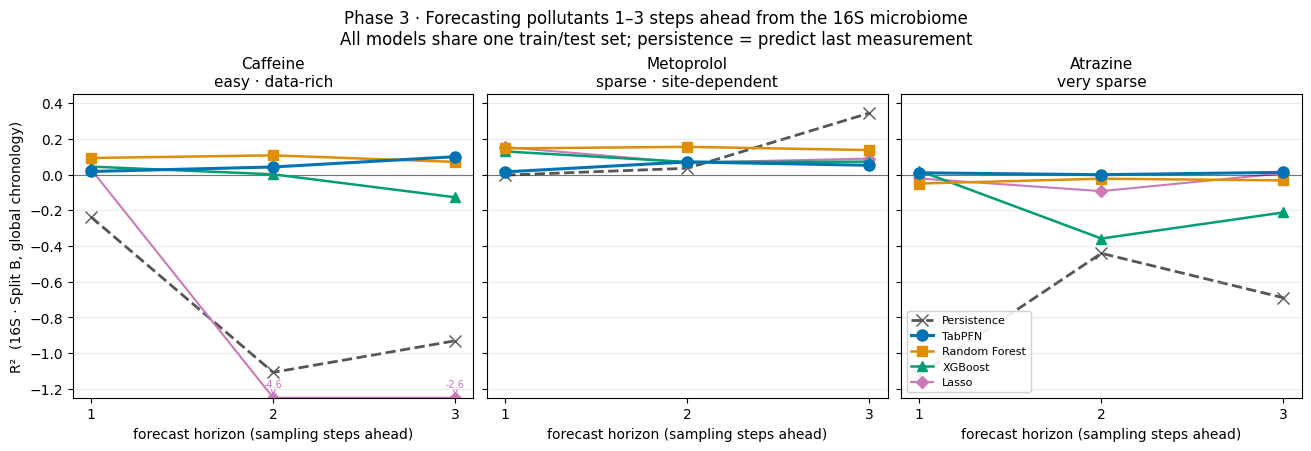

In [25]:
# ── CELL 5: forecasting figure — models vs persistence, 3 targets × 3 horizons ─
import numpy as np
import matplotlib.pyplot as plt

MODEL_STYLE = {   # colorblind-safe, distinct markers
    'tabpfn':        dict(color='#0173B2', marker='o', label='TabPFN',        lw=2.2, ms=8, z=5),
    'random_forest': dict(color='#DE8F05', marker='s', label='Random Forest', lw=1.8, ms=7, z=4),
    'xgboost':       dict(color='#029E73', marker='^', label='XGBoost',       lw=1.8, ms=7, z=3),
    'lasso':         dict(color='#CC78BC', marker='D', label='Lasso',         lw=1.5, ms=6, z=2),
}
GRADIENT   = ['Caffeine', 'Metoprolol', 'Atrazine']
SUBTITLE   = {'Caffeine': 'easy · data-rich',
              'Metoprolol': 'sparse · site-dependent',
              'Atrazine': 'very sparse'}
Y_LO, Y_HI = -1.25, 0.45          # readable clip; outliers annotated

fc = pd.read_csv(RESULTS / 'phase3_forecasting_shared_mask_splitB.csv')
fc16 = fc[fc.input == '16S']

fig, axes = plt.subplots(1, 3, figsize=(13, 4.4), sharey=True, constrained_layout=True)

for ax, tgt in zip(axes, GRADIENT):
    sub = fc16[fc16.target == tgt]

    # persistence baseline (one value per horizon) — grey reference band
    per = sub.groupby('horizon_k')['per_r2'].first().reindex(HORIZONS)
    ax.plot(HORIZONS, per.values, color='#555555', lw=2, ls='--',
            marker='x', ms=8, label='Persistence', zorder=1)

    # each model
    for m, st in MODEL_STYLE.items():
        r2 = sub[sub.model == m].set_index('horizon_k')['r2'].reindex(HORIZONS)
        clipped = r2.clip(lower=Y_LO)
        ax.plot(HORIZONS, clipped.values, color=st['color'], marker=st['marker'],
                lw=st['lw'], ms=st['ms'], label=st['label'], zorder=st['z'])
        # annotate any value that fell below the clip
        for h, v in zip(HORIZONS, r2.values):
            if np.isfinite(v) and v < Y_LO:
                ax.annotate(f'{v:.1f}', xy=(h, Y_LO), xytext=(h, Y_LO+0.06),
                            ha='center', fontsize=7, color=st['color'],
                            arrowprops=dict(arrowstyle='->', color=st['color'], lw=0.8))

    ax.axhline(0, color='black', lw=0.8, alpha=0.5)          # R²=0 reference
    ax.set_ylim(Y_LO, Y_HI)
    ax.set_xticks(HORIZONS)
    ax.set_xlabel('forecast horizon (sampling steps ahead)')
    ax.set_title(f'{tgt}\n{SUBTITLE[tgt]}', fontsize=11)
    ax.grid(axis='y', alpha=0.25)

axes[0].set_ylabel('R²  (16S · Split B, global chronology)')
axes[-1].legend(loc='lower left', fontsize=8, framealpha=0.9)

fig.suptitle('Phase 3 · Forecasting pollutants 1–3 steps ahead from the 16S microbiome\n'
             'All models share one train/test set; persistence = predict last measurement',
             fontsize=12)

out = RESULTS / 'phase3_forecasting_figure.png'
fig.savefig(out, dpi=150, bbox_inches='tight')
print(f'saved → {out}')
plt.show()

saved → /mnt/data/home/tv2414/tabpfn_project/results/phase3_forecasting_figure_shaded.png


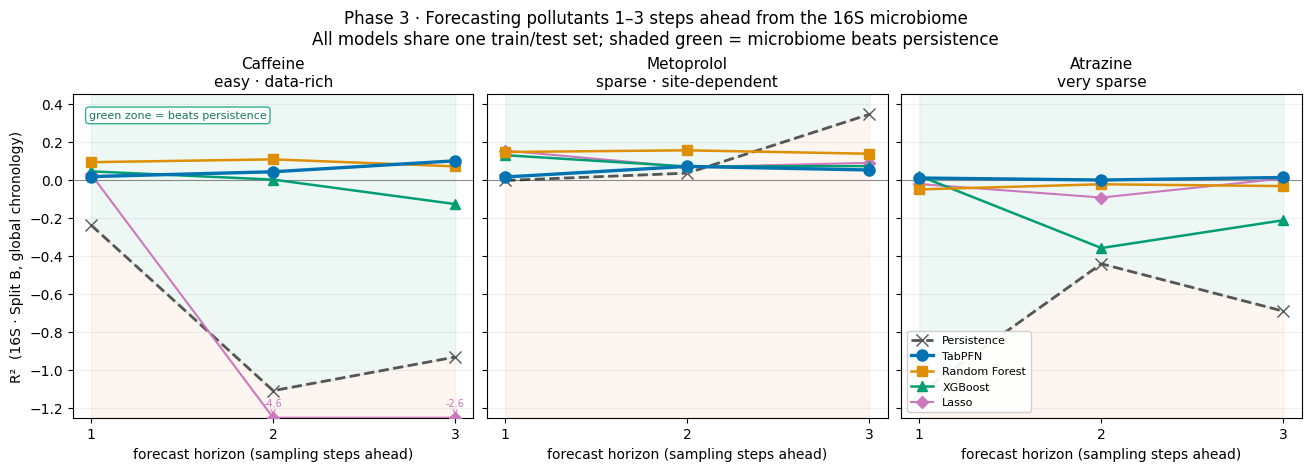

In [26]:
# ── CELL 5b: forecasting figure with persistence "win/lose" shading ─────────
import numpy as np
import matplotlib.pyplot as plt

MODEL_STYLE = {
    'tabpfn':        dict(color='#0173B2', marker='o', label='TabPFN',        lw=2.4, ms=8, z=6),
    'random_forest': dict(color='#DE8F05', marker='s', label='Random Forest', lw=1.8, ms=7, z=5),
    'xgboost':       dict(color='#029E73', marker='^', label='XGBoost',       lw=1.8, ms=7, z=4),
    'lasso':         dict(color='#CC78BC', marker='D', label='Lasso',         lw=1.5, ms=6, z=3),
}
GRADIENT = ['Caffeine', 'Metoprolol', 'Atrazine']
SUBTITLE = {'Caffeine': 'easy · data-rich',
            'Metoprolol': 'sparse · site-dependent',
            'Atrazine': 'very sparse'}
Y_LO, Y_HI = -1.25, 0.45

fc   = pd.read_csv(RESULTS / 'phase3_forecasting_shared_mask_splitB.csv')
fc16 = fc[fc.input == '16S']

# smooth x for shading between the discrete horizons
x_fine = np.linspace(min(HORIZONS), max(HORIZONS), 200)

fig, axes = plt.subplots(1, 3, figsize=(13, 4.6), sharey=True, constrained_layout=True)

for ax, tgt in zip(axes, GRADIENT):
    sub = fc16[fc16.target == tgt]
    per = sub.groupby('horizon_k')['per_r2'].first().reindex(HORIZONS)

    # interpolate the persistence line across the fine x grid
    per_fine = np.interp(x_fine, HORIZONS, per.values)

    # --- shading: above persistence = model "wins" (green), below = "loses" (red) ---
    ax.fill_between(x_fine, per_fine, Y_HI, color='#029E73', alpha=0.07, zorder=0)
    ax.fill_between(x_fine, Y_LO, per_fine, color='#D55E00', alpha=0.06, zorder=0)

    # persistence baseline line
    ax.plot(HORIZONS, per.values, color='#555555', lw=2, ls='--',
            marker='x', ms=8, label='Persistence', zorder=2)

    # models
    for m, st in MODEL_STYLE.items():
        r2 = sub[sub.model == m].set_index('horizon_k')['r2'].reindex(HORIZONS)
        ax.plot(HORIZONS, r2.clip(lower=Y_LO).values, color=st['color'],
                marker=st['marker'], lw=st['lw'], ms=st['ms'],
                label=st['label'], zorder=st['z'])
        for h, v in zip(HORIZONS, r2.values):
            if np.isfinite(v) and v < Y_LO:
                ax.annotate(f'{v:.1f}', xy=(h, Y_LO), xytext=(h, Y_LO+0.06),
                            ha='center', fontsize=7, color=st['color'],
                            arrowprops=dict(arrowstyle='->', color=st['color'], lw=0.8))

    ax.axhline(0, color='black', lw=0.8, alpha=0.4)
    ax.set_ylim(Y_LO, Y_HI); ax.set_xlim(min(HORIZONS)-0.1, max(HORIZONS)+0.1)
    ax.set_xticks(HORIZONS)
    ax.set_xlabel('forecast horizon (sampling steps ahead)')
    ax.set_title(f'{tgt}\n{SUBTITLE[tgt]}', fontsize=11)
    ax.grid(axis='y', alpha=0.2)

# "beats persistence" annotation on the first panel only
axes[0].text(0.04, 0.95, 'green zone = beats persistence',
             transform=axes[0].transAxes, fontsize=8, va='top', color='#1a7a5a',
             bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='#029E73', alpha=0.8))

axes[0].set_ylabel('R²  (16S · Split B, global chronology)')
axes[-1].legend(loc='lower left', fontsize=8, framealpha=0.92)

fig.suptitle('Phase 3 · Forecasting pollutants 1–3 steps ahead from the 16S microbiome\n'
             'All models share one train/test set; shaded green = microbiome beats persistence',
             fontsize=12)

out = RESULTS / 'phase3_forecasting_figure_shaded.png'
fig.savefig(out, dpi=150, bbox_inches='tight')
print(f'saved → {out}')
plt.show()

saved → /mnt/data/home/tv2414/tabpfn_project/results/phase3_forecasting_figure_3x3.png


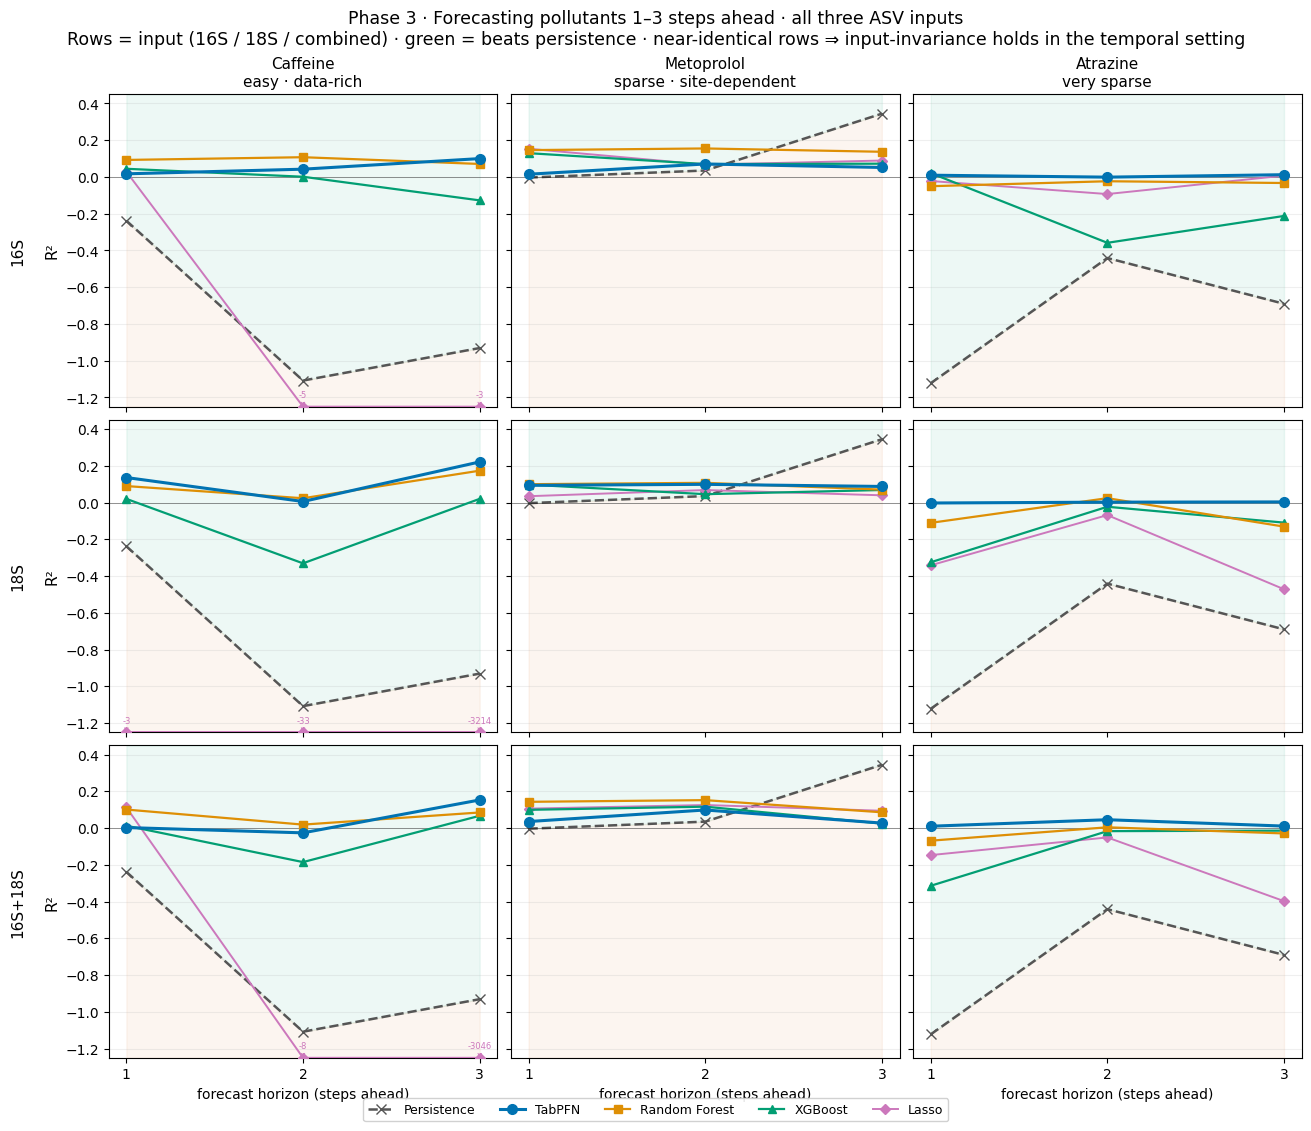

In [27]:
# ── CELL 5c: forecasting figure — 3 inputs × 3 targets grid ─────────────────
import numpy as np
import matplotlib.pyplot as plt

MODEL_STYLE = {
    'tabpfn':        dict(color='#0173B2', marker='o', label='TabPFN',        lw=2.2, ms=7, z=6),
    'random_forest': dict(color='#DE8F05', marker='s', label='Random Forest', lw=1.6, ms=6, z=5),
    'xgboost':       dict(color='#029E73', marker='^', label='XGBoost',       lw=1.6, ms=6, z=4),
    'lasso':         dict(color='#CC78BC', marker='D', label='Lasso',         lw=1.4, ms=5, z=3),
}
GRADIENT     = ['Caffeine', 'Metoprolol', 'Atrazine']
INPUT_ORDER  = ['16S', '18S', '16S+18S']
SUBTITLE     = {'Caffeine': 'easy · data-rich',
                'Metoprolol': 'sparse · site-dependent',
                'Atrazine': 'very sparse'}
Y_LO, Y_HI = -1.25, 0.45

fc     = pd.read_csv(RESULTS / 'phase3_forecasting_shared_mask_splitB.csv')
x_fine = np.linspace(min(HORIZONS), max(HORIZONS), 200)

fig, axes = plt.subplots(len(INPUT_ORDER), len(GRADIENT),
                         figsize=(13, 11), sharey=True, sharex=True,
                         constrained_layout=True)

for r, inp in enumerate(INPUT_ORDER):
    fci = fc[fc.input == inp]
    for c, tgt in enumerate(GRADIENT):
        ax  = axes[r, c]
        sub = fci[fci.target == tgt]
        per = sub.groupby('horizon_k')['per_r2'].first().reindex(HORIZONS)
        per_fine = np.interp(x_fine, HORIZONS, per.values)

        # win/lose shading relative to persistence
        ax.fill_between(x_fine, per_fine, Y_HI, color='#029E73', alpha=0.07, zorder=0)
        ax.fill_between(x_fine, Y_LO, per_fine, color='#D55E00', alpha=0.06, zorder=0)

        ax.plot(HORIZONS, per.values, color='#555555', lw=1.8, ls='--',
                marker='x', ms=7, label='Persistence', zorder=2)

        for m, st in MODEL_STYLE.items():
            r2 = sub[sub.model == m].set_index('horizon_k')['r2'].reindex(HORIZONS)
            ax.plot(HORIZONS, r2.clip(lower=Y_LO).values, color=st['color'],
                    marker=st['marker'], lw=st['lw'], ms=st['ms'],
                    label=st['label'], zorder=st['z'])
            for h, v in zip(HORIZONS, r2.values):
                if np.isfinite(v) and v < Y_LO:
                    ax.annotate(f'{v:.0f}', xy=(h, Y_LO), xytext=(h, Y_LO+0.05),
                                ha='center', fontsize=6, color=st['color'],
                                arrowprops=dict(arrowstyle='->', color=st['color'], lw=0.7))

        ax.axhline(0, color='black', lw=0.7, alpha=0.4)
        ax.set_ylim(Y_LO, Y_HI); ax.set_xlim(0.9, 3.1)
        ax.set_xticks(HORIZONS)
        ax.grid(axis='y', alpha=0.2)
        if r == 0:
            ax.set_title(f'{tgt}\n{SUBTITLE[tgt]}', fontsize=11)
        if r == len(INPUT_ORDER)-1:
            ax.set_xlabel('forecast horizon (steps ahead)')
        if c == 0:
            ax.set_ylabel(f'{inp}\n\nR²', fontsize=11, rotation=90)

# one shared legend
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=5, fontsize=9,
           bbox_to_anchor=(0.5, -0.02), framealpha=0.9)

fig.suptitle('Phase 3 · Forecasting pollutants 1–3 steps ahead · all three ASV inputs\n'
             'Rows = input (16S / 18S / combined) · green = beats persistence · '
             'near-identical rows ⇒ input-invariance holds in the temporal setting',
             fontsize=12.5)

out = RESULTS / 'phase3_forecasting_figure_3x3.png'
fig.savefig(out, dpi=150, bbox_inches='tight')
print(f'saved → {out}')
plt.show()

In [28]:
# ── check what's needed for the sensitivity analysis ────────────────────────
needed = ['versions', 'GRADIENT', 'INPUTS', 'meta', 'build_splits',
          'RANDOM_SEED', 'MODEL_PATH', 'RESULTS', 'thr', 'hplc_raw']
present = {n: (n in globals()) for n in needed}
for n, ok in present.items():
    print(f'  {"✓" if ok else "✗ MISSING"}  {n}')

missing = [n for n in needed if not present[n]]
if missing:
    print(f'\nMISSING: {missing}')
    print('→ need to re-run: Cell 0, Cell 1, and Cell 1b (the 3-mode censoring layer)')
else:
    print('\nAll present ✓ — ready for the sensitivity analysis')

  ✓  versions
  ✓  GRADIENT
  ✓  INPUTS
  ✓  meta
  ✓  build_splits
  ✓  RANDOM_SEED
  ✓  MODEL_PATH
  ✓  RESULTS
  ✓  thr
  ✓  hplc_raw

All present ✓ — ready for the sensitivity analysis


In [29]:
# ── CELL 6: censoring sensitivity analysis (TabPFN · 16S · 2 key strategies) ──
#   Re-run the difficulty gradient under all THREE censoring treatments and
#   show the qualitative conclusion (ordering, sign of R²) is unchanged.
#   Answers Theo's "think about something different for the full analysis".
import time
import numpy as np
import pandas as pd
from src.tabpfn_evaluator import run_tabpfn_with_splits

SENS_STRATEGIES = ['random_kfold', 'temporal_blocked_kfold']
SENS_INPUT      = '16S'
METHODS         = ['zero', 'half_lod', 'sqrt2_lod']

otu_16s = INPUTS[SENS_INPUT]
rows, t0 = [], time.time()

print(f'Censoring sensitivity · TabPFN · {SENS_INPUT} · '
      f'{len(GRADIENT)}×{len(METHODS)}×{len(SENS_STRATEGIES)} = '
      f'{len(GRADIENT)*len(METHODS)*len(SENS_STRATEGIES)} cells')
print('=' * 74)

for method in METHODS:
    # attach this censoring version's targets onto a working copy of meta
    meta_m = meta.copy()
    for c in GRADIENT:
        meta_m[c] = versions[method][c].values

    for c in GRADIENT:
        for strat in SENS_STRATEGIES:
            mask   = meta_m[c].notna()
            meta_v = meta_m.loc[mask].reset_index(drop=True)
            otu_v  = otu_16s.loc[mask].reset_index(drop=True)
            splits = build_splits(strat, meta_v, RANDOM_SEED)

            res = run_tabpfn_with_splits(
                target_name=c, meta=meta_v, otu=otu_v, splits=splits,
                strategy_name=strat, input_name=SENS_INPUT,
                log_target=False, random_seed=RANDOM_SEED,
                model_path=MODEL_PATH, verbose=False,
            )
            rows.append({'method': method, 'target': c, 'strategy': strat,
                         'r2': res['r2_mean'], 'mae': res['mae_mean']})
            print(f'  {method:<10s} {c:<11s} {strat:<22s} R²={res["r2_mean"]:+.4f}')
    print()

sens = pd.DataFrame(rows)
sens.to_csv(RESULTS / 'phase3_censoring_sensitivity.csv', index=False)
print(f'DONE · {(time.time()-t0):.1f}s → phase3_censoring_sensitivity.csv')

# ---- verdict tables: does the ordering / sign hold across methods? ----
for strat in SENS_STRATEGIES:
    print(f'\n=== R² across censoring methods · {strat} ===')
    piv = (sens[sens.strategy==strat]
           .pivot(index='target', columns='method', values='r2')
           .reindex(index=GRADIENT, columns=METHODS))
    print(piv.round(4).to_string())
    # check gradient ordering preserved in each column
    print('  gradient (Caffeine>Metoprolol>Atrazine) preserved:',
          all(piv.loc['Caffeine',m] > piv.loc['Metoprolol',m] > piv.loc['Atrazine',m]
              for m in METHODS))

Censoring sensitivity · TabPFN · 16S · 3×3×2 = 18 cells
  zero       Caffeine    random_kfold           R²=+0.6887
  zero       Caffeine    temporal_blocked_kfold R²=+0.3416
  zero       Metoprolol  random_kfold           R²=+0.5434
  zero       Metoprolol  temporal_blocked_kfold R²=+0.1051
  zero       Atrazine    random_kfold           R²=+0.1497
  zero       Atrazine    temporal_blocked_kfold R²=-0.0412

  half_lod   Caffeine    random_kfold           R²=+0.6887
  half_lod   Caffeine    temporal_blocked_kfold R²=+0.3416
  half_lod   Metoprolol  random_kfold           R²=+0.5374
  half_lod   Metoprolol  temporal_blocked_kfold R²=+0.1221
  half_lod   Atrazine    random_kfold           R²=+0.3374
  half_lod   Atrazine    temporal_blocked_kfold R²=-0.0230

  sqrt2_lod  Caffeine    random_kfold           R²=+0.6887
  sqrt2_lod  Caffeine    temporal_blocked_kfold R²=+0.3416
  sqrt2_lod  Metoprolol  random_kfold           R²=+0.5321
  sqrt2_lod  Metoprolol  temporal_blocked_kfold R²=+0.110

saved → /mnt/data/home/tv2414/tabpfn_project/results/phase3_metoprolol_persite_figure.png

regime counts: {'contaminated': 9, 'clean': 4, 'outlier': 1}


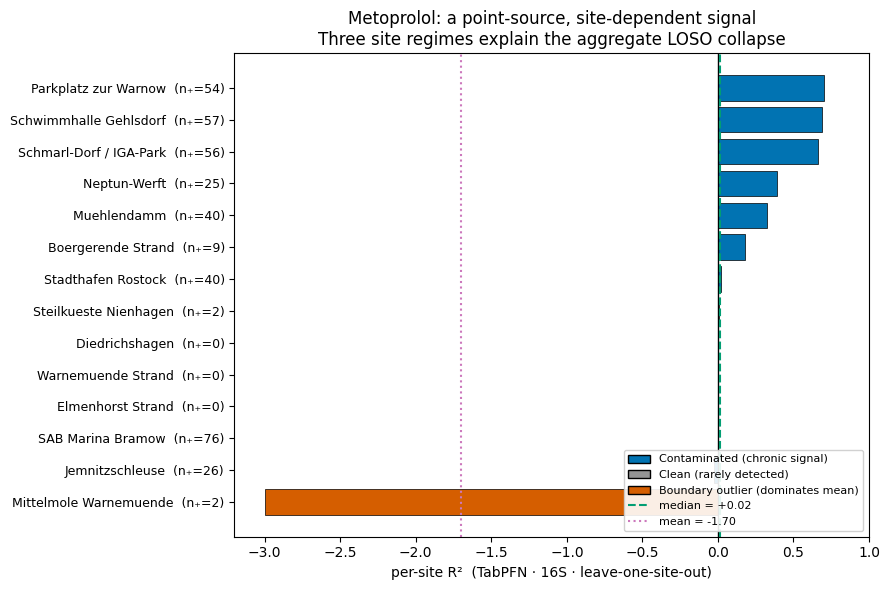

In [30]:
# ── CELL 7: Metoprolol per-site LOSO figure (three site regimes) ────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

CSV = RESULTS / 'phase3_metoprolol_loso_persite.csv'

# recompute if the CSV isn't on disk (kernel may have been restarted earlier)
if not CSV.exists():
    from sklearn.metrics import r2_score
    from src.tabpfn_evaluator import _make_tabpfn
    meta_m = meta.copy()
    meta_m['Metoprolol'] = versions['zero']['Metoprolol'].values
    mask   = meta_m['Metoprolol'].notna()
    meta_v = meta_m.loc[mask].reset_index(drop=True)
    otu_v  = INPUTS['16S'].loc[mask].reset_index(drop=True)
    X, y   = otu_v.values, meta_v['Metoprolol'].values
    splits = build_splits('leave_one_site_out', meta_v, RANDOM_SEED)
    sites  = sorted(meta_v['location_name'].unique())
    recs = []
    for (tr, te), site in zip(splits, sites):
        reg = _make_tabpfn(RANDOM_SEED, model_path=MODEL_PATH)
        reg.fit(X[tr], y[tr]); yh = reg.predict(X[te])
        recs.append(dict(site=site, n=len(te), r2=r2_score(y[te], yh),
                         n_pos=int((y[te] > 0).sum())))
    met = pd.DataFrame(recs).sort_values('r2')
    met.to_csv(CSV, index=False)
else:
    met = pd.read_csv(CSV).sort_values('r2')

# ---- classify sites into three regimes ----
def regime(row):
    if row['r2'] < -1:              return 'outlier'      # dominant bad fold
    if row['n_pos'] <= 2:          return 'clean'         # never/barely detected
    return 'contaminated'                                  # chronic signal
met['regime'] = met.apply(regime, axis=1)

REG_COLOR = {'contaminated': '#0173B2', 'clean': '#949494', 'outlier': '#D55E00'}
REG_LABEL = {'contaminated': 'Contaminated (chronic signal)',
             'clean': 'Clean (rarely detected)',
             'outlier': 'Boundary outlier (dominates mean)'}

fig, ax = plt.subplots(figsize=(9, 6))
# clip the extreme outlier for readability, annotate raw
CLIP = -3.0
r2_plot = met['r2'].clip(lower=CLIP)
colors  = met['regime'].map(REG_COLOR)

bars = ax.barh(range(len(met)), r2_plot, color=colors, edgecolor='black', lw=0.5)
ax.set_yticks(range(len(met)))
ax.set_yticklabels([f'{s}  (n₊={int(n)})' for s, n in zip(met['site'], met['n_pos'])],
                   fontsize=9)
ax.axvline(0, color='black', lw=1)

# annotate the clipped outlier with its true value
for i, (r2, rp) in enumerate(zip(met['r2'], r2_plot)):
    if r2 < CLIP:
        ax.annotate(f'R²={r2:.1f}', xy=(CLIP, i), xytext=(CLIP+0.15, i),
                    va='center', fontsize=8, color='#D55E00',
                    arrowprops=dict(arrowstyle='->', color='#D55E00', lw=0.8))

# reference lines: mean vs median
mean_r2, median_r2 = met['r2'].mean(), met['r2'].median()
ax.axvline(median_r2, color='#029E73', ls='--', lw=1.5,
           label=f'median = {median_r2:+.2f}  (robust summary)')
ax.axvline(mean_r2, color='#CC78BC', ls=':', lw=1.5,
           label=f'mean = {mean_r2:+.2f}  (outlier-driven)')

# legend for regimes
from matplotlib.patches import Patch
handles = [Patch(facecolor=REG_COLOR[k], edgecolor='black', label=REG_LABEL[k])
           for k in ['contaminated', 'clean', 'outlier']]
handles += [plt.Line2D([0],[0], color='#029E73', ls='--', label=f'median = {median_r2:+.2f}'),
            plt.Line2D([0],[0], color='#CC78BC', ls=':',  label=f'mean = {mean_r2:+.2f}')]
ax.legend(handles=handles, loc='lower right', fontsize=8, framealpha=0.9)

ax.set_xlabel('per-site R²  (TabPFN · 16S · leave-one-site-out)')
ax.set_title('Metoprolol: a point-source, site-dependent signal\n'
             'Three site regimes explain the aggregate LOSO collapse',
             fontsize=12)
ax.set_xlim(CLIP-0.2, 1.0)
plt.tight_layout()

out = RESULTS / 'phase3_metoprolol_persite_figure.png'
fig.savefig(out, dpi=150, bbox_inches='tight')
print(f'saved → {out}')
print(f'\nregime counts: {met.regime.value_counts().to_dict()}')
plt.show()

In [31]:
# ── CELL 8: difficulty-gradient table (target selection justification) ──────
import pandas as pd
import numpy as np

# recompute detection/quantification frequency from the raw HPLC file
def _freq(compound):
    col = hplc_raw[compound].dropna().astype(str).str.strip()
    n_total = len(hplc_raw)
    n_quant = sum(1 for v in col if not v.startswith(('<', '#')) and v != '')
    n_detect = sum(1 for v in col if v.startswith('#') or
                   (not v.startswith('<') and v != '' and not v.startswith('#')))
    q = [float(v) for v in col if not v.startswith(('<','#')) and v != '']
    return dict(
        detect_pct=round(100*n_detect/n_total, 1),
        quant_pct=round(100*n_quant/n_total, 1),
        n_quant=n_quant,
        median_ngL=round(np.median(q), 1) if q else np.nan,
    )

# cross-sectional R² and Spearman from our results (16S, random_kfold)
tab = pd.read_csv(RESULTS / 'phase3_tabpfn_3targets_3inputs_4strategies.csv')

DIFFICULTY = {'Caffeine': 'easy · data-rich',
              'Metoprolol': 'sparse · site-dependent',
              'Atrazine': 'very sparse · challenging'}
SPEARMAN = {'Caffeine': 0.88, 'Metoprolol': 0.71, 'Atrazine': 0.29}  # from focus analysis

rows = []
for c in GRADIENT:
    f = _freq(c)
    r2_rand = tab[(tab['target_display']==c) & (tab['input']=='16S') &
                  (tab['strategy']=='random_kfold')]['r2_mean'].iloc[0]
    rows.append({
        'Compound': c,
        'Difficulty level': DIFFICULTY[c],
        'Detection %': f['detect_pct'],
        'Quantified %': f['quant_pct'],
        'Median (ng/L)': f['median_ngL'],
        'R² (random, 16S)': round(r2_rand, 3),
        'Spearman ρ': SPEARMAN[c],
    })

diff_table = pd.DataFrame(rows)
diff_table.to_csv(RESULTS / 'phase3_difficulty_gradient_table.csv', index=False)

print('=== DIFFICULTY GRADIENT TABLE (Phase 3 target selection) ===\n')
print(diff_table.to_string(index=False))
print(f'\nsaved → phase3_difficulty_gradient_table.csv')

=== DIFFICULTY GRADIENT TABLE (Phase 3 target selection) ===

  Compound          Difficulty level  Detection %  Quantified %  Median (ng/L)  R² (random, 16S)  Spearman ρ
  Caffeine          easy · data-rich         90.7          90.7           24.8             0.689        0.88
Metoprolol   sparse · site-dependent         43.5          27.3           43.3             0.543        0.71
  Atrazine very sparse · challenging         28.9           4.0            3.6             0.150        0.29

saved → phase3_difficulty_gradient_table.csv


saved → phase3_table1_difficulty.png


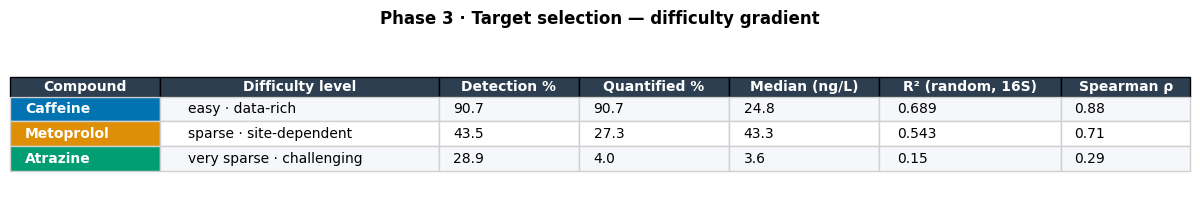

In [34]:
# ── CELL 10: render both tables as publication-quality figures ──────────────
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# reload the saved tables
diff_table   = pd.read_csv(RESULTS / 'phase3_difficulty_gradient_table.csv')
signal_table = pd.read_csv(RESULTS / 'phase3_signal_type_summary.csv')

# colorblind-safe accent per compound (consistent across all Phase 3 visuals)
COMPOUND_COLOR = {'Caffeine': '#0173B2', 'Metoprolol': '#DE8F05', 'Atrazine': '#029E73'}

def styled_table(df, title, col_widths, out_name, fontsize=11,
                 first_col_bold=True, figsize=None):
    n_rows, n_cols = df.shape
    if figsize is None:
        figsize = (sum(col_widths) * 1.1, 0.6 + 0.55 * n_rows)
    fig, ax = plt.subplots(figsize=figsize)
    ax.axis('off')

    tbl = ax.table(cellText=df.values, colLabels=df.columns,
                   cellLoc='left', loc='center',
                   colWidths=[w/sum(col_widths) for w in col_widths])
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(fontsize)
    tbl.scale(1, 1.6)

    # header styling
    for j in range(n_cols):
        c = tbl[0, j]
        c.set_facecolor('#2C3E50')
        c.set_text_props(color='white', fontweight='bold')
        c.set_height(0.12)

    # body styling: tint first column by compound, zebra rows
    for i in range(1, n_rows + 1):
        compound = df.iloc[i-1, 0]
        for j in range(n_cols):
            cell = tbl[i, j]
            if j == 0:
                cell.set_facecolor(COMPOUND_COLOR.get(compound, '#EEEEEE'))
                cell.set_text_props(color='white',
                                    fontweight='bold' if first_col_bold else 'normal')
            else:
                cell.set_facecolor('#F5F7FA' if i % 2 else '#FFFFFF')
            cell.set_edgecolor('#D0D0D0')

    ax.set_title(title, fontsize=fontsize+2, fontweight='bold', pad=14)
    plt.tight_layout()
    out = RESULTS / out_name
    fig.savefig(out, dpi=200, bbox_inches='tight', facecolor='white')
    print(f'saved → {out.name}')
    plt.show()

# ---- Table 1: difficulty gradient (compact, numeric) ----
styled_table(
    diff_table,
    'Phase 3 · Target selection — difficulty gradient',
    col_widths=[1.4, 2.6, 1.3, 1.4, 1.4, 1.7, 1.2],
    out_name='phase3_table1_difficulty.png',
    fontsize=10,
)

In [32]:
# ── CELL 9: signal-type summary table (the conceptual core of Phase 3) ──────
import pandas as pd

signal_table = pd.DataFrame([
    {
        'Compound': 'Caffeine',
        'Signal type': 'Strong · transferable',
        'Source': 'Human wastewater (ubiquitous)',
        'Cross-sectional': 'R²=0.69, ρ=0.88; stable under LOSO',
        'Spatial (LOSO)': 'Transfers across sites',
        'Temporal (forecast)': 'Beats persistence at all horizons',
        'Key evidence': 'High R² AND high ρ everywhere',
    },
    {
        'Compound': 'Metoprolol',
        'Signal type': 'Point-source · site-dependent',
        'Source': 'Localised wastewater discharge',
        'Cross-sectional': 'R²=0.54 (random); collapses under LOSO',
        'Spatial (LOSO)': 'mean=-1.70 vs median=+0.02; 3 site regimes',
        'Temporal (forecast)': 'Persistence wins at long horizon (chronic)',
        'Key evidence': 'Between-site >> within-site variation',
    },
    {
        'Compound': 'Atrazine',
        'Signal type': 'Weak · significant · transferable',
        'Source': 'Diffuse agricultural runoff',
        'Cross-sectional': 'R²≈0.15 (fails); ρ=0.29 (p≈1e-27)',
        'Spatial (LOSO)': 'ρ stable: 0.29 (random) ≈ 0.30 (LOSO)',
        'Temporal (forecast)': 'Beats persistence but R² near zero',
        'Key evidence': 'Rank signal survives where regression fails',
    },
])

signal_table.to_csv(RESULTS / 'phase3_signal_type_summary.csv', index=False)

print('=== SIGNAL-TYPE SUMMARY (Phase 3 conceptual core) ===\n')
# print transposed for readability (compounds as columns)
for _, row in signal_table.iterrows():
    print(f"── {row['Compound']} — {row['Signal type']} ──")
    print(f"   Source        : {row['Source']}")
    print(f"   Cross-section : {row['Cross-sectional']}")
    print(f"   Spatial       : {row['Spatial (LOSO)']}")
    print(f"   Temporal      : {row['Temporal (forecast)']}")
    print(f"   Key evidence  : {row['Key evidence']}")
    print()
print('saved → phase3_signal_type_summary.csv')

=== SIGNAL-TYPE SUMMARY (Phase 3 conceptual core) ===

── Caffeine — Strong · transferable ──
   Source        : Human wastewater (ubiquitous)
   Cross-section : R²=0.69, ρ=0.88; stable under LOSO
   Spatial       : Transfers across sites
   Temporal      : Beats persistence at all horizons
   Key evidence  : High R² AND high ρ everywhere

── Metoprolol — Point-source · site-dependent ──
   Source        : Localised wastewater discharge
   Cross-section : R²=0.54 (random); collapses under LOSO
   Spatial       : mean=-1.70 vs median=+0.02; 3 site regimes
   Temporal      : Persistence wins at long horizon (chronic)
   Key evidence  : Between-site >> within-site variation

── Atrazine — Weak · significant · transferable ──
   Source        : Diffuse agricultural runoff
   Cross-section : R²≈0.15 (fails); ρ=0.29 (p≈1e-27)
   Spatial       : ρ stable: 0.29 (random) ≈ 0.30 (LOSO)
   Temporal      : Beats persistence but R² near zero
   Key evidence  : Rank signal survives where regression 

saved → phase3_table2_signal_types.png


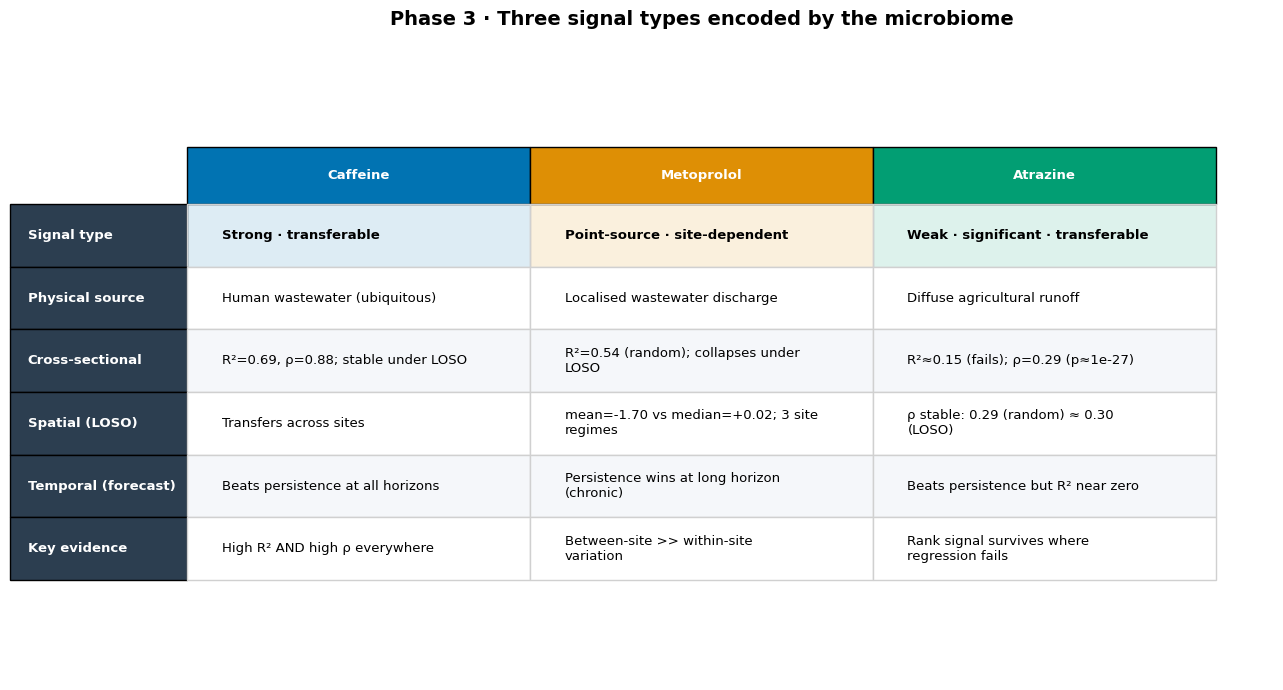

In [35]:
# ── CELL 11: signal-type summary as a transposed styled table ───────────────
import matplotlib.pyplot as plt
import pandas as pd
import textwrap

signal_table = pd.read_csv(RESULTS / 'phase3_signal_type_summary.csv')

COMPOUND_COLOR = {'Caffeine': '#0173B2', 'Metoprolol': '#DE8F05', 'Atrazine': '#029E73'}

# transpose: rows = dimensions, columns = compounds
dims = ['Signal type', 'Source', 'Cross-sectional', 'Spatial (LOSO)',
        'Temporal (forecast)', 'Key evidence']
ROW_LABEL = {
    'Signal type':          'Signal type',
    'Source':               'Physical source',
    'Cross-sectional':      'Cross-sectional',
    'Spatial (LOSO)':       'Spatial (LOSO)',
    'Temporal (forecast)':  'Temporal (forecast)',
    'Key evidence':         'Key evidence',
}
compounds = ['Caffeine', 'Metoprolol', 'Atrazine']
sig = signal_table.set_index('Compound')

def wrap(txt, w=34):
    return '\n'.join(textwrap.wrap(str(txt), w))

cell_text = []
for d in dims:
    cell_text.append([wrap(sig.loc[c, d]) for c in compounds])

fig, ax = plt.subplots(figsize=(13, 7))
ax.axis('off')

tbl = ax.table(cellText=cell_text,
               rowLabels=[ROW_LABEL[d] for d in dims],
               colLabels=compounds,
               cellLoc='left', loc='center',
               colWidths=[0.30, 0.30, 0.30])
tbl.auto_set_font_size(False)
tbl.set_fontsize(9.5)
tbl.scale(1, 3.2)

n_dims = len(dims)

# column headers (compounds) — colored per compound
for j, c in enumerate(compounds):
    cell = tbl[0, j]
    cell.set_facecolor(COMPOUND_COLOR[c])
    cell.set_text_props(color='white', fontweight='bold', ha='center')
    cell.set_height(0.09)

# row labels — dark, bold
for i in range(1, n_dims + 1):
    cell = tbl[i, -1]
    cell.set_facecolor('#2C3E50')
    cell.set_text_props(color='white', fontweight='bold')

# body — zebra + light tint of the compound color on the "Signal type" row
for i in range(1, n_dims + 1):
    for j in range(len(compounds)):
        cell = tbl[i, j]
        if i == 1:  # "Signal type" row — light compound tint
            cell.set_facecolor(COMPOUND_COLOR[compounds[j]] + '22')
            cell.set_text_props(fontweight='bold')
        else:
            cell.set_facecolor('#F5F7FA' if i % 2 else '#FFFFFF')
        cell.set_edgecolor('#D0D0D0')
        cell.set_text_props(va='center')

ax.set_title('Phase 3 · Three signal types encoded by the microbiome',
             fontsize=14, fontweight='bold', pad=16)
plt.tight_layout()

out = RESULTS / 'phase3_table2_signal_types.png'
fig.savefig(out, dpi=200, bbox_inches='tight', facecolor='white')
print(f'saved → {out.name}')
plt.show()

In [6]:
# Cell 1 — locate and inspect all Phase 3 result CSVs
from pathlib import Path
import pandas as pd

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 50)

ROOT = Path.home() / "tabpfn_project"
files = sorted(ROOT.rglob("phase3_*.csv"))

print(f"Project root : {ROOT}")
print(f"Found {len(files)} Phase 3 CSV file(s)\n")

phase3 = {}
for f in files:
    df = pd.read_csv(f)
    phase3[f.stem] = df
    print("=" * 90)
    print(f"{f.stem}")
    print(f"  path    : {f.relative_to(ROOT)}")
    print(f"  shape   : {df.shape[0]} rows x {df.shape[1]} cols")
    print(f"  columns : {list(df.columns)}")
    # show which categorical columns exist and their unique values (short ones only)
    for c in df.columns:
        if df[c].dtype == object and df[c].nunique() <= 12:
            print(f"    {c:<22} -> {sorted(df[c].dropna().unique().tolist())}")
    print(df.head(3).to_string(index=False))
    print()

print("=" * 90)
print("Loaded into dict `phase3` with keys:")
for k in phase3:
    print(f"  {k}")

Project root : /mnt/data/home/tv2414/tabpfn_project
Found 15 Phase 3 CSV file(s)

phase3_censoring_sensitivity
  path    : results/phase3_censoring_sensitivity.csv
  shape   : 18 rows x 5 cols
  columns : ['method', 'target', 'strategy', 'r2', 'mae']
method     target               strategy       r2       mae
  zero   Caffeine           random_kfold 0.688654 10.580761
  zero   Caffeine temporal_blocked_kfold 0.341560 17.339595
  zero Metoprolol           random_kfold 0.543369 11.703315

phase3_difficulty_gradient_table
  path    : results/phase3_difficulty_gradient_table.csv
  shape   : 3 rows x 7 cols
  columns : ['Compound', 'Difficulty level', 'Detection %', 'Quantified %', 'Median (ng/L)', 'R² (random, 16S)', 'Spearman ρ']
  Compound          Difficulty level  Detection %  Quantified %  Median (ng/L)  R² (random, 16S)  Spearman ρ
  Caffeine          easy · data-rich         90.7          90.7           24.8             0.689        0.88
Metoprolol   sparse · site-dependent         

In [4]:
# Cell 2 — normalise columns and build the complete forecasting table (108 runs + persistence)
import numpy as np
import pandas as pd

KEY = "phase3_forecasting_shared_mask_splitB"
assert KEY in phase3, f"{KEY} not in phase3 dict. Available: {list(phase3)}"
raw = phase3[KEY].copy()

CANDIDATES = {
    "model":    ["model", "model_name", "estimator", "method"],
    "input":    ["input", "input_type", "input_config", "feature_set", "features", "omic"],
    "target":   ["target", "pollutant", "compound", "target_name", "substance"],
    "horizon":  ["horizon", "k", "horizon_k", "step", "steps_ahead", "h"],
    "r2":       ["r2", "R2", "r2_score", "test_r2", "r2_test"],
    "mae":      ["mae", "MAE", "test_mae"],
    "rmse":     ["rmse", "RMSE", "test_rmse"],
    "spearman": ["spearman", "spearman_rho", "rho", "spearman_r", "spearman_corr"],
    "n_test":   ["n_test", "n_test_shared", "test_n", "n_shared", "n"],
    "pers_r2":  ["persistence_r2", "pers_r2", "persistence_R2", "baseline_r2"],
}

lower = {c.lower(): c for c in raw.columns}
colmap, missing = {}, []
for canon, opts in CANDIDATES.items():
    hit = next((lower[o.lower()] for o in opts if o.lower() in lower), None)
    if hit:
        colmap[canon] = hit
    else:
        missing.append(canon)

print("Resolved columns:")
for k, v in colmap.items():
    print(f"  {k:<10} <- '{v}'")
if missing:
    print(f"\n!! Not found: {missing}")
    print("   Actual columns:", list(raw.columns))

REQUIRED = ["model", "target", "horizon", "r2"]
assert not [c for c in REQUIRED if c in missing], \
    f"Cannot continue, missing essential column(s). Paste the column list above and I'll adjust."

df = raw.rename(columns={v: k for k, v in colmap.items()})
if "input" in missing:
    df["input"] = "16S"          # single-input file
    print("\nNote: no input column found -> assuming a single input configuration.")

# --- tidy up label values -----------------------------------------------------
df["horizon"] = (df["horizon"].astype(str)
                 .str.extract(r"(\d+)")[0].astype(int))

def tidy_model(x):
    s = str(x).strip().lower().replace("-", "_").replace(" ", "_")
    return {"tabpfn": "TabPFN", "rf": "Random Forest", "random_forest": "Random Forest",
            "randomforest": "Random Forest", "xgb": "XGBoost", "xgboost": "XGBoost",
            "lasso": "Lasso", "persistence": "Persistence", "naive": "Persistence",
            }.get(s, str(x).strip())

def tidy_input(x):
    s = str(x).strip().lower().replace("+", "_").replace(" ", "")
    return {"16s": "16S", "18s": "18S", "16s_18s": "16S+18S", "combined": "16S+18S",
            "both": "16S+18S", "16s18s": "16S+18S"}.get(s, str(x).strip())

df["model"] = df["model"].map(tidy_model)
df["input"] = df["input"].map(tidy_input)
df["target"] = df["target"].map(lambda x: str(x).strip().capitalize())

# --- separate persistence from the model runs --------------------------------
is_pers = df["model"].eq("Persistence")
runs = df.loc[~is_pers].copy()

if is_pers.any():
    pers = (df.loc[is_pers, ["target", "horizon", "r2"]]
              .groupby(["target", "horizon"], as_index=False)["r2"].mean()
              .rename(columns={"r2": "persistence_r2"}))
    print(f"\nPersistence taken from {is_pers.sum()} dedicated row(s).")
elif "pers_r2" in colmap:
    pers = (runs.groupby(["target", "horizon"], as_index=False)["pers_r2"]
                .mean().rename(columns={"pers_r2": "persistence_r2"}))
    print("\nPersistence taken from the per-row persistence column.")
else:
    pers = None
    print("\n!! No persistence values found — delta_r2 will be skipped.")

full = runs.copy()
if pers is not None:
    full = full.merge(pers, on=["target", "horizon"], how="left")
    full["delta_r2"] = full["r2"] - full["persistence_r2"]

# --- order, round, report -----------------------------------------------------
T_ORDER = ["Caffeine", "Metoprolol", "Atrazine"]
M_ORDER = ["TabPFN", "Random Forest", "XGBoost", "Lasso"]
I_ORDER = ["16S", "18S", "16S+18S"]
full["target"] = pd.Categorical(full["target"], [t for t in T_ORDER if t in set(full["target"])], ordered=True)
full["model"] = pd.Categorical(full["model"], [m for m in M_ORDER if m in set(full["model"])], ordered=True)
full["input"] = pd.Categorical(full["input"], [i for i in I_ORDER if i in set(full["input"])], ordered=True)

keep = [c for c in ["target", "horizon", "input", "model", "n_test",
                    "r2", "mae", "rmse", "spearman", "persistence_r2", "delta_r2"] if c in full.columns]
full = full[keep].sort_values(["target", "horizon", "input", "model"]).reset_index(drop=True)

num = full.select_dtypes(include=[np.number]).columns
full[num] = full[num].round(4)

print(f"\nFinal table: {full.shape[0]} model runs "
      f"({full['model'].nunique()} models x {full['input'].nunique()} inputs "
      f"x {full['target'].nunique()} targets x {full['horizon'].nunique()} horizons)")
print("Expected 108 if the grid is complete.")
if full.shape[0] != 108:
    print("!! Row count is not 108 — check for missing or duplicated cells:")
    print(full.groupby(["target", "horizon"], observed=True).size().to_string())

RESULTS = ROOT / "results"
RESULTS.mkdir(exist_ok=True)
out = RESULTS / "phase3_forecasting_full_table.csv"
full.to_csv(out, index=False)
print(f"\nSaved -> {out}")

display(full.head(12))

Resolved columns:
  model      <- 'model'
  input      <- 'input'
  target     <- 'target'
  horizon    <- 'horizon_k'
  r2         <- 'r2'
  mae        <- 'mae'
  rmse       <- 'rmse'
  n_test     <- 'n_test'

!! Not found: ['spearman', 'pers_r2']
   Actual columns: ['model', 'target', 'input', 'horizon_k', 'n_train', 'n_test', 'r2', 'mae', 'rmse', 'per_r2', 'per_mae', 'delta_r2', 'total_time']

!! No persistence values found — delta_r2 will be skipped.

Final table: 108 model runs (4 models x 3 inputs x 3 targets x 3 horizons)
Expected 108 if the grid is complete.

Saved -> /mnt/data/home/tv2414/tabpfn_project/results/phase3_forecasting_full_table.csv


,target,horizon,input,model,n_test,r2,mae,rmse,delta_r2
0,Caffeine,1,16S,TabPFN,282,0.0171,14.4014,18.8924,0.2551
1,Caffeine,1,16S,Random Forest,282,0.0927,14.1121,18.1514,0.3307
2,Caffeine,1,16S,XGBoost,282,0.0446,14.3396,18.6266,0.2826
3,Caffeine,1,16S,Lasso,282,0.0289,15.2765,18.7794,0.2669
4,Caffeine,1,18S,TabPFN,282,0.1361,12.3774,17.7121,0.3741
5,Caffeine,1,18S,Random Forest,282,0.0897,13.4604,18.1822,0.3276
6,Caffeine,1,18S,XGBoost,282,0.0200,13.0465,18.8653,0.2580
7,Caffeine,1,18S,Lasso,282,-2.5506,22.6191,35.9084,-2.3126
8,Caffeine,1,16S+18S,TabPFN,282,0.0030,14.3107,19.0274,0.2410
9,Caffeine,1,16S+18S,Random Forest,282,0.1010,13.6946,18.0682,0.3390


In [10]:
# Cell 2b — sort, round, summarise, save  (continues from Cell 2's `df`)
cols = ["target", "horizon", "input", "model", "n_train", "n_test",
        "r2", "mae", "rmse", "persistence_r2", "persistence_mae",
        "delta_r2", "beats_persistence", "rank_in_cell", "seconds"]

full = (df[cols]
        .sort_values(["target", "horizon", "input", "model"])   # no observed= here
        .reset_index(drop=True))

num = full.select_dtypes(include=[np.number]).columns
full[num] = full[num].round(4)

print("SHARED TEST-SET SIZES (the number to quote in the meeting)")
print("-" * 62)
print(full.groupby(["target", "horizon"], observed=True)[
          ["n_train", "n_test", "persistence_r2"]].first().to_string())

print("\nHOW OFTEN EACH MODEL BEATS PERSISTENCE (27 runs each)")
print("-" * 62)
print(full.groupby("model", observed=True)
          .agg(wins=("beats_persistence", "sum"),
               mean_r2=("r2", "mean"),
               worst_r2=("r2", "min"),
               best_r2=("r2", "max"),
               median_seconds=("seconds", "median")).round(3).to_string())

print("\nBEST MODEL PER TARGET x HORIZON")
print("-" * 62)
best = (full[full["rank_in_cell"] == 1]
        [["target", "horizon", "model", "input", "r2", "persistence_r2", "delta_r2"]]
        .sort_values(["target", "horizon"]))
print(best.to_string(index=False))

out = ROOT / "results" / "phase3_forecasting_full_table.csv"
full.to_csv(out, index=False)
print(f"\nSaved -> {out}   ({len(full)} rows)")

display(full.head(12))

SHARED TEST-SET SIZES (the number to quote in the meeting)
--------------------------------------------------------------
                    n_train  n_test  persistence_r2
target     horizon                                 
Caffeine   1            939     282         -0.2380
           2            916     264         -1.1079
           3            894     230         -0.9309
Metoprolol 1            939     286         -0.0032
           2            916     266          0.0352
           3            894     232          0.3444
Atrazine   1            937     282         -1.1225
           2            914     264         -0.4411
           3            892     230         -0.6901

HOW OFTEN EACH MODEL BEATS PERSISTENCE (27 runs each)
--------------------------------------------------------------
               wins  mean_r2  worst_r2  best_r2  median_seconds
model                                                          
TabPFN           24    0.049    -0.026    0.221           2.

,target,horizon,input,model,n_train,n_test,r2,mae,rmse,persistence_r2,persistence_mae,delta_r2,beats_persistence,rank_in_cell,seconds
0,Caffeine,1,16S,TabPFN,939,282,0.0171,14.4014,18.8924,-0.238,13.2333,0.2551,True,9,2.3057
1,Caffeine,1,16S,Random Forest,939,282,0.0927,14.1121,18.1514,-0.238,13.2333,0.3307,True,4,233.5282
2,Caffeine,1,16S,XGBoost,939,282,0.0446,14.3396,18.6266,-0.238,13.2333,0.2826,True,6,40.4777
3,Caffeine,1,16S,Lasso,939,282,0.0289,15.2765,18.7794,-0.238,13.2333,0.2669,True,7,151.9526
4,Caffeine,1,18S,TabPFN,939,282,0.1361,12.3774,17.7121,-0.238,13.2333,0.3741,True,1,2.3005
5,Caffeine,1,18S,Random Forest,939,282,0.0897,13.4604,18.1822,-0.238,13.2333,0.3276,True,5,144.1927
6,Caffeine,1,18S,XGBoost,939,282,0.0200,13.0465,18.8653,-0.238,13.2333,0.2580,True,8,32.2636
7,Caffeine,1,18S,Lasso,939,282,-2.5506,22.6191,35.9084,-0.238,13.2333,-2.3126,False,12,47.6665
8,Caffeine,1,16S+18S,TabPFN,939,282,0.0030,14.3107,19.0274,-0.238,13.2333,0.2410,True,11,3.6158
9,Caffeine,1,16S+18S,Random Forest,939,282,0.1010,13.6946,18.0682,-0.238,13.2333,0.3390,True,3,368.3779


In [13]:
# Cell 3b — export the wide table as markdown + LaTeX (no external dependency)
RES = ROOT / "results"
disp = wide.map(fmt) if pd.__version__ >= "2.1" else wide.applymap(fmt)

idx_names = ["Target", "k", "Input"]
cols = list(disp.columns)

# ---------- markdown ----------
lines = ["| " + " | ".join(idx_names + cols) + " |",
         "|" + "|".join(["---"] * len(idx_names) + [":---:"] * len(cols)) + "|"]
prev = None
for key, row in disp.iterrows():
    # blank out repeated target/horizon labels so the grouping is readable
    label = [str(k) for k in key]
    if prev is not None:
        if label[0] == prev[0]:
            label[0] = ""
            if label[1] == prev[1]:
                label[1] = ""
    prev = [str(k) for k in key]
    lines.append("| " + " | ".join(label + [row[c] for c in cols]) + " |")
md = "\n".join(lines)
(RES / "table_forecasting_r2_wide.md").write_text(md, encoding="utf-8")

# ---------- LaTeX (booktabs) ----------
tex = [
    r"\begin{table}[htbp]", r"\centering", r"\small",
    r"\caption{Forecasting performance ($R^2$) under shared train/test masks. "
    r"Each row is one target--horizon--input combination; all models and the "
    r"persistence baseline are evaluated on identical test samples.}",
    r"\label{tab:phase3_forecast_r2}",
    r"\begin{tabular}{lll" + "r" * len(cols) + "}", r"\toprule",
    " & ".join(idx_names + [c.replace("&", r"\&") for c in cols]) + r" \\",
    r"\midrule",
]
prev = None
for key, row in disp.iterrows():
    label = [str(k) for k in key]
    if prev is not None and label[0] != prev[0]:
        tex.append(r"\midrule")
    if prev is not None and label[0] == prev[0]:
        label[0] = ""
        if label[1] == prev[1]:
            label[1] = ""
    prev = [str(k) for k in key]
    cells = [v.replace("-", r"$-$") if v.startswith("-") else v for v in (row[c] for c in cols)]
    tex.append(" & ".join(label + cells) + r" \\")
tex += [r"\bottomrule", r"\end{tabular}", r"\end{table}"]
(RES / "table_forecasting_r2_wide.tex").write_text("\n".join(tex), encoding="utf-8")

print("Saved:")
print("  results/table_forecasting_r2_wide.md")
print("  results/table_forecasting_r2_wide.tex")
print("\nAlready saved by Cell 3:")
for f in ["table_forecasting_r2_wide.csv", "table_forecasting_mae_wide.csv",
          "table_forecasting_best_per_cell.csv", "table_forecasting_model_summary.csv"]:
    print("  results/" + f, "->", (RES / f).exists())

print("\n--- markdown preview (first 8 lines) ---")
print("\n".join(md.split("\n")[:8]))


Saved:
  results/table_forecasting_r2_wide.md
  results/table_forecasting_r2_wide.tex

Already saved by Cell 3:
  results/table_forecasting_r2_wide.csv -> True
  results/table_forecasting_mae_wide.csv -> True
  results/table_forecasting_best_per_cell.csv -> True
  results/table_forecasting_model_summary.csv -> True

--- markdown preview (first 8 lines) ---
| Target | k | Input | Persistence | TabPFN | Random Forest | XGBoost | Lasso |
|---|---|---|:---:|:---:|:---:|:---:|:---:|
| Caffeine | 1 | 16S | -0.238 | 0.017 | 0.093 | 0.045 | 0.029 |
|  |  | 18S | -0.238 | 0.136 | 0.090 | 0.020 | -2.551 |
|  |  | 16S+18S | -0.238 | 0.003 | 0.101 | 0.013 | 0.113 |
|  | 2 | 16S | -1.108 | 0.042 | 0.108 | 0.001 | -4.604 |
|  |  | 18S | -1.108 | 0.006 | 0.023 | -0.331 | -33.120 |
|  |  | 16S+18S | -1.108 | -0.026 | 0.019 | -0.185 | -8.464 |


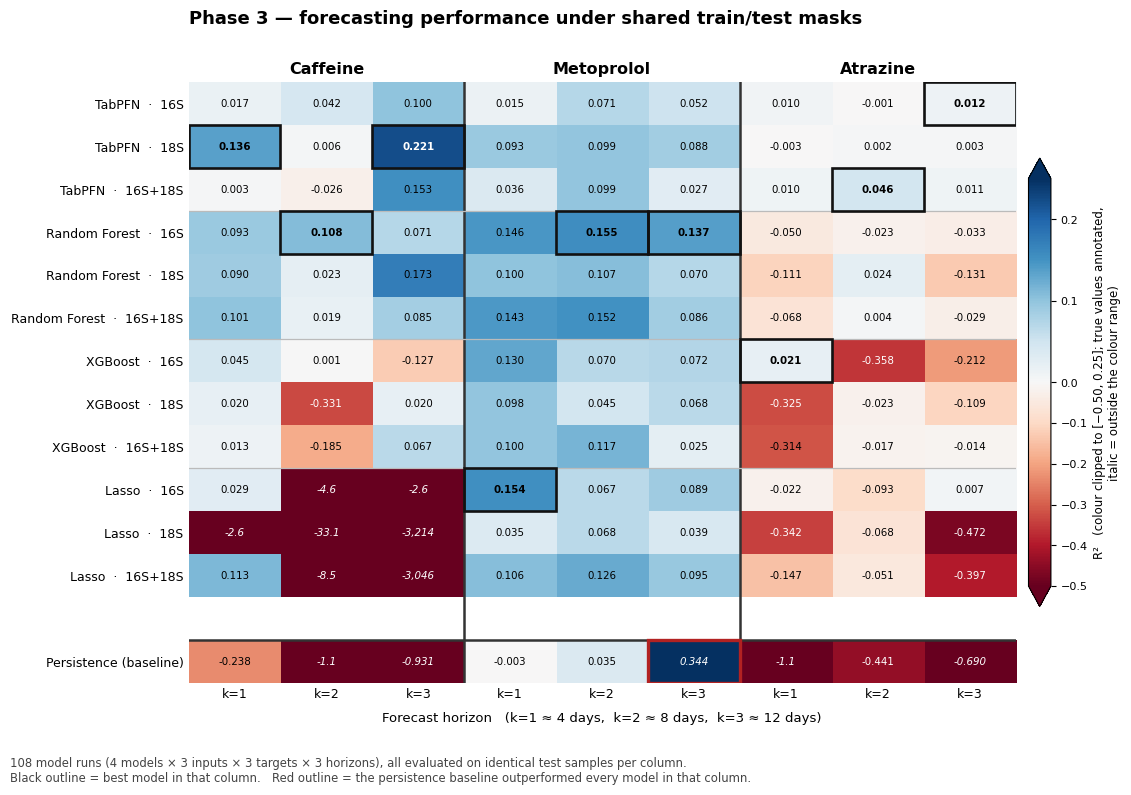

Saved -> results/fig_phase3_forecasting_heatmap.png / .pdf
Baseline beat every model in: ['Metoprolol k=3']


In [15]:
# Cell 4b — same heatmap, fixed layout: no overlapping text, baseline win marked in place
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
from matplotlib.patches import Rectangle

RES = ROOT / "results"
mpl.rcParams.update({"font.family": "DejaVu Sans", "pdf.fonttype": 42, "ps.fonttype": 42})

M_ORDER = ["TabPFN", "Random Forest", "XGBoost", "Lasso"]
I_ORDER = ["16S", "18S", "16S+18S"]
T_ORDER = ["Caffeine", "Metoprolol", "Atrazine"]
H_ORDER = [1, 2, 3]
row_keys = [(m, i) for m in M_ORDER for i in I_ORDER]
col_keys = [(t, h) for t in T_ORDER for h in H_ORDER]

lut = {(r.model, r.input, r.target, r.horizon): r.r2 for r in full.itertuples()}
data = np.array([[lut.get((m, i, t, h), np.nan) for (t, h) in col_keys] for (m, i) in row_keys])
pers_lut = full.groupby(["target", "horizon"], observed=True)["persistence_r2"].first()
pers_row = np.array([pers_lut.loc[(t, h)] for (t, h) in col_keys])

mat = np.vstack([data, np.full((1, len(col_keys)), np.nan), pers_row])
row_labels = [f"{m}  ·  {i}" for (m, i) in row_keys] + ["", "Persistence (baseline)"]
PERS_ROW = mat.shape[0] - 1

VMIN, VMAX = -0.50, 0.25
norm = TwoSlopeNorm(vcenter=0.0, vmin=VMIN, vmax=VMAX)
cmap = plt.get_cmap("RdBu").copy()
cmap.set_bad("#FFFFFF")

fig, ax = plt.subplots(figsize=(11.4, 8.0))
im = ax.imshow(np.ma.masked_invalid(np.clip(mat, VMIN, VMAX)),
               cmap=cmap, norm=norm, aspect="auto")

def cellfmt(v):
    if abs(v) >= 1000: return f"{v:,.0f}"
    if abs(v) >= 1:    return f"{v:.1f}"
    return f"{v:.3f}"

best_row = {}
baseline_wins = []
for j, (t, h) in enumerate(col_keys):
    sub = full[(full.target == t) & (full.horizon == h)]
    b = sub.loc[sub.r2.idxmax()]
    best_row[j] = row_keys.index((b.model, b.input))
    if b.r2 <= pers_lut.loc[(t, h)]:
        baseline_wins.append(j)

for i in range(mat.shape[0]):
    for j in range(mat.shape[1]):
        v = mat[i, j]
        if np.isnan(v):
            continue
        shade = norm(np.clip(v, VMIN, VMAX))
        colour = "white" if (shade < 0.18 or shade > 0.88) else "black"
        ax.text(j, i, cellfmt(v), ha="center", va="center", fontsize=7.4, color=colour,
                fontstyle="italic" if (v < VMIN or v > VMAX) else "normal",
                fontweight="bold" if best_row.get(j) == i else "normal")

# black box = best model in that column
for j, i in best_row.items():
    ax.add_patch(Rectangle((j - .5, i - .5), 1, 1, fill=False,
                           edgecolor="#111111", linewidth=1.9, zorder=5))
# red box = the baseline beat every model in that column
for j in baseline_wins:
    ax.add_patch(Rectangle((j - .5, PERS_ROW - .5), 1, 1, fill=False,
                           edgecolor="#B22222", linewidth=2.4, zorder=6))

ax.set_xticks(range(len(col_keys)))
ax.set_xticklabels([f"k={h}" for (_, h) in col_keys], fontsize=9)
ax.set_yticks(range(len(row_labels)))
ax.set_yticklabels(row_labels, fontsize=9)
ax.tick_params(top=False, labeltop=False, labelbottom=True, length=0)

for x in (2.5, 5.5):
    ax.axvline(x, color="#333333", linewidth=1.8)
for y in (2.5, 5.5, 8.5):
    ax.axhline(y, color="#BBBBBB", linewidth=0.9)
ax.axhline(PERS_ROW - 0.5, color="#333333", linewidth=1.8)
for s in ax.spines.values():
    s.set_visible(False)

sec = ax.secondary_xaxis("top")
sec.set_xticks([1, 4, 7])
sec.set_xticklabels(T_ORDER, fontsize=11.5, fontweight="bold")
sec.tick_params(length=0, pad=4)
for s in sec.spines.values():
    s.set_visible(False)

ax.set_xlabel("Forecast horizon   (k=1 ≈ 4 days,  k=2 ≈ 8 days,  k=3 ≈ 12 days)",
              fontsize=9.5, labelpad=8)
ax.set_title("Phase 3 — forecasting performance under shared train/test masks",
             fontsize=13, fontweight="bold", pad=42, loc="left")

cb = fig.colorbar(im, ax=ax, fraction=0.026, pad=0.015, extend="both")
cb.set_label("R²   (colour clipped to [−0.50, 0.25]; true values annotated,\n"
             "italic = outside the colour range)", fontsize=8.5)
cb.ax.tick_params(labelsize=8)

# legend as a footer, so nothing collides with the group labels
fig.tight_layout()
fig.text(0.012, 0.012,
         "108 model runs (4 models × 3 inputs × 3 targets × 3 horizons), all evaluated on identical "
         "test samples per column.\n"
         "Black outline = best model in that column.   Red outline = the persistence baseline "
         "outperformed every model in that column.",
         fontsize=8.4, color="#444444", va="bottom")
fig.subplots_adjust(bottom=0.14)

for ext in ("png", "pdf"):
    fig.savefig(RES / f"fig_phase3_forecasting_heatmap.{ext}", dpi=300, bbox_inches="tight")
plt.show()

print("Saved -> results/fig_phase3_forecasting_heatmap.png / .pdf")
print("Baseline beat every model in:",
      [f"{col_keys[j][0]} k={col_keys[j][1]}" for j in baseline_wins] or "none")

In [16]:
# Cell 5 — environment snapshot for the reproducibility section
import sys, platform, importlib, json
from pathlib import Path

pkgs = ["numpy", "pandas", "scipy", "sklearn", "xgboost", "tabpfn",
        "torch", "matplotlib", "umap"]

info = {"python": sys.version.split()[0], "platform": platform.platform()}
for p in pkgs:
    try:
        m = importlib.import_module(p)
        info[p] = getattr(m, "__version__", "unknown")
    except ImportError:
        info[p] = "not installed"

try:
    import torch
    info["cuda_available"] = torch.cuda.is_available()
    info["gpu"] = torch.cuda.get_device_name(0) if torch.cuda.is_available() else None
except Exception:
    pass

for k, v in info.items():
    print(f"{k:<18} {v}")

out = ROOT / "results" / "environment_snapshot.json"
out.write_text(json.dumps(info, indent=2), encoding="utf-8")
print(f"\nSaved -> {out}")

python             3.11.15
platform           Linux-6.14.0-37-generic-x86_64-with-glibc2.41
numpy              2.4.4
pandas             3.0.2
scipy              1.17.1
sklearn            1.8.0
xgboost            3.2.0
tabpfn             8.0.6
torch              2.11.0+cu128
matplotlib         3.10.9
umap               0.5.12
cuda_available     True
gpu                NVIDIA L40S

Saved -> /mnt/data/home/tv2414/tabpfn_project/results/environment_snapshot.json


In [23]:
check1 = ['INPUTS', 'MODEL_PATH', 'RANDOM_SEED', 'RESULTS', 'ROOT', 'meta', 'LAG_PAIRS']
missing1 = [v for v in check1 if v not in dir()]
print('step 1:', 'OK' if not missing1 else f'missing: {missing1}')

step 1: missing: ['INPUTS', 'MODEL_PATH', 'RANDOM_SEED', 'RESULTS', 'ROOT', 'meta', 'LAG_PAIRS']


In [ ]:
# نحوه جداسازی در فاز اول در بخش اسپلیت 20 درصدی روی ردیف هست نه تاریخ برای همین این تعدداد نشتی داره که کمه
import numpy as np, pandas as pd
from pathlib import Path
meta = pd.read_csv(Path('/mnt/data/home/tv2414/tabpfn_project/data/processed/meta_clean.csv'))
d = pd.to_datetime(meta['date'])
order = np.argsort(d.values)
n_test = int(round(len(meta) * 0.2))
boundary_date = d.values[order[-n_test]]
same_day = (d.values == boundary_date).sum()
in_test = (d.values[order[-n_test:]] == boundary_date).sum()
print(f"boundary day {pd.Timestamp(boundary_date).date()}: "
      f"{in_test} of {same_day} samples in test → {same_day - in_test} leaked to train")

boundary day 2023-02-23: 6 of 14 samples in test → 8 leaked to train


In [5]:
# === PREVIEW: what changes when TEST_FRACTION goes 0.30 → 0.20 (self-contained) ===
import numpy as np, pandas as pd
from pathlib import Path

ROOT = Path('/mnt/data/home/tv2414/tabpfn_project')
PROC = ROOT / 'data' / 'processed'

# --- censoring parser (identical convention to the phase-3 notebook: '<' and '#' → 0) ---
def parse_censored(series):
    s = series.astype(str).str.strip()
    out = pd.to_numeric(s, errors='coerce')
    below = s.str.startswith('<').fillna(False)
    betw  = s.str.startswith('#').fillna(False)
    lod = pd.to_numeric(s[below].str[1:]).unique()[0] if below.any() else np.nan
    loq = pd.to_numeric(s[betw].str[1:]).unique()[0] if betw.any() else np.nan
    out.loc[below | betw] = 0.0
    return out, lod, loq

meta_f = (pd.read_csv(PROC / 'meta_clean.csv')
            .rename(columns={'Unnamed: 0': 'sample_id'}).set_index('sample_id'))
meta_f['date'] = pd.to_datetime(meta_f['date'], errors='coerce')

hplc = (pd.read_csv(ROOT / 'data' / 'hplc_submission.csv')
          .rename(columns={'Unnamed: 0': 'sample_id'}).set_index('sample_id'))
for c in ['Caffeine', 'Metoprolol', 'Atrazine']:
    vals, _, _ = parse_censored(hplc[c])
    meta_f[c] = vals.reindex(meta_f.index)

HORIZONS, MAX_STEP_DAYS = [1, 2, 3], 6
def build_lagged_index(k):
    pairs = []
    for _, g in meta_f.groupby('location_name'):
        g = g.sort_values('date')
        pos, dates = g.index.to_numpy(), g['date'].to_numpy()
        for i in range(len(pos) - k):
            sd = np.diff(dates[i:i+k+1]).astype('timedelta64[D]').astype(int)
            if (sd <= MAX_STEP_DAYS).all():
                pairs.append((pos[i], pos[i+k]))
    return pairs
LAG = {k: build_lagged_index(k) for k in HORIZONS}

ud = pd.DatetimeIndex(meta_f['date'].dropna().unique()).sort_values()
TARGETS = ['temperature', 'salinity', 'Chl_a_log1p', 'Caffeine', 'Metoprolol', 'Atrazine']
Y = {c: pd.to_numeric(meta_f[c], errors='coerce') for c in TARGETS}

for TF in (0.30, 0.20):
    ci = min(max(int(np.floor(len(ud) * (1.0 - TF))), 1), len(ud) - 1)
    CUT = pd.Timestamp(ud[ci])
    print(f"\n{'='*74}\nTEST_FRACTION = {TF}     GLOBAL_CUT = {CUT.date()}")
    for k in HORIZONS:
        tr = [(f, t) for f, t in LAG[k] if meta_f.loc[t, 'date'] < CUT]
        te = [(f, t) for f, t in LAG[k]
              if meta_f.loc[t, 'date'] >= CUT and meta_f.loc[f, 'date'] >= CUT]
        print(f"  k={k}  pairs: train={len(tr):4d}  test={len(te):4d}")
        parts = []
        for c in TARGETS:
            y = Y[c]
            n  = sum(np.isfinite(y.loc[f]) and np.isfinite(y.loc[t]) for f, t in te)
            extra = ''
            if c == 'Atrazine':
                nz = sum(1 for f, t in te if np.isfinite(y.loc[t]) and y.loc[t] > 0)
                extra = f'/{nz}nz'
            parts.append(f"{c[:11]}={n}{extra}")
        print("        usable test n: " + "  ".join(parts))


TEST_FRACTION = 0.3     GLOBAL_CUT = 2023-01-19
  k=1  pairs: train=1058  test= 429
        usable test n: temperature=373  salinity=374  Chl_a_log1p=391  Caffeine=272  Metoprolol=276  Atrazine=272/7nz
  k=2  pairs: train=1034  test= 406
        usable test n: temperature=357  salinity=358  Chl_a_log1p=378  Caffeine=250  Metoprolol=252  Atrazine=250/7nz
  k=3  pairs: train=1010  test= 386
        usable test n: temperature=341  salinity=342  Chl_a_log1p=365  Caffeine=222  Metoprolol=224  Atrazine=222/7nz

TEST_FRACTION = 0.2     GLOBAL_CUT = 2023-02-27
  k=1  pairs: train=1212  test= 275
        usable test n: temperature=220  salinity=220  Chl_a_log1p=253  Caffeine=138  Metoprolol=142  Atrazine=138/7nz
  k=2  pairs: train=1188  test= 252
        usable test n: temperature=204  salinity=204  Chl_a_log1p=240  Caffeine=125  Metoprolol=127  Atrazine=125/7nz
  k=3  pairs: train=1164  test= 232
        usable test n: temperature=188  salinity=188  Chl_a_log1p=219  Caffeine=109  Metoprolol=

In [6]:

# === RANDOM-SPLIT DIAGNOSTIC — three regimes, TabPFN × 16S ===
import warnings; warnings.filterwarnings('ignore')
import sys, time
import numpy as np, pandas as pd
from pathlib import Path
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from scipy.stats import spearmanr

ROOT = Path('/mnt/data/home/tv2414/tabpfn_project'); sys.path.insert(0, str(ROOT))
PROC, RESULTS = ROOT / 'data' / 'processed', ROOT / 'results'
RANDOM_SEED, MODEL_PATH = 42, "auto"
TEST_FRACTION, MAX_STEP_DAYS = 0.30, 6
HORIZONS = [1, 2, 3]
OUT = RESULTS / 'phase3_random_split_diagnostic.csv'

def parse_censored(series):
    s = series.astype(str).str.strip()
    out = pd.to_numeric(s, errors='coerce')
    below = s.str.startswith('<').fillna(False)
    betw  = s.str.startswith('#').fillna(False)
    out.loc[below | betw] = 0.0
    return out

meta_f = (pd.read_csv(PROC / 'meta_clean.csv')
            .rename(columns={'Unnamed: 0': 'sample_id'}).set_index('sample_id'))
meta_f['date'] = pd.to_datetime(meta_f['date'], errors='coerce')
hplc = (pd.read_csv(ROOT / 'data' / 'hplc_submission.csv')
          .rename(columns={'Unnamed: 0': 'sample_id'}).set_index('sample_id'))
for c in ['Caffeine', 'Metoprolol', 'Atrazine']:
    meta_f[c] = parse_censored(hplc[c]).reindex(meta_f.index)

otu16 = pd.read_csv(PROC / 'otu_16s_clean.csv', index_col=0)
otu16.index = meta_f.index
from src.tabpfn_evaluator import run_tabpfn_with_splits, TABPFN_VERSION

# ---------- lag pairs ----------
def build_lagged_index(k):
    pairs = []
    for _, g in meta_f.groupby('location_name'):
        g = g.sort_values('date')
        pos, dates = g.index.to_numpy(), g['date'].to_numpy()
        for i in range(len(pos) - k):
            sd = np.diff(dates[i:i+k+1]).astype('timedelta64[D]').astype(int)
            if (sd <= MAX_STEP_DAYS).all():
                pairs.append((pos[i], pos[i+k]))
    return pairs
LAG = {k: build_lagged_index(k) for k in HORIZONS}

ud = pd.DatetimeIndex(meta_f['date'].dropna().unique()).sort_values()
ci = min(max(int(np.floor(len(ud) * (1.0 - TEST_FRACTION))), 1), len(ud) - 1)
GLOBAL_CUT = pd.Timestamp(ud[ci])
rng = np.random.default_rng(RANDOM_SEED)

# ---------- three split regimes ----------
def split_temporal(pairs):
    tr, te = [], []
    for f, t in pairs:
        if meta_f.loc[t, 'date'] < GLOBAL_CUT:    tr.append((f, t))
        elif meta_f.loc[f, 'date'] >= GLOBAL_CUT: te.append((f, t))
    return tr, te

def split_random_dates(pairs):
    """Shuffle unique dates; a pair goes to test only if BOTH its dates are test dates."""
    d = ud.to_numpy().copy()
    perm = rng.permutation(len(d))
    n_test = int(round(len(d) * TEST_FRACTION))
    test_dates = set(pd.Timestamp(x) for x in d[perm[:n_test]])
    tr, te = [], []
    for f, t in pairs:
        df, dt = meta_f.loc[f, 'date'], meta_f.loc[t, 'date']
        in_f, in_t = df in test_dates, dt in test_dates
        if in_f and in_t:       te.append((f, t))
        elif not in_f and not in_t: tr.append((f, t))
        # pairs straddling the date sets are discarded
    return tr, te

def split_random_pairs(pairs):
    """Shuffle pairs directly — the leaky regime; reported for comparison only."""
    idx = rng.permutation(len(pairs))
    n_test = int(round(len(pairs) * TEST_FRACTION))
    te = [pairs[i] for i in idx[:n_test]]
    tr = [pairs[i] for i in idx[n_test:]]
    return tr, te

REGIMES = {'temporal': split_temporal,
           'random_dates': split_random_dates,
           'random_pairs': split_random_pairs}

TARGETS = ['temperature', 'salinity', 'Chl_a_log1p', 'Caffeine', 'Metoprolol', 'Atrazine']
rows, t0 = [], time.time()
print(f"GLOBAL_CUT={GLOBAL_CUT.date()} · TabPFN v{TABPFN_VERSION} · "
      f"{len(REGIMES)*len(TARGETS)*len(HORIZONS)} runs\n")

for reg_name, splitter in REGIMES.items():
    for tgt in TARGETS:
        y = pd.to_numeric(meta_f[tgt], errors='coerce')
        for k in HORIZONS:
            tr, te = splitter(LAG[k])
            f_tr = pd.Index([f for f, _ in tr]); t_tr = pd.Index([t for _, t in tr])
            f_te = pd.Index([f for f, _ in te]); t_te = pd.Index([t for _, t in te])

            Xtr, Xte = otu16.loc[f_tr].to_numpy(float), otu16.loc[f_te].to_numpy(float)
            ytr, yte = y.loc[t_tr].to_numpy(float), y.loc[t_te].to_numpy(float)
            ynow = y.loc[f_te].to_numpy(float)

            ok_tr = np.isfinite(Xtr).all(1) & np.isfinite(ytr)
            ok_te = np.isfinite(Xte).all(1) & np.isfinite(yte) & np.isfinite(ynow)
            Xtr, ytr = Xtr[ok_tr], ytr[ok_tr]
            Xte, yte, ynow = Xte[ok_te], yte[ok_te], ynow[ok_te]
            if len(yte) < 30 or np.unique(yte).size < 2:
                print(f"  {reg_name:13s} {tgt:12s} k={k}: n_test={len(yte)} — skipped"); continue

            per_r2  = r2_score(yte, ynow)
            per_mae = mean_absolute_error(yte, ynow)
            n = len(ytr)
            res = run_tabpfn_with_splits(
                model_path=MODEL_PATH, target_name=tgt,
                meta=pd.DataFrame({tgt: np.concatenate([ytr, yte])}),
                otu=pd.DataFrame(np.vstack([Xtr, Xte])),
                splits=[(np.arange(n), np.arange(n, n + len(yte)))],
                strategy_name=f'{reg_name}_k{k}', input_name='16S',
                log_target=False, random_seed=RANDOM_SEED, verbose=False)

            rows.append({'regime': reg_name, 'target': tgt, 'horizon_k': k,
                'n_train': int(len(ytr)), 'n_test': int(len(yte)),
                'r2': res['r2_mean'], 'mae': res['mae_mean'], 'rmse': res['rmse_mean'],
                'per_r2': per_r2, 'per_mae': per_mae,
                'delta_vs_persistence': res['r2_mean'] - per_r2,
                'var_test': float(np.var(yte)), 'var_train': float(np.var(ytr)),
                'global_cut': str(GLOBAL_CUT.date())})
            print(f"  {reg_name:13s} {tgt:12s} k={k}  n_te={len(yte):4d}  "
                  f"R²={res['r2_mean']:+7.3f}  MAE={res['mae_mean']:8.3f}  "
                  f"(persist R²={per_r2:+.3f})")
        pd.DataFrame(rows).to_csv(OUT, index=False)

print(f"\nDONE · {(time.time()-t0)/60:.1f} min → {OUT.name}")

# ---------- comparison table ----------
df = pd.DataFrame(rows)
piv = df.pivot_table(index=['target', 'horizon_k'], columns='regime', values='r2')
piv = piv[['temporal', 'random_dates', 'random_pairs']]
piv['leak_gap'] = piv.random_pairs - piv.random_dates
piv['time_gap'] = piv.random_dates - piv.temporal
print('\n=== TabPFN R² by split regime (16S) ===')
print(piv.round(3).to_string())

GLOBAL_CUT=2023-01-19 · TabPFN v8.0.6 · 54 runs

  temporal      temperature  k=1  n_te= 373  R²= +0.135  MAE=   1.797  (persist R²=+0.783)
  temporal      temperature  k=2  n_te= 357  R²= -0.166  MAE=   2.110  (persist R²=+0.692)
  temporal      temperature  k=3  n_te= 341  R²= -0.007  MAE=   1.971  (persist R²=+0.555)
  temporal      salinity     k=1  n_te= 374  R²= +0.496  MAE=   2.446  (persist R²=+0.517)
  temporal      salinity     k=2  n_te= 358  R²= +0.431  MAE=   2.585  (persist R²=+0.429)
  temporal      salinity     k=3  n_te= 342  R²= +0.527  MAE=   2.345  (persist R²=+0.510)
  temporal      Chl_a_log1p  k=1  n_te= 391  R²= +0.539  MAE=   0.457  (persist R²=+0.527)
  temporal      Chl_a_log1p  k=2  n_te= 378  R²= +0.465  MAE=   0.508  (persist R²=+0.532)
  temporal      Chl_a_log1p  k=3  n_te= 365  R²= +0.487  MAE=   0.495  (persist R²=+0.462)
  temporal      Caffeine     k=1  n_te= 272  R²= +0.123  MAE=  13.167  (persist R²=-0.239)
  temporal      Caffeine     k=2  n_te= 2

In [7]:
# === RANDOM-SPLIT DIAGNOSTIC — multi-seed, TabPFN × 16S ===
import warnings; warnings.filterwarnings('ignore')
import sys, time
import numpy as np, pandas as pd
from pathlib import Path
from sklearn.metrics import r2_score, mean_absolute_error

ROOT = Path('/mnt/data/home/tv2414/tabpfn_project'); sys.path.insert(0, str(ROOT))
PROC, RESULTS = ROOT / 'data' / 'processed', ROOT / 'results'
MODEL_PATH, MODEL_SEED = "auto", 42
TEST_FRACTION, MAX_STEP_DAYS = 0.30, 6
HORIZONS, SPLIT_SEEDS = [1, 2, 3], [0, 1, 2, 3, 4]
OUT = RESULTS / 'phase3_random_split_multiseed.csv'

def parse_censored(series):
    s = series.astype(str).str.strip()
    out = pd.to_numeric(s, errors='coerce')
    out.loc[s.str.startswith('<').fillna(False) | s.str.startswith('#').fillna(False)] = 0.0
    return out

meta_f = (pd.read_csv(PROC / 'meta_clean.csv')
            .rename(columns={'Unnamed: 0': 'sample_id'}).set_index('sample_id'))
meta_f['date'] = pd.to_datetime(meta_f['date'], errors='coerce')
hplc = (pd.read_csv(ROOT / 'data' / 'hplc_submission.csv')
          .rename(columns={'Unnamed: 0': 'sample_id'}).set_index('sample_id'))
for c in ['Caffeine', 'Metoprolol', 'Atrazine']:
    meta_f[c] = parse_censored(hplc[c]).reindex(meta_f.index)

otu16 = pd.read_csv(PROC / 'otu_16s_clean.csv', index_col=0)
otu16.index = meta_f.index
from src.tabpfn_evaluator import run_tabpfn_with_splits, TABPFN_VERSION

def build_lagged_index(k):
    pairs = []
    for _, g in meta_f.groupby('location_name'):
        g = g.sort_values('date')
        pos, dates = g.index.to_numpy(), g['date'].to_numpy()
        for i in range(len(pos) - k):
            sd = np.diff(dates[i:i+k+1]).astype('timedelta64[D]').astype(int)
            if (sd <= MAX_STEP_DAYS).all():
                pairs.append((pos[i], pos[i+k]))
    return pairs
LAG = {k: build_lagged_index(k) for k in HORIZONS}

ud = pd.DatetimeIndex(meta_f['date'].dropna().unique()).sort_values()
ci = min(max(int(np.floor(len(ud) * (1.0 - TEST_FRACTION))), 1), len(ud) - 1)
GLOBAL_CUT = pd.Timestamp(ud[ci])

def split_temporal(pairs, rng):
    tr, te = [], []
    for f, t in pairs:
        if meta_f.loc[t, 'date'] < GLOBAL_CUT:    tr.append((f, t))
        elif meta_f.loc[f, 'date'] >= GLOBAL_CUT: te.append((f, t))
    return tr, te

def split_random_dates(pairs, rng):
    d = ud.to_numpy().copy()
    perm = rng.permutation(len(d))
    n_test = int(round(len(d) * TEST_FRACTION))
    test_dates = set(pd.Timestamp(x) for x in d[perm[:n_test]])
    tr, te = [], []
    for f, t in pairs:
        in_f = meta_f.loc[f, 'date'] in test_dates
        in_t = meta_f.loc[t, 'date'] in test_dates
        if in_f and in_t:           te.append((f, t))
        elif not in_f and not in_t: tr.append((f, t))
    return tr, te

def split_random_pairs(pairs, rng):
    idx = rng.permutation(len(pairs))
    n_test = int(round(len(pairs) * TEST_FRACTION))
    return [pairs[i] for i in idx[n_test:]], [pairs[i] for i in idx[:n_test]]

REGIMES = {'temporal': (split_temporal, [0]),          # deterministic → one seed
           'random_dates': (split_random_dates, SPLIT_SEEDS),
           'random_pairs': (split_random_pairs, SPLIT_SEEDS)}

TARGETS = ['temperature', 'salinity', 'Chl_a_log1p', 'Caffeine', 'Metoprolol', 'Atrazine']
rows, t0 = [], time.time()
total = sum(len(s) for _, s in REGIMES.values()) * len(TARGETS) * len(HORIZONS)
print(f"GLOBAL_CUT={GLOBAL_CUT.date()} · TabPFN v{TABPFN_VERSION} · {total} runs\n")

for reg_name, (splitter, seeds) in REGIMES.items():
    for seed in seeds:
        rng = np.random.default_rng(seed)
        for tgt in TARGETS:
            y = pd.to_numeric(meta_f[tgt], errors='coerce')
            for k in HORIZONS:
                tr, te = splitter(LAG[k], rng)
                f_tr = pd.Index([f for f, _ in tr]); t_tr = pd.Index([t for _, t in tr])
                f_te = pd.Index([f for f, _ in te]); t_te = pd.Index([t for _, t in te])
                Xtr, Xte = otu16.loc[f_tr].to_numpy(float), otu16.loc[f_te].to_numpy(float)
                ytr, yte = y.loc[t_tr].to_numpy(float), y.loc[t_te].to_numpy(float)
                ynow = y.loc[f_te].to_numpy(float)
                ok_tr = np.isfinite(Xtr).all(1) & np.isfinite(ytr)
                ok_te = np.isfinite(Xte).all(1) & np.isfinite(yte) & np.isfinite(ynow)
                Xtr, ytr = Xtr[ok_tr], ytr[ok_tr]
                Xte, yte, ynow = Xte[ok_te], yte[ok_te], ynow[ok_te]
                if len(yte) < 30 or np.unique(yte).size < 2:
                    continue
                n = len(ytr)
                res = run_tabpfn_with_splits(
                    model_path=MODEL_PATH, target_name=tgt,
                    meta=pd.DataFrame({tgt: np.concatenate([ytr, yte])}),
                    otu=pd.DataFrame(np.vstack([Xtr, Xte])),
                    splits=[(np.arange(n), np.arange(n, n + len(yte)))],
                    strategy_name=f'{reg_name}_s{seed}_k{k}', input_name='16S',
                    log_target=False, random_seed=MODEL_SEED, verbose=False)
                rows.append({'regime': reg_name, 'split_seed': seed, 'target': tgt,
                    'horizon_k': k, 'n_train': int(n), 'n_test': int(len(yte)),
                    'r2': res['r2_mean'], 'mae': res['mae_mean'],
                    'per_r2': r2_score(yte, ynow),
                    'per_mae': mean_absolute_error(yte, ynow),
                    'var_test': float(np.var(yte))})
        pd.DataFrame(rows).to_csv(OUT, index=False)
        print(f"  {reg_name:13s} seed={seed} done  ({(time.time()-t0)/60:.1f} min)")

print(f"\nDONE · {(time.time()-t0)/60:.1f} min → {OUT.name}")

# ---------- summary: mean ± sd over seeds ----------
df = pd.DataFrame(rows)
g = df.groupby(['target', 'horizon_k', 'regime'])
summ = g['r2'].agg(['mean', 'std']).round(3)
nt   = g['n_test'].agg(['mean', 'min', 'max']).round(0)
tab = summ.join(nt, rsuffix='_n').unstack('regime')
print('\n=== TabPFN R² per regime: mean ± sd over split seeds ===')
for tgt in TARGETS:
    print(f"\n{tgt}")
    for k in HORIZONS:
        sub = df[(df.target == tgt) & (df.horizon_k == k)]
        parts = []
        for reg in ['temporal', 'random_dates', 'random_pairs']:
            s = sub[sub.regime == reg]
            if len(s) == 0: parts.append(f"{reg}: —"); continue
            sd = f"±{s.r2.std():.3f}" if len(s) > 1 else ""
            parts.append(f"{reg}: {s.r2.mean():+.3f}{sd} (n={s.n_test.mean():.0f})")
        print(f"  k={k}  " + " | ".join(parts))

GLOBAL_CUT=2023-01-19 · TabPFN v8.0.6 · 198 runs

  temporal      seed=0 done  (0.7 min)
  random_dates  seed=0 done  (1.3 min)
  random_dates  seed=1 done  (1.8 min)
  random_dates  seed=2 done  (2.4 min)
  random_dates  seed=3 done  (3.0 min)
  random_dates  seed=4 done  (3.6 min)
  random_pairs  seed=0 done  (4.4 min)
  random_pairs  seed=1 done  (5.1 min)
  random_pairs  seed=2 done  (5.8 min)
  random_pairs  seed=3 done  (6.5 min)
  random_pairs  seed=4 done  (7.1 min)

DONE · 7.1 min → phase3_random_split_multiseed.csv

=== TabPFN R² per regime: mean ± sd over split seeds ===

temperature
  k=1  temporal: +0.135 (n=373) | random_dates: +0.863±0.139 (n=100) | random_pairs: +0.976±0.003 (n=325)
  k=2  temporal: -0.166 (n=357) | random_dates: +0.936±0.040 (n=99) | random_pairs: +0.977±0.001 (n=318)
  k=3  temporal: -0.007 (n=341) | random_dates: +0.949±0.021 (n=70) | random_pairs: +0.976±0.004 (n=310)

salinity
  k=1  temporal: +0.496 (n=374) | random_dates: +0.727±0.108 (n=119) | r

saved -> phase3_split_regime_comparison.png / .pdf


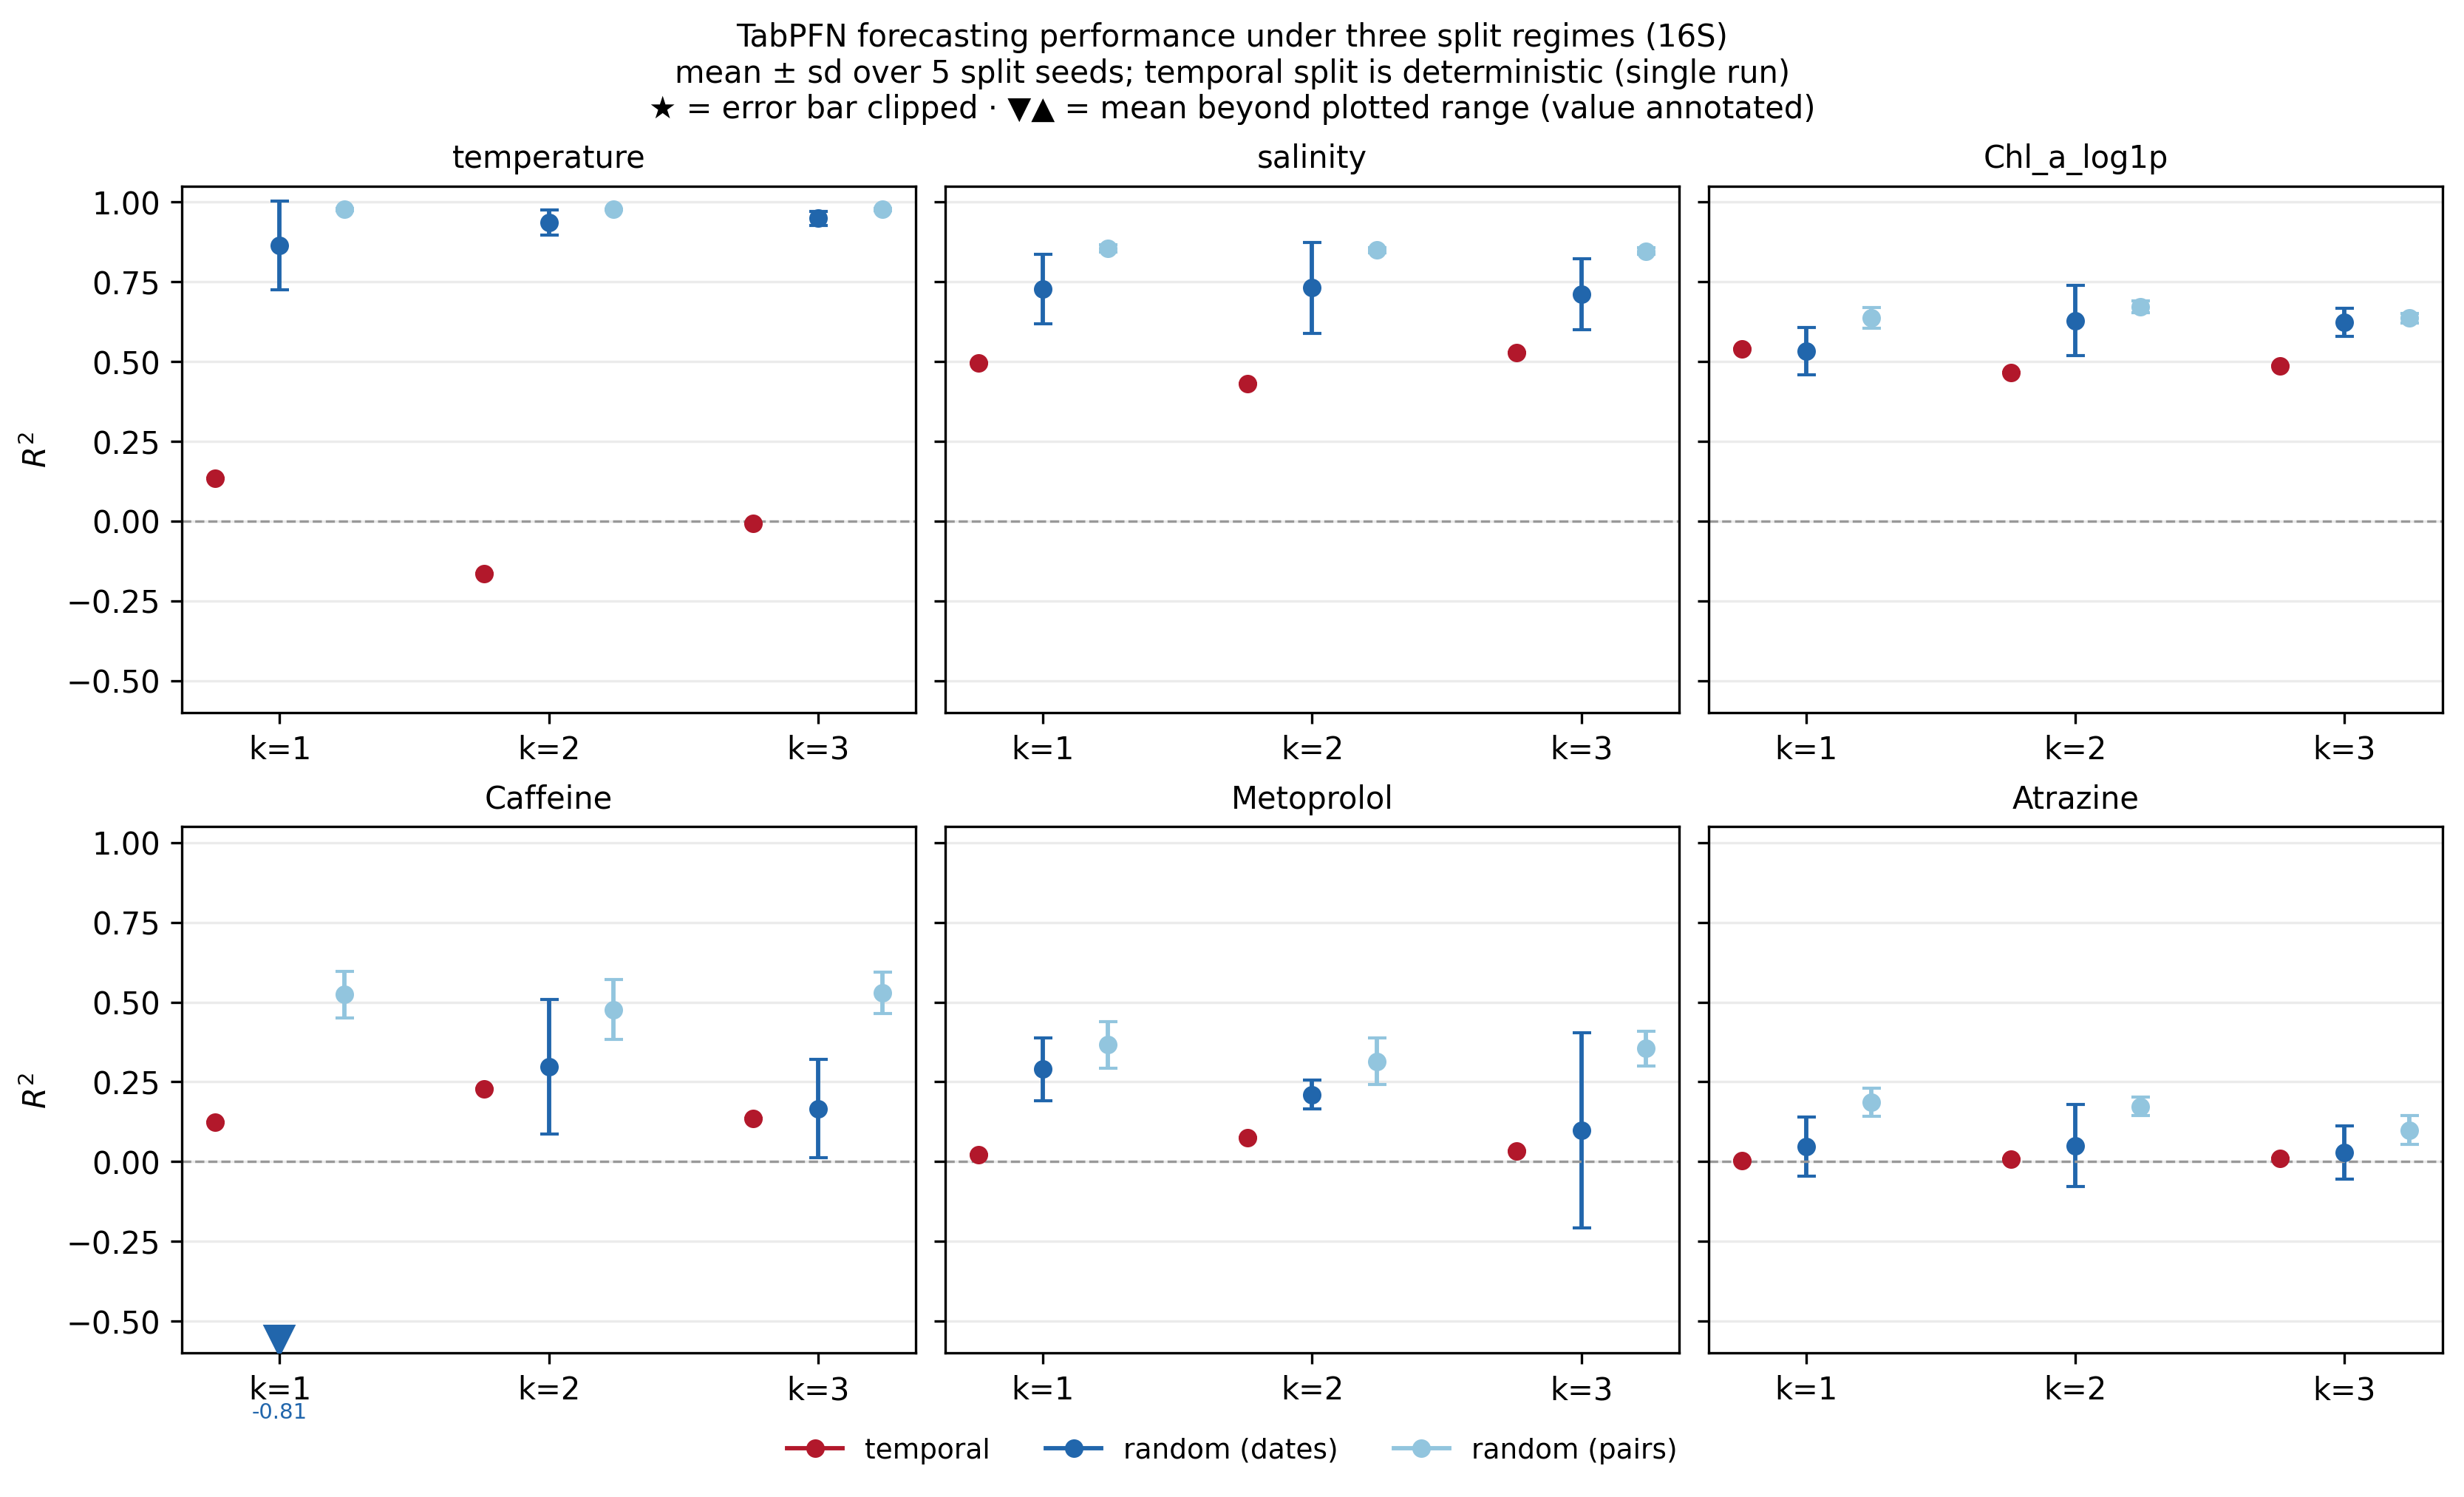

In [12]:
# === FIGURE — TabPFN R² across three split regimes, mean ± sd over seeds ===
import warnings; warnings.filterwarnings('ignore')
import matplotlib; matplotlib.use('Agg')
import matplotlib.pyplot as plt
import numpy as np, pandas as pd
from matplotlib.lines import Line2D
from pathlib import Path

R = Path('/mnt/data/home/tv2414/tabpfn_project/results')
df = pd.read_csv(R / 'phase3_random_split_multiseed.csv')

TGT = ['temperature', 'salinity', 'Chl_a_log1p', 'Caffeine', 'Metoprolol', 'Atrazine']
REG = ['temporal', 'random_dates', 'random_pairs']
RLB = ['temporal', 'random (dates)', 'random (pairs)']
COL = ['#b2182b', '#2166ac', '#92c5de']
Y_LO, Y_HI = -0.6, 1.05

fig, axes = plt.subplots(2, 3, figsize=(11, 6.4), sharey=True, constrained_layout=True)

for ax, tgt in zip(axes.ravel(), TGT):
    sub = df[df.target == tgt]
    x = np.arange(3)
    for i, (reg, col) in enumerate(zip(REG, COL)):
        off = (i - 1) * 0.24
        for k, xi in zip([1, 2, 3], x + off):
            s = sub[(sub.regime == reg) & (sub.horizon_k == k)]['r2']
            if len(s) == 0:
                continue
            mi = s.mean()
            ei = s.std() if len(s) > 1 else 0.0
            if not np.isfinite(mi):
                continue

            if mi < Y_LO or mi > Y_HI:
                # mean itself is off-scale — pin to the edge and annotate the value
                y_edge = Y_LO + 0.04 if mi < Y_LO else Y_HI - 0.04
                ax.plot(xi, y_edge, marker='v' if mi < Y_LO else '^',
                        ms=9, color=col, zorder=6)
                ax.annotate(f'{mi:+.2f}', (xi, y_edge), fontsize=7, color=col,
                            ha='center',
                            va='top' if mi < Y_LO else 'bottom',
                            xytext=(0, -20 if mi < Y_LO else 9),
                            textcoords='offset points')
            else:
                lo, hi = max(mi - ei, Y_LO), min(mi + ei, Y_HI)
                ax.errorbar(xi, mi, yerr=[[mi - lo], [hi - mi]], fmt='o', ms=5,
                            capsize=3, lw=1.4, color=col)
                if mi - ei < Y_LO or mi + ei > Y_HI:
                    ax.plot(xi, mi, marker='*', ms=11, color=col, zorder=5)

    ax.axhline(0, color='0.6', lw=0.8, ls='--')
    ax.set_xticks(x, ['k=1', 'k=2', 'k=3'])
    ax.set_title(tgt, fontsize=10)
    ax.set_ylim(Y_LO, Y_HI)
    ax.grid(axis='y', alpha=0.25)

axes[0, 0].set_ylabel('$R^2$')
axes[1, 0].set_ylabel('$R^2$')

handles = [Line2D([0], [0], marker='o', color=c, lw=1.4, ms=5, label=l)
           for c, l in zip(COL, RLB)]
fig.legend(handles=handles, loc='lower center', ncol=3, frameon=False,
           fontsize=9, bbox_to_anchor=(0.5, -0.04))

fig.suptitle('TabPFN forecasting performance under three split regimes (16S)\n'
             'mean ± sd over 5 split seeds; temporal split is deterministic (single run)\n'
             '★ = error bar clipped · ▼▲ = mean beyond plotted range (value annotated)',
             fontsize=10)

for ext in ('png', 'pdf'):
    fig.savefig(R / f'phase3_split_regime_comparison.{ext}', dpi=300, bbox_inches='tight')
plt.close(fig)
print('saved -> phase3_split_regime_comparison.png / .pdf')

from IPython.display import Image, display
display(Image(str(R / 'phase3_split_regime_comparison.png')))

In [16]:
# === PRESENTATION TABLE — split-regime effects, TabPFN × 16S ===
import pandas as pd, numpy as np
from pathlib import Path

R = Path('/mnt/data/home/tv2414/tabpfn_project/results')
df = pd.read_csv(R / 'phase3_random_split_multiseed.csv')

TGT = ['temperature', 'salinity', 'Chl_a_log1p', 'Caffeine', 'Metoprolol', 'Atrazine']
REG = ['temporal', 'random_dates', 'random_pairs']

g    = df.groupby(['target', 'horizon_k', 'regime'])['r2']
mean = g.mean().unstack('regime')[REG]
sd   = g.std().unstack('regime')[REG]
nte  = df.groupby(['target', 'horizon_k', 'regime'])['n_test'].mean().unstack('regime')[REG]

rows = []
for t in TGT:
    for k in [1, 2, 3]:
        m, s, n = mean.loc[(t, k)], sd.loc[(t, k)], nte.loc[(t, k)]
        fmt = lambda r: (f"{m[r]:+.3f}" if not np.isfinite(s[r]) or s[r] == 0
                         else f"{m[r]:+.3f} ± {s[r]:.3f}")
        rows.append({
            'Target': t, 'k': k,
            'Temporal': fmt('temporal'),
            'Random (dates)': fmt('random_dates'),
            'Random (pairs)': fmt('random_pairs'),
            'Shift effect': f"{m.random_dates - m.temporal:+.3f}",
            'Leak effect':  f"{m.random_pairs - m.random_dates:+.3f}",
            'n test (temp/rand)': f"{n.temporal:.0f} / {n.random_dates:.0f}",
        })
tbl = pd.DataFrame(rows)

print(tbl.to_string(index=False))
tbl.to_csv(R / 'phase3_split_regime_table.csv', index=False)

# ---- Markdown, built by hand (no tabulate needed) ----
cols = list(tbl.columns)
lines = ['| ' + ' | '.join(cols) + ' |',
         '|' + '|'.join(['---'] * len(cols)) + '|']
for _, r in tbl.iterrows():
    lines.append('| ' + ' | '.join(str(r[c]) for c in cols) + ' |')
(R / 'phase3_split_regime_table.md').write_text('\n'.join(lines))

# ---- LaTeX ----
latex = tbl.to_latex(index=False, escape=True, column_format='llcccccc',
                     caption=('TabPFN forecasting $R^2$ under three split regimes (16S input). '
                              'Random regimes are averaged over five split seeds; the temporal '
                              'split is deterministic. Shift effect = random(dates) $-$ temporal; '
                              'leak effect = random(pairs) $-$ random(dates).'),
                     label='tab:split-regimes')
(R / 'phase3_split_regime_table.tex').write_text(latex)
print('\nsaved -> phase3_split_regime_table.csv / .md / .tex')

     Target  k Temporal Random (dates) Random (pairs) Shift effect Leak effect n test (temp/rand)
temperature  1   +0.135 +0.863 ± 0.139 +0.976 ± 0.003       +0.728      +0.113          373 / 100
temperature  2   -0.166 +0.936 ± 0.040 +0.977 ± 0.001       +1.102      +0.041           357 / 99
temperature  3   -0.007 +0.949 ± 0.021 +0.976 ± 0.004       +0.955      +0.028           341 / 70
   salinity  1   +0.496 +0.727 ± 0.108 +0.855 ± 0.012       +0.231      +0.127          374 / 119
   salinity  2   +0.431 +0.731 ± 0.143 +0.849 ± 0.008       +0.300      +0.118           358 / 81
   salinity  3   +0.527 +0.711 ± 0.111 +0.846 ± 0.010       +0.184      +0.135           342 / 87
Chl_a_log1p  1   +0.539 +0.533 ± 0.074 +0.638 ± 0.033       -0.006      +0.104          391 / 119
Chl_a_log1p  2   +0.465 +0.628 ± 0.110 +0.671 ± 0.018       +0.163      +0.043          378 / 129
Chl_a_log1p  3   +0.487 +0.623 ± 0.045 +0.636 ± 0.015       +0.136      +0.013          365 / 105
   Caffeine  1   +0.

In [17]:
styled = (tbl.style
    .hide(axis='index')
    .set_caption('TabPFN forecasting R² by split regime (16S)')
    .set_table_styles([
        {'selector': 'caption', 'props': 'font-size:14px; font-weight:600; padding-bottom:8px;'},
        {'selector': 'th', 'props': 'background-color:#f0efec; text-align:center; padding:6px;'},
        {'selector': 'td', 'props': 'text-align:center; padding:5px 8px;'},
    ])
    .apply(lambda c: ['background-color:#d6e6f4' if abs(float(v)) > 0.5 else
                      '' for v in c], subset=['Shift effect'])
    .apply(lambda c: ['background-color:#f7dcdc' if abs(float(v)) > 0.10 else
                      '' for v in c], subset=['Leak effect']))
styled  # renders in the notebook

Target,k,Temporal,Random (dates),Random (pairs),Shift effect,Leak effect,n test (temp/rand)
temperature,1,+0.135,+0.863 ± 0.139,+0.976 ± 0.003,+0.728,+0.113,373 / 100
temperature,2,-0.166,+0.936 ± 0.040,+0.977 ± 0.001,+1.102,+0.041,357 / 99
temperature,3,-0.007,+0.949 ± 0.021,+0.976 ± 0.004,+0.955,+0.028,341 / 70
salinity,1,+0.496,+0.727 ± 0.108,+0.855 ± 0.012,+0.231,+0.127,374 / 119
salinity,2,+0.431,+0.731 ± 0.143,+0.849 ± 0.008,+0.300,+0.118,358 / 81
salinity,3,+0.527,+0.711 ± 0.111,+0.846 ± 0.010,+0.184,+0.135,342 / 87
Chl_a_log1p,1,+0.539,+0.533 ± 0.074,+0.638 ± 0.033,-0.006,+0.104,391 / 119
Chl_a_log1p,2,+0.465,+0.628 ± 0.110,+0.671 ± 0.018,+0.163,+0.043,378 / 129
Chl_a_log1p,3,+0.487,+0.623 ± 0.045,+0.636 ± 0.015,+0.136,+0.013,365 / 105
Caffeine,1,+0.123,-0.811 ± 2.052,+0.524 ± 0.072,-0.934,+1.334,272 / 98


In [24]:
# === Chapter-8 style table for the split-regime diagnostic ===
import numpy as np, pandas as pd
from pathlib import Path

R = Path('/mnt/data/home/tv2414/tabpfn_project/results')
df = pd.read_csv(R / 'phase3_random_split_multiseed.csv')

TGT = ['temperature', 'salinity', 'Chl_a_log1p', 'Caffeine', 'Metoprolol', 'Atrazine']
g    = df.groupby(['target', 'horizon_k', 'regime'])['r2']
mean, sd = g.mean().unstack('regime'), g.std().unstack('regime')

def verdict(shift, leak, sd_rd):
    if sd_rd > 0.30:            return 'unstable — not interpreted'
    if shift > 0.50:            return 'dominated by temporal shift'
    if leak > 2 * max(shift, 0.01): return 'leakage-driven'
    if shift < 0.10:            return 'insensitive to split'
    return 'moderate shift effect'

rows = []
for t in TGT:
    for k in [1, 2, 3]:
        m, s = mean.loc[(t, k)], sd.loc[(t, k)]
        shift = m.random_dates - m.temporal
        leak  = m.random_pairs - m.random_dates
        esc = t.replace('_', r'\_')
        rows.append({
            'Target': esc, 'Horizon k': k,
            'Temporal R²': f'{m.temporal:.3f}',
            'Random (dates) R²': f'{m.random_dates:.3f} $\\pm$ {s.random_dates:.3f}',
            'Random (pairs) R²': f'{m.random_pairs:.3f} $\\pm$ {s.random_pairs:.3f}',
            'Shift': f'{shift:+.3f}',
            'Leak': f'{leak:+.3f}',
            'Verdict': verdict(shift, leak, s.random_dates)})
tbl = pd.DataFrame(rows)

latex = tbl.to_latex(index=False, escape=False, column_format='lrlllrrl',
    caption=('TabPFN forecasting $R^2$ under three split regimes (16S input). '
             'Random regimes report mean $\\pm$ sd over five split seeds; the temporal '
             'split is deterministic. Shift $=$ random(dates) $-$ temporal isolates the '
             'effect of distributional shift; Leak $=$ random(pairs) $-$ random(dates) '
             'quantifies the inflation from pair-level randomisation.'),
    label='tab:split-regimes')
(R / 'phase3_split_regime_table.tex').write_text(latex)

# markdown twin, same columns
cols = list(tbl.columns)
md = ['| ' + ' | '.join(cols) + ' |', '|' + '|'.join(['---'] * len(cols)) + '|']
md += ['| ' + ' | '.join(str(r[c]).replace('$\\pm$', '±').replace('\\_', '_')
                         for c in cols) + ' |' for _, r in tbl.iterrows()]
(R / 'phase3_split_regime_table.md').write_text('\n'.join(md))

print(tbl.to_string(index=False))
print('\nsaved -> phase3_split_regime_table.tex / .md')

       Target  Horizon k Temporal R²  Random (dates) R² Random (pairs) R²  Shift   Leak                     Verdict
  temperature          1       0.135  0.863 $\pm$ 0.139 0.976 $\pm$ 0.003 +0.728 +0.113 dominated by temporal shift
  temperature          2      -0.166  0.936 $\pm$ 0.040 0.977 $\pm$ 0.001 +1.102 +0.041 dominated by temporal shift
  temperature          3      -0.007  0.949 $\pm$ 0.021 0.976 $\pm$ 0.004 +0.955 +0.028 dominated by temporal shift
     salinity          1       0.496  0.727 $\pm$ 0.108 0.855 $\pm$ 0.012 +0.231 +0.127       moderate shift effect
     salinity          2       0.431  0.731 $\pm$ 0.143 0.849 $\pm$ 0.008 +0.300 +0.118       moderate shift effect
     salinity          3       0.527  0.711 $\pm$ 0.111 0.846 $\pm$ 0.010 +0.184 +0.135       moderate shift effect
Chl\_a\_log1p          1       0.539  0.533 $\pm$ 0.074 0.638 $\pm$ 0.033 -0.006 +0.104              leakage-driven
Chl\_a\_log1p          2       0.465  0.628 $\pm$ 0.110 0.671 $\pm$ 0.01

saved -> phase3_split_regime_table.png


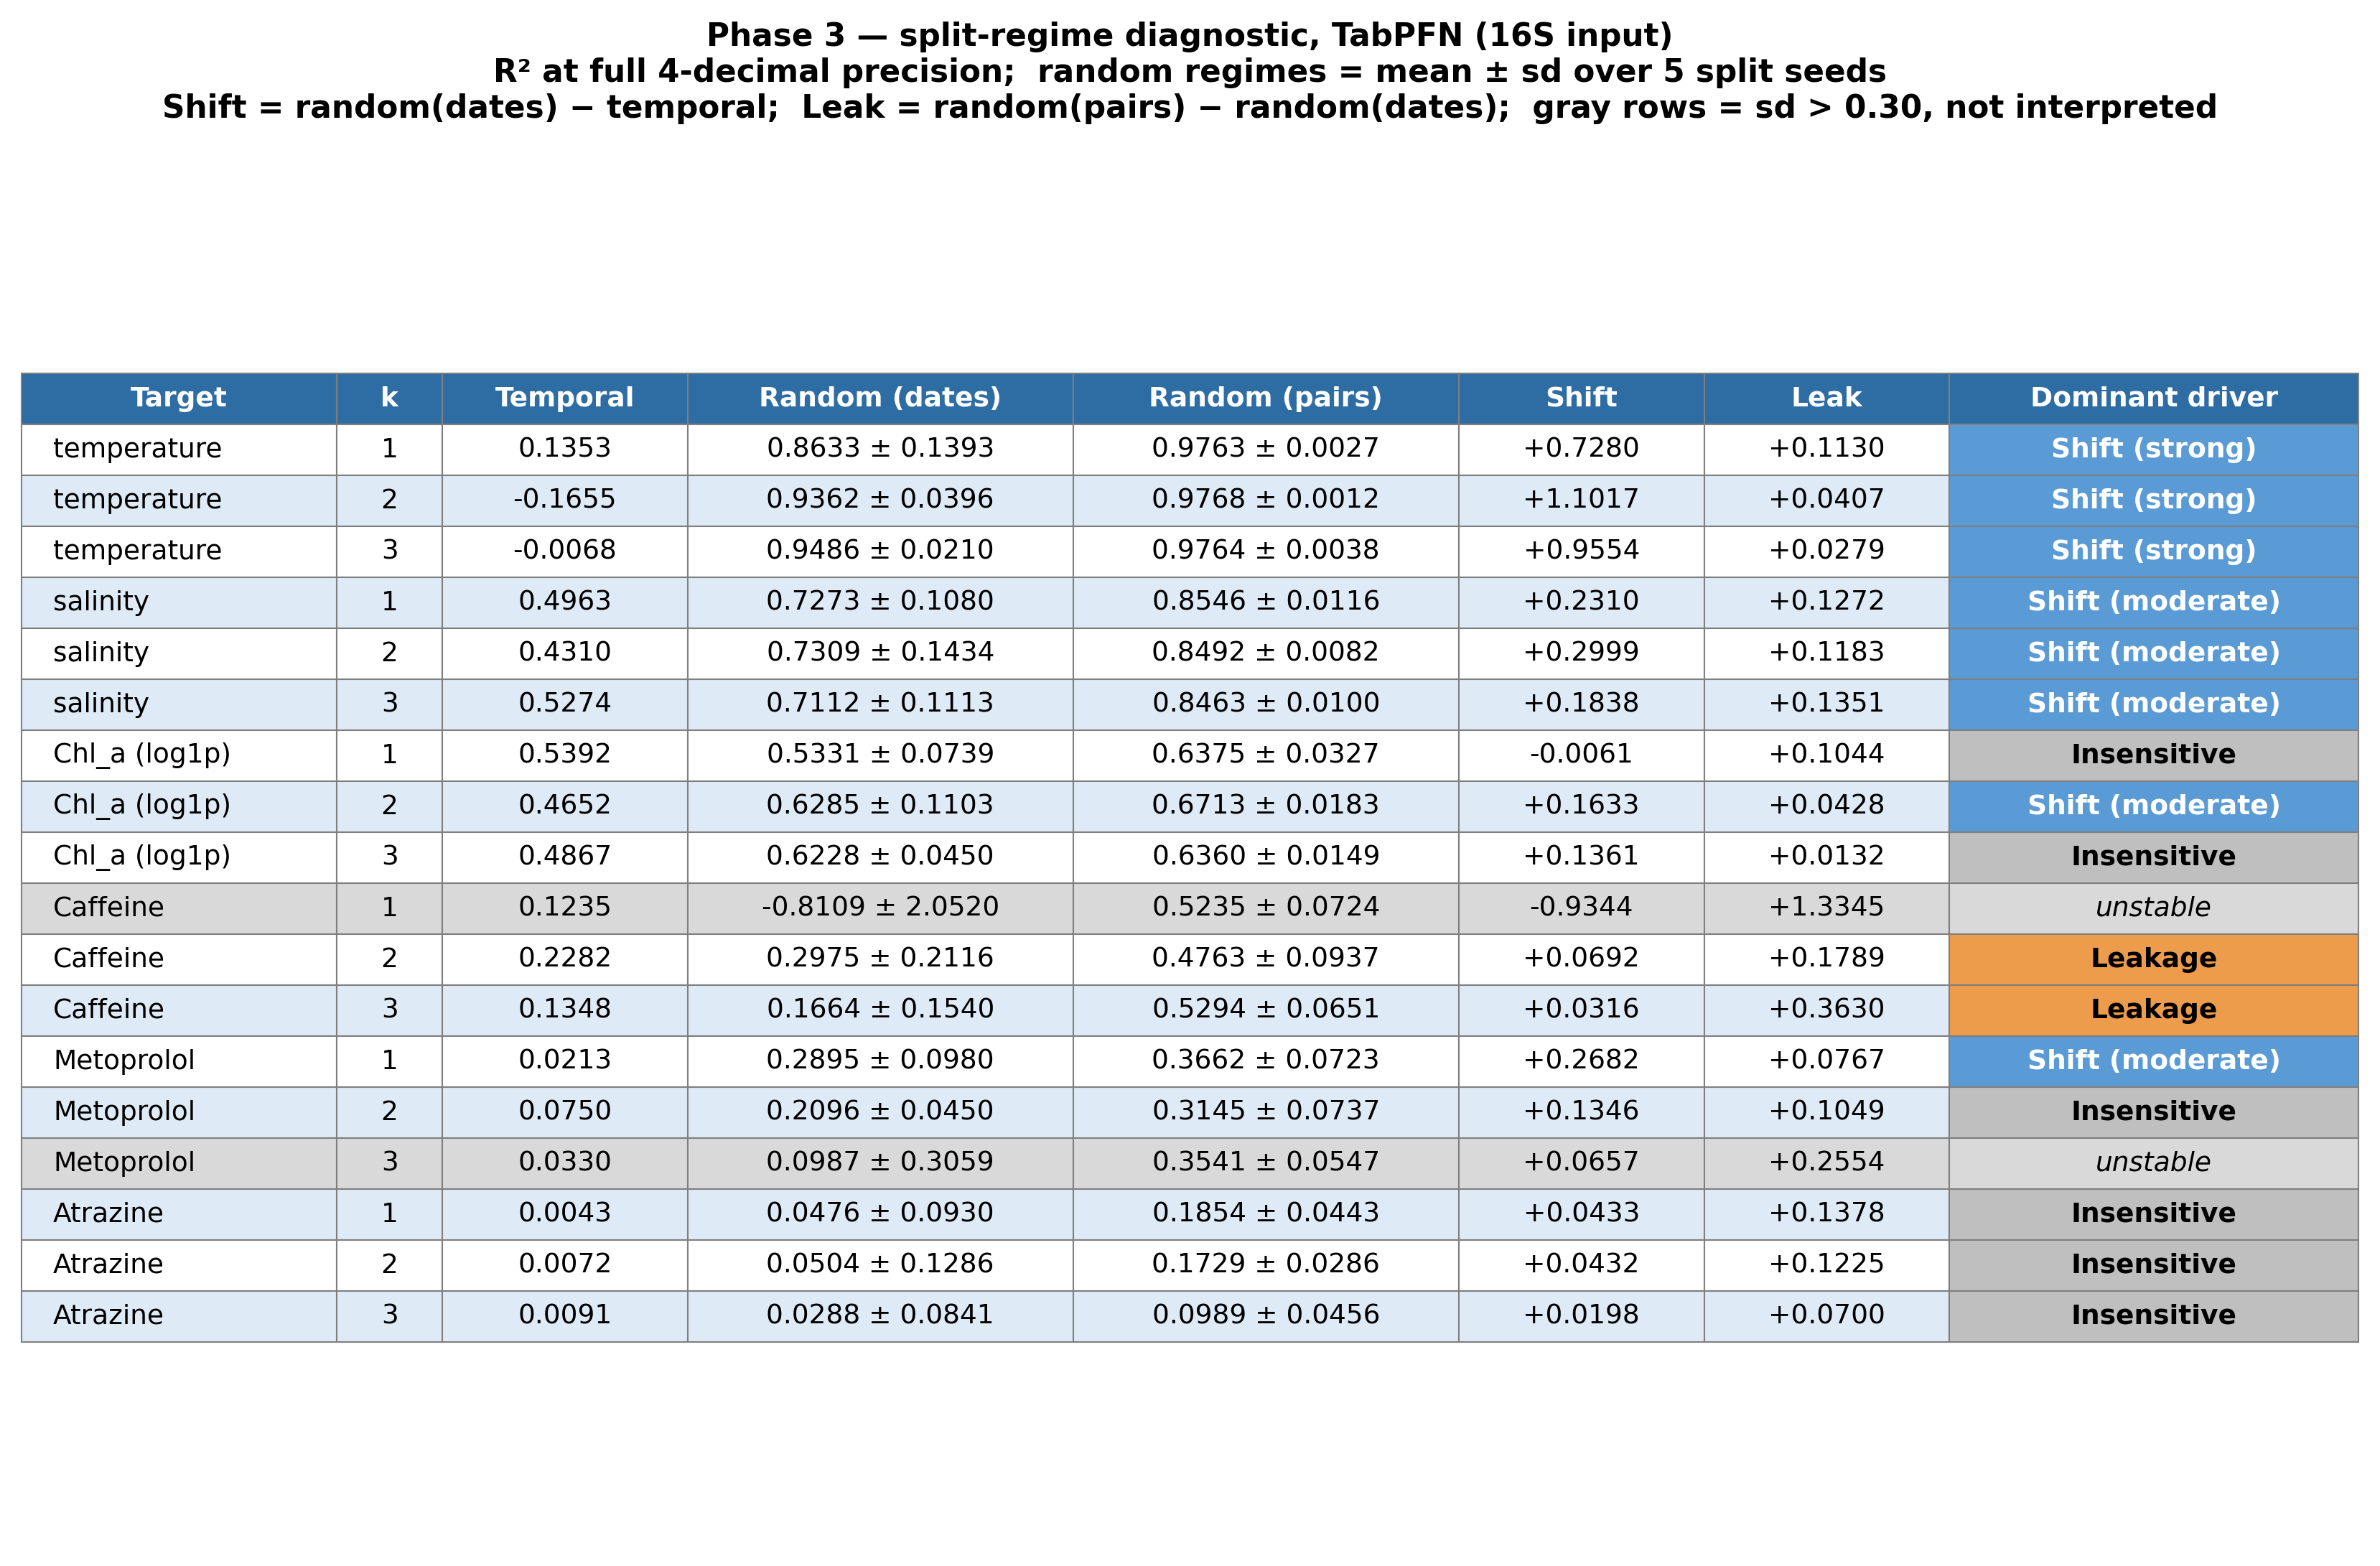

In [28]:
# === Split-regime table, Phase-1 house style (refined driver logic) ===
import matplotlib; matplotlib.use('Agg')
import matplotlib.pyplot as plt
import numpy as np, pandas as pd
from pathlib import Path
from IPython.display import Image, display

R = Path('/mnt/data/home/tv2414/tabpfn_project/results')
df = pd.read_csv(R / 'phase3_random_split_multiseed.csv')

TGT = ['temperature', 'salinity', 'Chl_a_log1p', 'Caffeine', 'Metoprolol', 'Atrazine']
LBL = {'Chl_a_log1p': 'Chl_a (log1p)'}
g    = df.groupby(['target', 'horizon_k', 'regime'])['r2']
mean, sd = g.mean().unstack('regime'), g.std().unstack('regime')

HDR_BG, WIN_BG, ALT_BG, EXC_BG, GRAY = '#2E6DA4', '#5B9BD5', '#DEEBF7', '#ED9C4B', '#D9D9D9'
NEU_BG = '#BFBFBF'                      # 'Insensitive' — neither effect matters

rows, flags = [], []
for t in TGT:
    for k in [1, 2, 3]:
        m, s = mean.loc[(t, k)], sd.loc[(t, k)]
        shift, leak = m.random_dates - m.temporal, m.random_pairs - m.random_dates
        unstable = s.random_dates > 0.30
        if unstable:                             driver = 'unstable'
        elif shift > 0.50:                       driver = 'Shift (strong)'
        elif max(abs(shift), leak) < 0.15:       driver = 'Insensitive'
        elif leak > 2 * max(shift, 0.01):        driver = 'Leakage'
        elif shift < 0.10:                       driver = 'Insensitive'
        else:                                    driver = 'Shift (moderate)'
        rows.append([LBL.get(t, t), k, f'{m.temporal:.4f}',
                     f'{m.random_dates:.4f} ± {s.random_dates:.4f}',
                     f'{m.random_pairs:.4f} ± {s.random_pairs:.4f}',
                     f'{shift:+.4f}', f'{leak:+.4f}', driver])
        flags.append(unstable)

cols = ['Target', 'k', 'Temporal', 'Random (dates)', 'Random (pairs)',
        'Shift', 'Leak', 'Dominant driver']
tbl = pd.DataFrame(rows, columns=cols)
DRV = cols.index('Dominant driver')
WIDTHS = [0.135, 0.045, 0.105, 0.165, 0.165, 0.105, 0.105, 0.175]
DRV_BG = {'Shift (strong)': WIN_BG, 'Shift (moderate)': WIN_BG,
          'Leakage': EXC_BG, 'Insensitive': NEU_BG}

fig, ax = plt.subplots(figsize=(14, 0.36 * len(tbl) + 1.8))
ax.axis('off')
t = ax.table(cellText=tbl.values, colLabels=cols, loc='center',
             cellLoc='center', colWidths=WIDTHS)
t.auto_set_font_size(False); t.set_fontsize(9); t.scale(1, 1.42)

for (r, c), cell in t.get_celld().items():
    cell.set_edgecolor('#7F7F7F'); cell.set_linewidth(0.5)
    if r == 0:
        cell.set_facecolor(HDR_BG); cell.set_text_props(color='white', weight='bold')
        continue
    if flags[r - 1]:
        cell.set_facecolor(GRAY)
        if c == DRV: cell.set_text_props(style='italic')
    elif c == DRV:
        drv = tbl.iloc[r - 1, c]
        cell.set_facecolor(DRV_BG[drv])
        cell.set_text_props(color='white' if drv.startswith('Shift') else 'black',
                            weight='bold')
    elif r % 2 == 0:
        cell.set_facecolor(ALT_BG)
    if c == 0:
        cell.set_text_props(ha='left')

ax.set_title(
    'Phase 3 — split-regime diagnostic, TabPFN (16S input)\n'
    'R² at full 4-decimal precision;  random regimes = mean ± sd over 5 split seeds\n'
    'Shift = random(dates) − temporal;  Leak = random(pairs) − random(dates);  '
    'gray rows = sd > 0.30, not interpreted',
    fontsize=10.5, fontweight='bold', pad=18)

fig.savefig(R / 'phase3_split_regime_table.png', dpi=300, bbox_inches='tight')
plt.close(fig)
print('saved -> phase3_split_regime_table.png')
display(Image(str(R / 'phase3_split_regime_table.png')))

saved -> phase3_split_regime_heatmap.png / .pdf
saved -> phase3_split_regime_table.tex


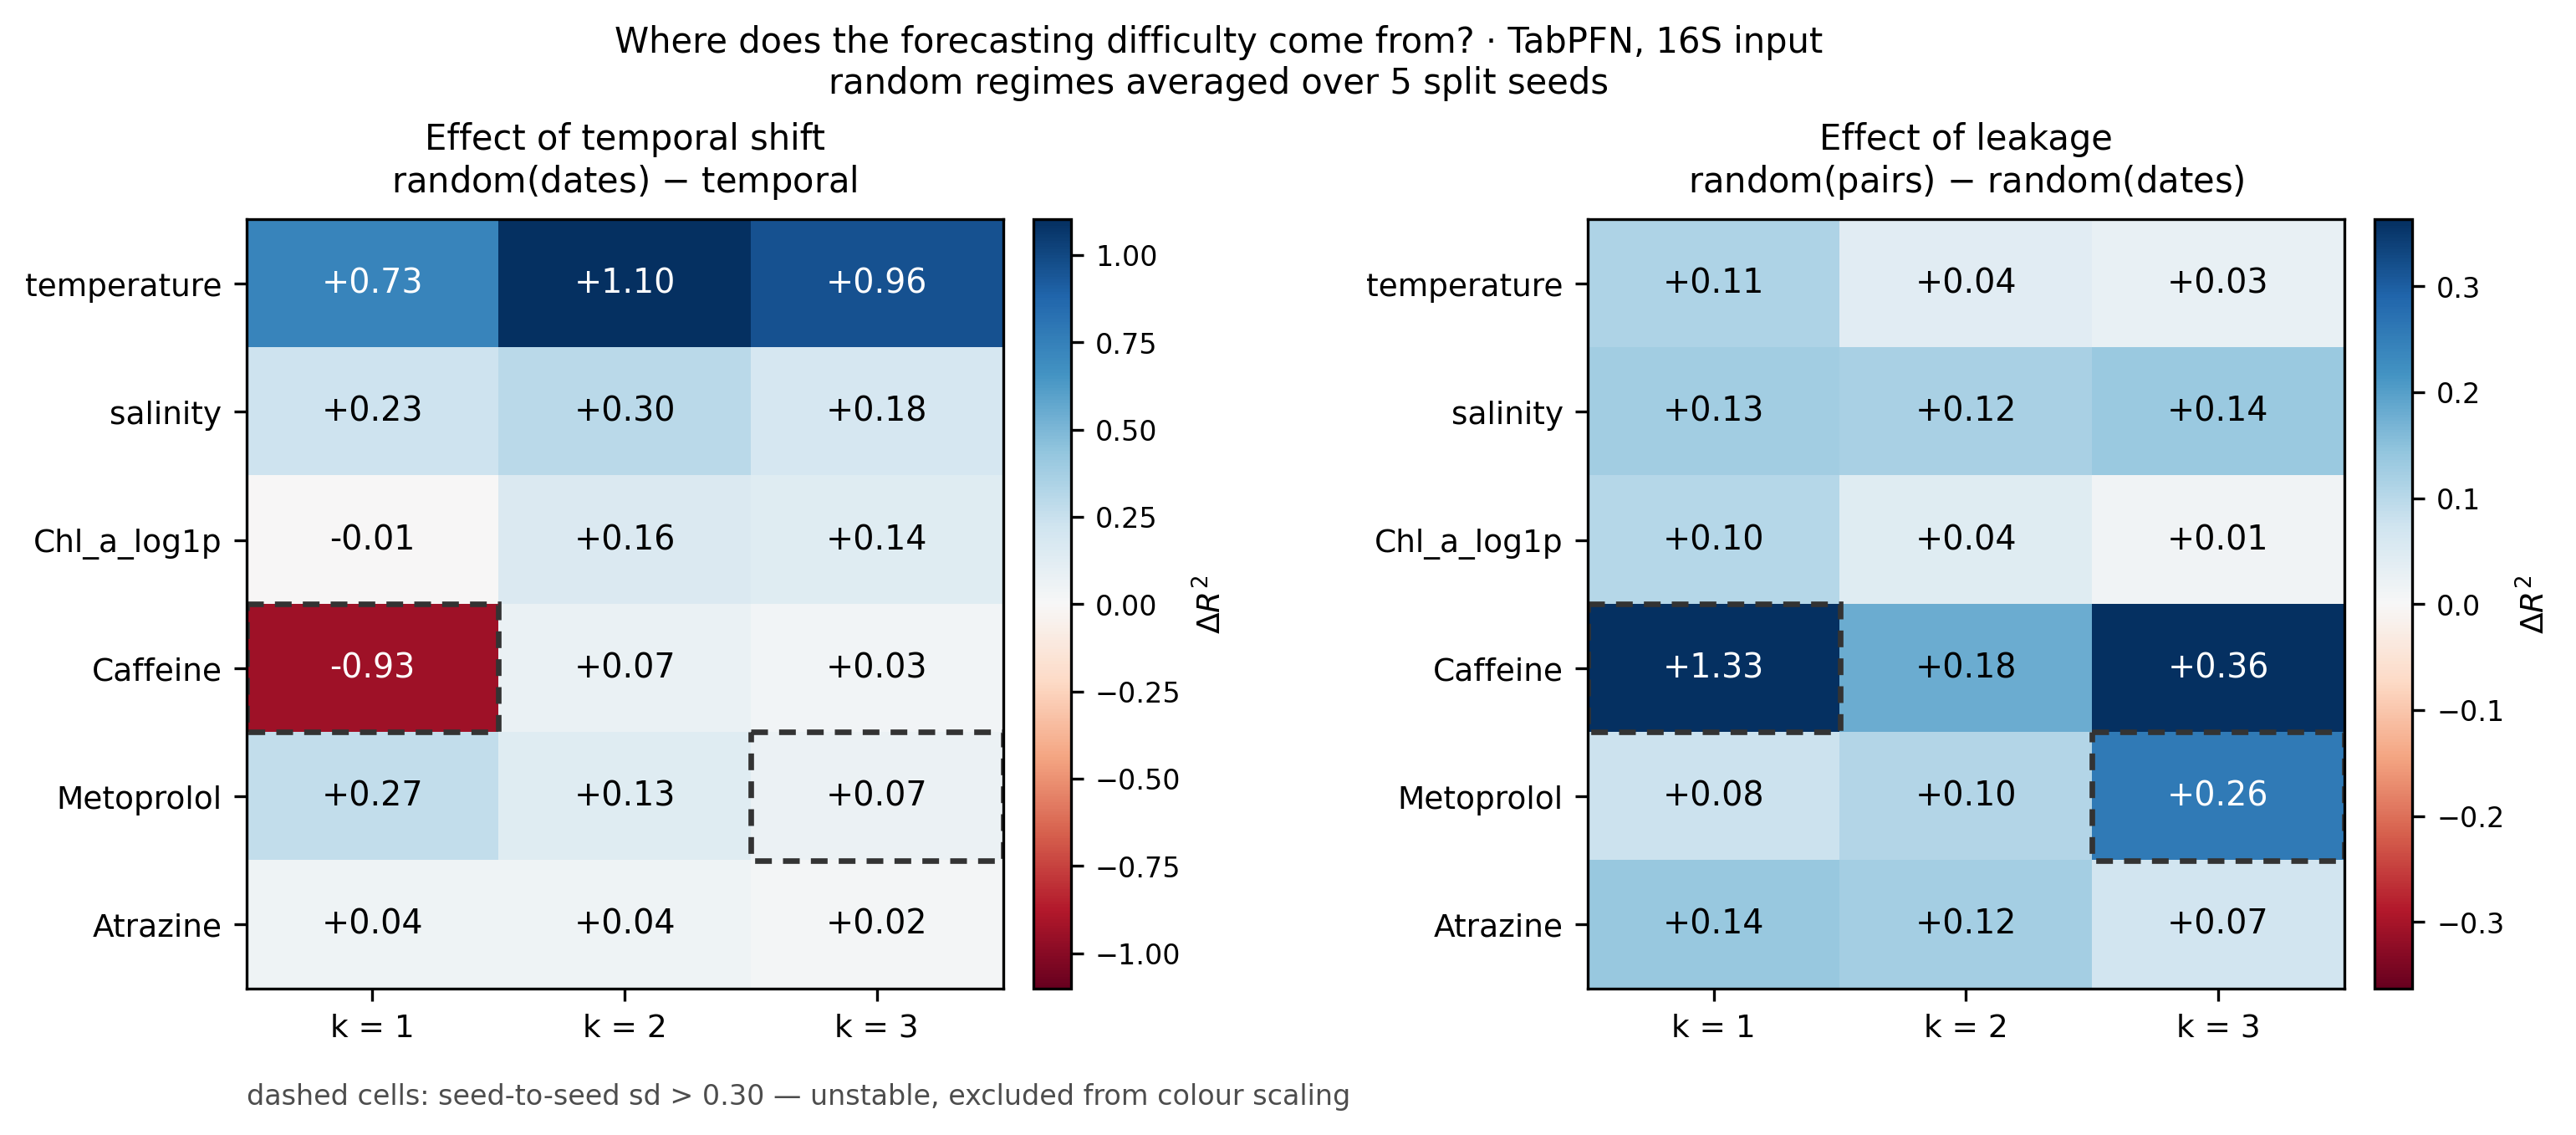

In [21]:
# === FIGURE + TABLE — split-regime effects (RdBu, consistent with Phase 3) ===
import warnings; warnings.filterwarnings('ignore')
import matplotlib; matplotlib.use('Agg')
import matplotlib.pyplot as plt
import numpy as np, pandas as pd
from matplotlib.colors import TwoSlopeNorm
from pathlib import Path
from mpl_toolkits.axes_grid1 import make_axes_locatable

R = Path('/mnt/data/home/tv2414/tabpfn_project/results')
df = pd.read_csv(R / 'phase3_random_split_multiseed.csv')

TGT = ['temperature', 'salinity', 'Chl_a_log1p', 'Caffeine', 'Metoprolol', 'Atrazine']
HOR = [1, 2, 3]
UNSTABLE_SD = 0.30          # cells whose seed-to-seed sd exceeds this are flagged

g    = df.groupby(['target', 'horizon_k', 'regime'])['r2']
mean = g.mean().unstack('regime')
sd   = g.std().unstack('regime')

shift = (mean['random_dates'] - mean['temporal']).unstack('horizon_k').reindex(TGT)[HOR]
leak  = (mean['random_pairs'] - mean['random_dates']).unstack('horizon_k').reindex(TGT)[HOR]
flag  = (sd['random_dates'] > UNSTABLE_SD).unstack('horizon_k').reindex(TGT)[HOR]

from mpl_toolkits.axes_grid1 import make_axes_locatable

# ... بقیه کد بدون تغییر تا حلقه ...

fig, axes = plt.subplots(1, 2, figsize=(9.6, 4.4), constrained_layout=True)
panels = [(shift, 'Effect of temporal shift\nrandom(dates) $-$ temporal'),
          (leak,  'Effect of leakage\nrandom(pairs) $-$ random(dates)')]

for ax, (M, title) in zip(axes, panels):
    A = M.values.astype(float)
    stable = A[~flag.values]
    vmax = float(np.nanmax(np.abs(stable)))
    norm = TwoSlopeNorm(vmin=-vmax, vcenter=0.0, vmax=vmax)
    im = ax.imshow(np.clip(A, -vmax, vmax), cmap='RdBu', norm=norm, aspect='auto')

    for i in range(A.shape[0]):
        for j in range(A.shape[1]):
            v = A[i, j]
            ax.text(j, i, f'{v:+.2f}', ha='center', va='center', fontsize=9.5,
                    color='white' if abs(np.clip(v, -vmax, vmax)) > 0.6 * vmax else 'black')
            if bool(flag.values[i, j]):
                ax.add_patch(plt.Rectangle((j - .5, i - .5), 1, 1, fill=False,
                                           ec='0.2', lw=1.6, ls=(0, (3, 2))))

    ax.set_xticks(range(3), [f'k = {k}' for k in HOR], fontsize=9)
    ax.set_yticks(range(len(TGT)), TGT, fontsize=9)
    ax.set_title(title, fontsize=10, pad=8)

    # colorbar attached directly to this axes — no gap
    cax = make_axes_locatable(ax).append_axes('right', size='5%', pad=0.12)
    cb = fig.colorbar(im, cax=cax)
    cb.set_label('$\\Delta R^2$', fontsize=9)
    cb.ax.tick_params(labelsize=8)

fig.suptitle('Where does the forecasting difficulty come from? · TabPFN, 16S input\n'
             'random regimes averaged over 5 split seeds',
             fontsize=10)
axes[0].text(0.0, -0.15,
             'dashed cells: seed-to-seed sd > 0.30 — unstable, excluded from colour scaling',
             transform=axes[0].transAxes, fontsize=8, color='0.3')

for ext in ('png', 'pdf'):
    fig.savefig(R / f'phase3_split_regime_heatmap.{ext}', dpi=300, bbox_inches='tight')
plt.close(fig)
print('saved -> phase3_split_regime_heatmap.png / .pdf')

# ---------- LaTeX table in the same style as the other chapter tables ----------
rows = []
for t in TGT:
    for k in HOR:
        m, s = mean.loc[(t, k)], sd.loc[(t, k)]
        f = lambda r: (f"{m[r]:+.3f}" if not np.isfinite(s[r]) or s[r] == 0
                       else f"{m[r]:+.3f} $\\pm$ {s[r]:.3f}")
        rows.append({'Target': t.replace('_', '\\_'), '$k$': k,
                     'Temporal': f('temporal'),
                     'Random (dates)': f('random_dates'),
                     'Random (pairs)': f('random_pairs'),
                     'Shift': f"{m.random_dates - m.temporal:+.3f}",
                     'Leak':  f"{m.random_pairs - m.random_dates:+.3f}"})
tbl = pd.DataFrame(rows)

latex = tbl.to_latex(index=False, escape=False, column_format='lrccccc',
    caption=('TabPFN forecasting $R^2$ under three split regimes (16S input). '
             'Random regimes are averaged over five split seeds; the temporal split '
             'is deterministic. Shift $=$ random(dates) $-$ temporal isolates the effect '
             'of distributional shift; Leak $=$ random(pairs) $-$ random(dates) quantifies '
             'the inflation caused by pair-level randomisation. Temperature is the only '
             'target whose shift effect exceeds 0.7.'),
    label='tab:split-regimes')
(R / 'phase3_split_regime_table.tex').write_text(latex)
print('saved -> phase3_split_regime_table.tex')

from IPython.display import Image, display
display(Image(str(R / 'phase3_split_regime_heatmap.png')))

In [22]:
# === PHASE-3 RANDOM K-FOLD ON DATES — structurally parallel to Phase 1 ===
import warnings; warnings.filterwarnings('ignore')
import sys, time
import numpy as np, pandas as pd
from pathlib import Path
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score, mean_absolute_error

ROOT = Path('/mnt/data/home/tv2414/tabpfn_project'); sys.path.insert(0, str(ROOT))
PROC, RESULTS = ROOT / 'data' / 'processed', ROOT / 'results'
MODEL_PATH, RANDOM_SEED = "auto", 42          # same seed as Phase 1 random_kfold
N_FOLDS, MAX_STEP_DAYS = 5, 6
HORIZONS = [1, 2, 3]
OUT = RESULTS / 'phase3_random_kfold_dates.csv'

def parse_censored(series):
    s = series.astype(str).str.strip()
    out = pd.to_numeric(s, errors='coerce')
    out.loc[s.str.startswith('<').fillna(False) | s.str.startswith('#').fillna(False)] = 0.0
    return out

meta_f = (pd.read_csv(PROC / 'meta_clean.csv')
            .rename(columns={'Unnamed: 0': 'sample_id'}).set_index('sample_id'))
meta_f['date'] = pd.to_datetime(meta_f['date'], errors='coerce')
hplc = (pd.read_csv(ROOT / 'data' / 'hplc_submission.csv')
          .rename(columns={'Unnamed: 0': 'sample_id'}).set_index('sample_id'))
for c in ['Caffeine', 'Metoprolol', 'Atrazine']:
    meta_f[c] = parse_censored(hplc[c]).reindex(meta_f.index)

otu16 = pd.read_csv(PROC / 'otu_16s_clean.csv', index_col=0)
otu16.index = meta_f.index
from src.tabpfn_evaluator import run_tabpfn_with_splits, TABPFN_VERSION

def build_lagged_index(k):
    pairs = []
    for _, g in meta_f.groupby('location_name'):
        g = g.sort_values('date')
        pos, dates = g.index.to_numpy(), g['date'].to_numpy()
        for i in range(len(pos) - k):
            sd = np.diff(dates[i:i+k+1]).astype('timedelta64[D]').astype(int)
            if (sd <= MAX_STEP_DAYS).all():
                pairs.append((pos[i], pos[i+k]))
    return pairs
LAG = {k: build_lagged_index(k) for k in HORIZONS}

# ---- K-fold over UNIQUE DATES, single seed 42 (mirrors Phase 1 random_kfold) ----
ud = pd.DatetimeIndex(meta_f['date'].dropna().unique()).sort_values()
kf = KFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_SEED)
DATE_FOLDS = [set(pd.Timestamp(x) for x in ud.to_numpy()[te])
              for _, te in kf.split(np.arange(len(ud)))]
print(f"{len(ud)} unique dates → {N_FOLDS} folds of "
      f"{[len(f) for f in DATE_FOLDS]} dates (seed {RANDOM_SEED})")

def split_fold(pairs, test_dates):
    """A pair joins test only if BOTH endpoints are test dates, train only if
    neither is; pairs straddling the boundary are discarded (as in split_global)."""
    tr, te = [], []
    for f, t in pairs:
        in_f = meta_f.loc[f, 'date'] in test_dates
        in_t = meta_f.loc[t, 'date'] in test_dates
        if in_f and in_t:           te.append((f, t))
        elif not in_f and not in_t: tr.append((f, t))
    return tr, te

TARGETS = ['temperature', 'salinity', 'Chl_a_log1p', 'Caffeine', 'Metoprolol', 'Atrazine']
rows, t0 = [], time.time()
print(f"TabPFN v{TABPFN_VERSION} · {len(TARGETS)*len(HORIZONS)*N_FOLDS} runs\n")

for tgt in TARGETS:
    y = pd.to_numeric(meta_f[tgt], errors='coerce')
    for k in HORIZONS:
        fold_r2 = []
        for fold_i, test_dates in enumerate(DATE_FOLDS):
            tr, te = split_fold(LAG[k], test_dates)
            f_tr = pd.Index([f for f, _ in tr]); t_tr = pd.Index([t for _, t in tr])
            f_te = pd.Index([f for f, _ in te]); t_te = pd.Index([t for _, t in te])
            Xtr, Xte = otu16.loc[f_tr].to_numpy(float), otu16.loc[f_te].to_numpy(float)
            ytr, yte = y.loc[t_tr].to_numpy(float), y.loc[t_te].to_numpy(float)
            ynow = y.loc[f_te].to_numpy(float)
            ok_tr = np.isfinite(Xtr).all(1) & np.isfinite(ytr)
            ok_te = np.isfinite(Xte).all(1) & np.isfinite(yte) & np.isfinite(ynow)
            Xtr, ytr = Xtr[ok_tr], ytr[ok_tr]
            Xte, yte, ynow = Xte[ok_te], yte[ok_te], ynow[ok_te]
            if len(yte) < 30 or np.unique(yte).size < 2:
                print(f"  {tgt:12s} k={k} fold {fold_i}: n_test={len(yte)} — skipped")
                continue
            n = len(ytr)
            res = run_tabpfn_with_splits(
                model_path=MODEL_PATH, target_name=tgt,
                meta=pd.DataFrame({tgt: np.concatenate([ytr, yte])}),
                otu=pd.DataFrame(np.vstack([Xtr, Xte])),
                splits=[(np.arange(n), np.arange(n, n + len(yte)))],
                strategy_name=f'random_kfold_dates_k{k}_f{fold_i}', input_name='16S',
                log_target=False, random_seed=RANDOM_SEED, verbose=False)
            fold_r2.append(res['r2_mean'])
            rows.append({'target': tgt, 'horizon_k': k, 'fold': fold_i,
                'n_train': int(n), 'n_test': int(len(yte)),
                'r2': res['r2_mean'], 'mae': res['mae_mean'], 'rmse': res['rmse_mean'],
                'per_r2': r2_score(yte, ynow),
                'per_mae': mean_absolute_error(yte, ynow),
                'var_test': float(np.var(yte))})
        if fold_r2:
            print(f"  {tgt:12s} k={k}  R² = {np.mean(fold_r2):+.3f} ± "
                  f"{np.std(fold_r2, ddof=1):.3f}  ({len(fold_r2)} folds)")
    pd.DataFrame(rows).to_csv(OUT, index=False)

print(f"\nDONE · {(time.time()-t0)/60:.1f} min → {OUT.name}")

# ---------- summary, same shape as Phase 1 reporting ----------
df = pd.DataFrame(rows)
summ = (df.groupby(['target', 'horizon_k'])
          .agg(r2_mean=('r2', 'mean'), r2_sd=('r2', lambda s: s.std(ddof=1)),
               n_test_mean=('n_test', 'mean'), n_folds=('r2', 'size'))
          .round(3))
print('\n=== TabPFN, random K-fold over dates (seed 42, mean ± sd across folds) ===')
print(summ.to_string())

112 unique dates → 5 folds of [23, 23, 22, 22, 22] dates (seed 42)
TabPFN v8.0.6 · 90 runs

  temperature  k=1 fold 0: n_test=14 — skipped
  temperature  k=1 fold 1: n_test=14 — skipped
  temperature  k=1 fold 2: n_test=0 — skipped
  temperature  k=1  R² = +0.722 ± 0.333  (2 folds)
  temperature  k=2 fold 0: n_test=10 — skipped
  temperature  k=2 fold 2: n_test=19 — skipped
  temperature  k=2  R² = +0.784 ± 0.290  (3 folds)
  temperature  k=3 fold 0: n_test=28 — skipped
  temperature  k=3 fold 1: n_test=13 — skipped
  temperature  k=3 fold 2: n_test=10 — skipped
  temperature  k=3 fold 4: n_test=24 — skipped
  temperature  k=3  R² = -0.810 ± nan  (1 folds)
  salinity     k=1 fold 0: n_test=14 — skipped
  salinity     k=1 fold 1: n_test=14 — skipped
  salinity     k=1 fold 2: n_test=0 — skipped
  salinity     k=1  R² = +0.729 ± 0.097  (2 folds)
  salinity     k=2 fold 0: n_test=10 — skipped
  salinity     k=2 fold 2: n_test=19 — skipped
  salinity     k=2  R² = +0.681 ± 0.032  (3 folds)

In [1]:
# ============================================================
# Cell 1 (reconnaissance) — READ ONLY, no computation.
# Recovers the exact Phase 2 embedding API and result schema so the
# Phase 3 probing cell can be written against real signatures.
# ============================================================
import sys, inspect, subprocess
from pathlib import Path
import pandas as pd

ROOT = Path('/mnt/data/home/tv2414/tabpfn_project')
sys.path.insert(0, str(ROOT))
RESULTS = ROOT / 'results'

# --- 1. where do the embedding functions live? ---
for fn in ['extract_embeddings_for_split',
           'extract_embeddings_for_visualization']:
    out = subprocess.run(
        ['grep', '-rn', '--include=*.py', '--include=*.ipynb',
         f'def {fn}', str(ROOT)],
        capture_output=True, text=True).stdout.strip()
    print(f'[{fn}]\n{out or "  NOT FOUND"}\n')

# --- 2. schema of the Phase 2 quantitative results ---
p2 = pd.read_csv(RESULTS / 'phase2_downstream_emb_vs_raw.csv')
print('phase2_downstream_emb_vs_raw.csv:', p2.shape)
print('columns :', list(p2.columns))
for c in ['model', 'features', 'target', 'input', 'strategy']:
    if c in p2.columns:
        print(f'  {c:10s}: {sorted(p2[c].unique())}')
print()

# --- 3. exact chemical target column names in the modelling master ---
meta = pd.read_csv(ROOT / 'data/processed/meta_clean.csv')
cand = [c for c in meta.columns
        if any(k in c.lower() for k in
               ['caff', 'metopr', 'atraz', 'temp', 'sal', 'chl'])]
print('candidate target columns:', cand)
print(meta[cand].notna().sum().to_string())

# --- 4. does a Phase 3 embedding result file already exist? ---
print('\nexisting phase3 embedding files:',
      sorted(f.name for f in RESULTS.glob('*emb*')) or 'none')

[extract_embeddings_for_split]
/mnt/data/home/tv2414/tabpfn_project/notebooks/02_preprocessing.ipynb:9008:      "def extract_embeddings_for_split(X, y, train_idx, test_idx,\n",
/mnt/data/home/tv2414/tabpfn_project/notebooks/02_preprocessing.ipynb:9533:      "def extract_embeddings_for_split(X, y, train_idx, test_idx,\n",
/mnt/data/home/tv2414/tabpfn_project/notebooks/11_phase2_embeddings.ipynb:912:    "def extract_embeddings_for_split(X, y, train_idx, test_idx,\n",
/mnt/data/home/tv2414/tabpfn_project/notebooks/11_phase2_embeddings.ipynb:5024:      "def extract_embeddings_for_split(X, y, train_idx, test_idx,\n",
/mnt/data/home/tv2414/tabpfn_project/notebooks/13_phase2_clean.ipynb:209:    "def extract_embeddings_for_split(X, y, train_idx, test_idx,\n",
/mnt/data/home/tv2414/tabpfn_project/_all_nb.py:8913:def extract_embeddings_for_split(X, y, train_idx, test_idx,

[extract_embeddings_for_visualization]
/mnt/data/home/tv2414/tabpfn_project/notebooks/13_phase2_clean.ipynb:510:    "def ext

In [2]:
# ============================================================
# Cell 2 (reconnaissance) — READ ONLY.
# Recovers: (a) the exact embedding function source,
#           (b) how Phase 3 builds the chemical targets,
#           (c) the Phase 2 Ridge probing loop to be mirrored.
# ============================================================
import json, subprocess
from pathlib import Path
import pandas as pd

ROOT = Path('/mnt/data/home/tv2414/tabpfn_project')
RESULTS = ROOT / 'results'

# --- (a) full source of the split-based extractor ---
src = (ROOT / '_all_nb.py').read_text().splitlines()
print('=' * 70)
print('extract_embeddings_for_split  (from _all_nb.py)')
print('=' * 70)
print('\n'.join(src[8912:8990]))

# --- (b) how does Phase 3 load and name the chemical targets? ---
nb = json.loads((ROOT / 'notebooks/14_phase3_hplc.ipynb').read_text())
cells = [''.join(c['source']) for c in nb['cells'] if c['cell_type'] == 'code']
print('\n' + '=' * 70)
print(f'14_phase3_hplc.ipynb — {len(cells)} code cells')
print('=' * 70)
KEYS = ('hplc', 'caffeine', 'Caffeine', 'TARGETS', 'censor',
        'def build', 'merge', 'join')
for i, c in enumerate(cells):
    if any(k in c for k in KEYS):
        print(f'\n----- cell {i} -----')
        print(c[:1400])

# --- (c) the Phase 2 probing loop, to mirror exactly ---
nb2 = json.loads((ROOT / 'notebooks/13_phase2_clean.ipynb').read_text())
cells2 = [''.join(c['source']) for c in nb2['cells'] if c['cell_type'] == 'code']
print('\n' + '=' * 70)
print('13_phase2_clean.ipynb — cells containing the Ridge probe loop')
print('=' * 70)
for i, c in enumerate(cells2):
    if 'Ridge' in c and ('for ' in c) and ('raw' in c or 'embedding' in c):
        print(f'\n----- cell {i} -----')
        print(c[:1800])

# --- (d) what is cached in results/embeddings? ---
emb = sorted((RESULTS / 'embeddings').glob('*'))
print(f'\nresults/embeddings — {len(emb)} entries; first 15:')
for f in emb[:15]:
    print(f'  {f.name}  ({f.stat().st_size/1e6:.1f} MB)')

extract_embeddings_for_split  (from _all_nb.py)
def extract_embeddings_for_split(X, y, train_idx, test_idx,
                                 inner_folds=5, seed=RANDOM_SEED, agg=ENSEMBLE_AGG):
    """
    Leakage-free embeddings for ONE (train, test) split.

    TEST  : fit on train, embed test as query  -> test never in context.
    TRAIN : inner out-of-fold *within* train, so each train sample is also a
            held-out query point -> SAME regime as test, hence comparable.

    Returns emb_train (n_tr, D), emb_test (n_te, D).
    """
    def _agg(e):
        e = np.asarray(e)
        return e.mean(axis=0) if agg == 'mean' else e[0]

    Xtr, ytr, Xte = X[train_idx], y[train_idx], X[test_idx]

    # --- TEST embeddings: context = full train ---
    reg = make_regressor()
    reg.fit(Xtr, ytr)
    emb_test = _agg(reg.get_embeddings(Xte, data_source='test'))

    # --- TRAIN embeddings: inner OOF within train ---
    n_tr  = len(train_idx)
    inner = random_kfold(n_samples=n_tr, n_

In [4]:
# ---- what does this kernel actually have? ----
NEEDED = ['meta', 'otu_16s', 'otu_18s', 'INPUT_TABLES', 'INPUTS',
          'build_splits', 'extract_embeddings_for_split', 'make_regressor',
          'RIDGE_ALPHAS', 'RANDOM_SEED', 'INNER_FOLDS', 'ENSEMBLE_AGG',
          'ROOT', 'RESULTS', 'PROCESSED_DIR']
for n in NEEDED:
    v = globals().get(n, None)
    if v is None:
        print(f'  ✗  {n}')
    else:
        extra = ''
        if hasattr(v, 'shape'):        extra = f'shape={v.shape}'
        elif isinstance(v, dict):      extra = f'keys={list(v)}'
        elif isinstance(v, (int, str, float)): extra = repr(v)
        print(f'  ✓  {n:<32s} {extra}')

# any other dataframe-looking names that might be the ASV tables?
print('\nDataFrame-like globals:')
for k, v in list(globals().items()):
    if hasattr(v, 'shape') and not k.startswith('_') and k not in NEEDED:
        print(f'    {k:<24s} {v.shape}')

  ✓  meta                             shape=(1538, 25)
  ✗  otu_16s
  ✗  otu_18s
  ✗  INPUT_TABLES
  ✗  INPUTS
  ✗  build_splits
  ✗  extract_embeddings_for_split
  ✗  make_regressor
  ✗  RIDGE_ALPHAS
  ✗  RANDOM_SEED
  ✗  INNER_FOLDS
  ✗  ENSEMBLE_AGG
  ✓  ROOT                             
  ✓  RESULTS                          
  ✗  PROCESSED_DIR

DataFrame-like globals:
    p2                       (900, 13)
    np                       <function shape at 0x7f1cad026160>
    hplc_p3                  (1433, 36)
    meta_p3                  (1538, 28)


In [8]:
# ============================================================
# Chapter 8 — read the verified forecasting numbers from disk.
# READ ONLY. Nothing is computed, nothing is overwritten.
# ============================================================
import numpy as np, pandas as pd
from pathlib import Path

R = Path('/mnt/data/home/tv2414/tabpfn_project/results')
pd.set_option('display.width', 200, 'display.max_rows', 120)

# ---- 1. which forecasting result files exist, and how fresh are they? ----
print('=== forecasting result files ===')
for f in sorted(R.glob('*forecast*')) + sorted(R.glob('*phase3*')):
    print(f'  {f.name:<58s} {f.stat().st_size/1e3:8.1f} KB  '
          f'{pd.Timestamp(f.stat().st_mtime, unit="s").date()}')

# ---- 2. the unified-cutoff benchmark ----
CAND = ['phase3_forecasting_shared_mask_splitB_unifiedcut.csv',
        'phase3_forecasting_shared_mask_splitB.csv']
src = next((R / c for c in CAND if (R / c).exists()), None)
print(f'\n=== using: {src.name} ===')
fc = pd.read_csv(src)
print('shape:', fc.shape, '| columns:', list(fc.columns))
for c in ['model', 'input', 'target', 'horizon_k']:
    if c in fc: print(f'  {c:10s}: {sorted(fc[c].unique())}')

# ---- 3. the honest skill table (best model vs BEST model-free baseline) ----
for name in ['chapter8_master_forecasting_table.csv',
             'table_forecasting_best_per_cell.csv']:
    p = R / name
    if p.exists():
        print(f'\n=== {name} ===')
        print(pd.read_csv(p).to_string(index=False))

# ---- 4. autocorrelation vs skill (Figure 8.4) ----
for name in ['phase3_autocorr_skill.csv', 'phase3_split_regime_table.csv']:
    p = R / name
    if p.exists():
        print(f'\n=== {name} ===')
        print(pd.read_csv(p).to_string(index=False))

=== forecasting result files ===
  chapter8_master_forecasting_table.csv                           1.8 KB  2026-08-05
  chapter8_master_forecasting_table.md                            1.4 KB  2026-08-05
  chapter8_master_forecasting_table.tex                           1.8 KB  2026-08-05
  fig5_3_forecast_pairs.pdf                                      35.1 KB  2026-08-25
  fig5_3_forecast_pairs.png                                     263.9 KB  2026-08-25
  fig5_4_forecast_pairs.pdf                                      35.3 KB  2026-08-25
  fig5_4_forecast_pairs.png                                     167.8 KB  2026-08-25
  fig_phase3_forecasting_heatmap.pdf                             81.0 KB  2026-07-28
  fig_phase3_forecasting_heatmap.png                            571.9 KB  2026-07-28
  forecast_window_regime_check.csv                                1.0 KB  2026-08-05
  forecast_window_regime_persite.csv                              0.7 KB  2026-08-05
  forecasting_full_grid_unifiedc

In [9]:
# ============================================================
# Chapter 8 — final number extraction. READ ONLY.
# ============================================================
import numpy as np, pandas as pd
from pathlib import Path

ROOT = Path('/mnt/data/home/tv2414/tabpfn_project')
R, PROC = ROOT / 'results', ROOT / 'data' / 'processed'
pd.set_option('display.width', 200, 'display.max_rows', 200)

fc = pd.read_csv(R / 'phase3_forecasting_shared_mask_splitB_unifiedcut.csv')
T = ['Caffeine', 'Metoprolol', 'Atrazine']

# ---- 1. which input does the master table's TabPFN column use? ----
print('=== TabPFN R² per input (unifiedcut) vs master table ===')
piv = (fc[fc.model == 'tabpfn']
       .pivot_table(index=['target', 'horizon_k'], columns='input', values='r2'))
print(piv.round(4).to_string())
print('\nmaster table TabPFN: Caff k1=0.1235 k2=0.2282 k3=0.1353 | '
      'Metop k1=0.0213 | Atraz k1=0.0043')

# ---- 2. best model per (target, horizon), from the CURRENT file ----
print('\n=== best model per cell (unifiedcut) ===')
best = (fc.loc[fc.groupby(['target', 'horizon_k'])['r2'].idxmax(),
               ['target', 'horizon_k', 'model', 'input', 'r2',
                'per_r2', 'n_test']]
          .sort_values(['target', 'horizon_k']))
print(best.round(4).to_string(index=False))

# ---- 3. reliability floor: worst R² per model across all 108 runs ----
print('\n=== worst / median R² per model (108 runs) ===')
print(fc.groupby('model')['r2'].agg(['min', 'median', 'max']).round(3).to_string())

# ---- 4. n_test per target × horizon (shared mask) ----
print('\n=== shared-mask n_test ===')
print(fc.groupby(['target', 'horizon_k'])['n_test'].first().to_string())

# ---- 5. lag-1 autocorrelation per target (for the difficulty argument) ----
def parse_censored(s):
    s = s.astype(str).str.strip()
    out = pd.to_numeric(s, errors='coerce')
    out.loc[s.str.startswith('<').fillna(False) |
            s.str.startswith('#').fillna(False)] = 0.0
    return out

m = pd.read_csv(PROC / 'meta_clean.csv', index_col=0)
m['date'] = pd.to_datetime(m['date'], errors='coerce')
h = pd.read_csv(ROOT / 'data' / 'hplc_submission.csv', index_col=0, dtype=str)
h.index = h.index.astype(str).str.strip()
for c in T:
    m[c] = parse_censored(h[c]).reindex(m.index)

print('\n=== lag-1 autocorrelation (median over sites, <=6-day steps) ===')
for tgt in ['temperature', 'salinity', 'Chl_a_log1p'] + T:
    rs = []
    for _, g in m.groupby('location_name'):
        g = g.sort_values('date')
        v, d = g[tgt].to_numpy(), g['date'].to_numpy()
        ok = (np.diff(d).astype('timedelta64[D]').astype(int) <= 6)
        a, b = v[:-1][ok], v[1:][ok]
        f = np.isfinite(a) & np.isfinite(b)
        if f.sum() >= 20 and np.std(a[f]) > 0 and np.std(b[f]) > 0:
            rs.append(np.corrcoef(a[f], b[f])[0, 1])
    print(f'  {tgt:<14s} r1 = {np.median(rs):+.3f}   (n_sites = {len(rs)})')

# ---- 6. does the Phase 1 (environmental) forecasting file match? ----
p1 = R / 'phase1_forecasting_shared_mask_splitB.csv'
if p1.exists():
    d1 = pd.read_csv(p1)
    print(f'\n=== {p1.name}: {d1.shape} | targets={sorted(d1.target.unique())} ===')
    print(d1[d1.model == 'tabpfn'].pivot_table(
        index=['target', 'horizon_k'], columns='input', values='r2').round(3).to_string())

=== TabPFN R² per input (unifiedcut) vs master table ===
input                    16S  16S+18S     18S
target     horizon_k                         
Atrazine   1          0.0043   0.0176  0.0140
           2          0.0072  -0.0005 -0.0015
           3          0.0091   0.0046 -0.0033
Caffeine   1          0.1235   0.1339  0.2097
           2          0.2282   0.2332  0.2587
           3          0.1348   0.1765  0.2246
Metoprolol 1          0.0213   0.0639  0.0787
           2          0.0750   0.1008  0.1126
           3          0.0330   0.0207  0.0723

master table TabPFN: Caff k1=0.1235 k2=0.2282 k3=0.1353 | Metop k1=0.0213 | Atraz k1=0.0043

=== best model per cell (unifiedcut) ===
    target  horizon_k         model   input     r2  per_r2  n_test
  Atrazine          1        tabpfn 16S+18S 0.0176 -1.1241     272
  Atrazine          2 random_forest     18S 0.0313 -0.4430     250
  Atrazine          3        tabpfn     16S 0.0091 -0.6914     222
  Caffeine          1        tabpf